# **Business Analysis**

## Problem Statement:
ABC Tech handles 22–25k IT incidents per month using mature ITIL-based ITSM processes. Despite process maturity, further improvements through traditional ITIL optimization have diminishing ROI. This project proposes using Machine Learning on historical ITSM data to enable predictive and automated incident management, capacity planning, intelligent ticket routing, and proactive change risk management.

## ML use case in this Project:

1. **Predicting High Priority Tickets:** To predict priority 1 & 2 tickets, so that they can take preventive measures or fix the problem before it surfaces.

* Classification problem, Priority 1 , Priority 2 and other.
* Benifits: It helps to take some preventive measures before becoming a big problem.
* 📊 Success Metrics: 
 | Metric              | Why                      |
| ------------------- | ------------------------ |
| Accuracy            | Overall correctness      |
| F1-score            | Class imbalance handling |

2. **Forecast the incident volume in different fields**, quarterly, and
annual. So that they can be better prepared with resources and
technology planning

* Time Series problem where we need to find trends and seasonality.
* Benefits: helps resource management and capacity building.
*  📊 Success Metrics
  | Metric | Why               |
| ------ | ----------------- |
| MAE    | Business readable |
| RMSE   | Penalizes spikes  |
| WAPE   | Volume stability  |



3. **Auto tag the tickets** with right priorities and right departments so that reassigning and related delay can be reduced.

* Problem: Manual tagging may have errors, mulitple reassignment of tickts and sometime fill corrupt values. 
* ML problem : Multi-task Supervised Classification Problem.
    * Baseline (Fast & Simple)TF-IDF + ML regression 
* Benifits: User raises ticket, ML model reads ticket text + metadata, Auto-tags priority & department and Ticket directly reaches correct team ✅
* 📊 Success Metrics
  | Metric              | Why                      |
| ------------------- | ------------------------ |
| Accuracy            | Overall correctness      |
| F1-score            | Class imbalance handling |
| Reassignment Rate ↓ | Business impact          |
| MTTR ↓              | Operational improvement  |
| SLA breach % ↓      | Customer satisfaction    |

4. **Predict RFC** (Request for change) and possible failure /
misconfiguration of ITSM assets

* 🎯 Business Objective
Proactively predict which IT assets are likely to require a Request for Change (RFC) and which ones may fail or be misconfigured, so teams can:
    * Avoid unplanned outages
    * Reduce incident volume
    * Improve change success rate
    * Protect SLA compliance
* 🔍 What Is RFC (Request for Change)?
RFC is a formal request to:
Modify an IT asset (server, application, network device)
Patch, upgrade, reconfigure, or replace components
📌 Bad changes or missed changes → incidents & outages
* ML problem: This use case is usually split into TWO prediction problems
    * 1️⃣ RFC Prediction
| Aspect             | Details                            |
| ------------------ | ---------------------------------- |
| Problem Type       | Binary / Multiclass Classification |
| Target             | RFC Needed (Yes / No) or RFC Type  |
| Prediction Horizon | Next 30 / 60 / 90 days             |

    * 2️⃣ Failure / Misconfiguration Prediction 
    Is this asset at risk of failure or misconfiguration?
| Aspect       | Details                                   |
| ------------ | ----------------------------------------- |
| Problem Type | Binary Classification / Anomaly Detection |
| Target       | Failure_Risk (High / Medium / Low)        |
| Output       | Risk score (0–1)                          |

* 📊 Evaluation Metrics
| Metric    | Why                        |
| --------- | -------------------------- |
| Precision | Avoid unnecessary RFCs     |
| Recall    | Catch risky assets         |
| F1-score  | Balance                    |
| ROC-AUC   | Risk ranking               |
| Lead Time | How early risk is detected |


# **Domain Analysis**
---

## Incident Record – Feature Explanation

### 🔹 Configuration Item (CI) Details

These describe **what IT asset was affected**.

* **CI_Name (SUB000508)**
  Unique identifier of the affected Configuration Item (CI).

* **CI_Cat (subapplication)**
  High-level CI category.
  Example: Application, Server, Network, Database.

* **CI_Subcat (Web Based Application)**
  More specific classification of the CI.

📌 **ML value**: Helps identify which assets generate more incidents or critical issues.

---

### 🔹 Business Mapping

* **WBS (WBS000162)**
  Work Breakdown Structure or business project code.
  Links incident to a **business function or cost center**.

📌 **ML value**: Useful for impact analysis and business risk prediction.

---

### 🔹 Incident Identification

* **Incident_ID (IM0000004)**
  Unique incident/ticket number.

* **Category (incident)**
  Type of record (incident vs request vs problem).

* **Status (Closed)**
  Current lifecycle state of the incident.

📌 **ML value**: Used for filtering historical vs active incidents.

---

### 🔹 Priority Calculation Inputs

These three fields determine **how critical the incident is**.

* **Impact (4)**
  Degree of business impact
  (e.g., 1 = High, 4 = Low)

* **Urgency (4)**
  How quickly it needs resolution.

* **Priority (4)**
  Calculated using Impact × Urgency.

📌 **ML value**:
Used as **labels** for priority prediction models.

---

### 🔹 Knowledge Management

* **KB_number (KM0000553)**
  Knowledge Base article used to resolve the issue.

📌 **ML value**: Enables **resolution recommendation systems**.

---

### 🔹 Alert Information

* **Alert_Status (closed)**
  Whether system monitoring alert is still active.

📌 **ML value**: Correlates alerts with incidents (AIOps).

---

### 🔹 Operational Efficiency Metrics

* **No_of_Reassignments (26)**
  Number of times the incident was reassigned.

📌 **Insight**:
High reassignment → poor initial classification.

📌 **ML value**:
Target for **auto-tagging & routing models**.

---

### 🔹 Time-Related Fields

These define the **incident lifecycle**.

* **Open_Time (05/02/2012 13:32:57)**
  When incident was logged.

* **Reopen_Time**
  Time when incident was reopened (empty → not reopened).

* **Resolved_Time (04/11/2013 13:50:27)**
  When technical fix was completed.

* **Close_Time (04/11/2013 13:51:17)**
  When formally closed after validation.

📌 **ML value**:
Used to calculate **resolution time, SLA compliance, and delay prediction**.

---

### 🔹 Effort & Duration

* **Handle_Time_hrs (3871.69 hours)**
  Total effort spent resolving the incident.

📌 **ML value**:
Useful for **effort estimation & workload forecasting**.

---

### 🔹 Closure Details

* **Closure_Code (Other)**
  Reason category for closing the incident.

📌 **ML value**:
Helps analyze resolution quality and closure patterns.

---

### 🔹 Relationship & Dependency Metrics

These show **how connected the incident is**.

* **No_of_Related_Interactions (1)**
  Number of service desk interactions.

* **Related_Interaction (SD0000007)**
  Linked service desk interaction ID.

* **No_of_Related_Incidents (2)**
  Similar or duplicate incidents.

* **No_of_Related_Changes (1)**
  Changes (RFCs) related to this incident.

* **Related_Change (C00000056)**
  Specific change request linked.

📌 **ML value**:
Very important for **problem detection, root cause analysis, and change risk prediction**.

---

## How These Features Are Used in ML (Big Picture)

| ML Use Case              | Important Features                 |
| ------------------------ | ---------------------------------- |
| Priority prediction      | Impact, Urgency, CI, Category      |
| Incident volume forecast | Open_Time, Category, CI            |
| Auto-routing             | CI, Category, Reassignments        |
| RFC failure prediction   | Related_Change, CI, Past incidents |
| SLA breach prediction    | Handle_Time, Priority, Status      |

---

## Simple Summary

> These features describe **what failed, how serious it was, how long it took, who handled it, and how it relates to other IT events**. Together, they form a **rich dataset ideal for Machine Learning–driven ITSM improvements**.

---

## Feature → ML Model Alignment for ITSM (ABC Tech)

### 1️⃣ Predicting High Priority Tickets (P1 & P2)
🎯 Business Goal
Identify critical incidents early so teams can take preventive action.

🧠 ML Problem Type
👉 Binary / Multi-class Classification
📥 Features Used
1. **Severity & Business Impact**
* Impact
* Urgency
* Category
* Alert_Status

2. **Operational Complexity**
* No_of_Reassignments
* No_of_Related_Incidents
* No_of_Related_Changes

3. **Time-Based Signals**
* Open_Time → hour, day, season
* Handle_Time_hrs (avg)
* ❌ Excluded: Priority (this is the label)
📤 Target Variable
``` python
High_Priority = 1 if Priority in (1,2) else 0

```

### 2️⃣ Forecast Incident Volume (Quarterly & Annual)
🎯 Business Goal
Enable capacity planning and technology investment decisions.

🧠 ML Problem Type
👉 Time Series Forecasting

📥 Features Used

**1. Time Features**

* Open_Time → Month, Quarter, Year

**2. Grouping Dimensions**

* CI_Cat
* CI_Subcat
* Category

**3. Operational Load**

* Avg Handle_Time_hrs
* Avg No_of_Reassignments
* Avg Priority
📌 Data is aggregated → model never sees raw tickets

📤 Target Variable
Incident_Count per (Quarter, CI_Subcat)

### 3️⃣ Auto-Tag Priority & Department
🎯 Business Goal:

Reduce wrong assignment, reassignments, and SLA delays.

🧠 ML Problem Type:

👉 Multi-class / Multi-output Classification

📥 Features Used

**1. Incident Context**

* CI_Cat
* CI_Subcat
* Category
* Alert_Status

**2. Historical Behavior**

* Avg Handle_Time_hrs
* Avg No_of_Reassignments
* Avg Impact
* Avg Urgency

**3. Time Features**
* Open_Time → hour, weekday

📤 Targets
Priority  → {1,2,3,4}
Department → derived from CI_Cat / historical resolver

### 4️⃣ Predict RFC & Failure / Misconfiguration
🎯 Business Goal:

Prevent outages by proactive changes.

🧠 ML Problem Type:

👉 Classification + Anomaly Detection

📥 Features Used

**1. Asset Stability**

* CI_Cat
* CI_Subcat
* No_of_Related_Incidents
* No_of_Related_Changes

**2. Operational Stress**

* Avg Handle_Time_hrs
* Avg No_of_Reassignments
* MTTR (from Resolved – Open time)

**3. Time-Based Risk**

* Time since last change
* Incident trend (rolling)

**4. Resolution Quality**

* Closure_Code
* Status

📤 Targets
RFC_Needed = 1 / 0
Failure_Risk = High / Medium / Low

# **Load Data**

### save this into new file

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "dm_team"
password = quote_plus("DM!$Team@&27920!")   # ENCODE PASSWORD
host = "18.136.157.135"
database = "project_itsm"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}/{database}"
)

query="select * from dataset_list"

df=pd.read_sql(query, engine)

df.to_csv("datasets.csv", index=False)

'import pandas as pd\nfrom sqlalchemy import create_engine\nfrom urllib.parse import quote_plus\n\nusername = "dm_team"\npassword = quote_plus("DM!$Team@&27920!")   # ENCODE PASSWORD\nhost = "18.136.157.135"\ndatabase = "project_itsm"\n\nengine = create_engine(\n    f"mysql+pymysql://{username}:{password}@{host}/{database}"\n)\n\nquery="select * from dataset_list"\n\ndf=pd.read_sql(query, engine)\n\ndf.to_csv("datasets.csv", index=False)'

In [3]:
df=pd.read_csv('datasets.csv')

In [4]:
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,NaN,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1.0,SD0000007,2.0,NaN,NaN
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1.0,SD0000011,1.0,NaN,NaN
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NaN,0.517551,...,NaN,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1.0,SD0000017,NaN,NaN,NaN
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,NaN,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1.0,SD0000025,NaN,NaN,NaN
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,NaN,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1.0,SD0000029,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     46606 non-null  object 
 1   CI_Cat                      46495 non-null  object 
 2   CI_Subcat                   46495 non-null  object 
 3   WBS                         46606 non-null  object 
 4   Incident_ID                 46606 non-null  object 
 5   Status                      46606 non-null  object 
 6   Impact                      46606 non-null  object 
 7   Urgency                     46606 non-null  object 
 8   Priority                    45226 non-null  float64
 9   number_cnt                  46606 non-null  float64
 10  Category                    46606 non-null  object 
 11  KB_number                   46606 non-null  object 
 12  Alert_Status                46606 non-null  object 
 13  No_of_Reassignments         466

Insights:
* There is no null values
* Data type mention is wrong, and ther is need to change the datatype.
  

In [6]:
df[['number_cnt','Category','KB_number','Alert_Status','No_of_Reassignments','Open_Time','Reopen_Time']].describe()

,number_cnt,No_of_Reassignments
count,46606.000000,46605.000000
mean,0.499658,1.131831
std,0.288634,2.269774
min,0.000023,0.000000
25%,0.248213,0.000000
50%,0.500269,0.000000
75%,0.749094,2.000000
max,0.999997,46.000000


In [7]:
df.describe()

,Priority,number_cnt,No_of_Reassignments,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes
count,45226.000000,46606.000000,46605.000000,46492.000000,1222.000000,560.000000
mean,4.215805,0.499658,1.131831,1.149897,1.669394,1.058929
std,0.705624,0.288634,2.269774,2.556338,3.339687,0.403596
min,1.000000,0.000023,0.000000,1.000000,1.000000,1.000000
25%,4.000000,0.248213,0.000000,1.000000,1.000000,1.000000
50%,4.000000,0.500269,0.000000,1.000000,1.000000,1.000000
75%,5.000000,0.749094,2.000000,1.000000,1.000000,1.000000
max,5.000000,0.999997,46.000000,370.000000,63.000000,9.000000


In [8]:
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4.0,0.601292,...,NaN,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1.0,SD0000007,2.0,NaN,NaN
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3.0,0.415050,...,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1.0,SD0000011,1.0,NaN,NaN
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NaN,0.517551,...,NaN,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1.0,SD0000017,NaN,NaN,NaN
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4.0,0.642927,...,NaN,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1.0,SD0000025,NaN,NaN,NaN
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4.0,0.345258,...,NaN,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1.0,SD0000029,NaN,NaN,NaN


In [9]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [10]:
col_1=['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number']

col_2=df[['Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code']]

col_3=df[['No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change']]

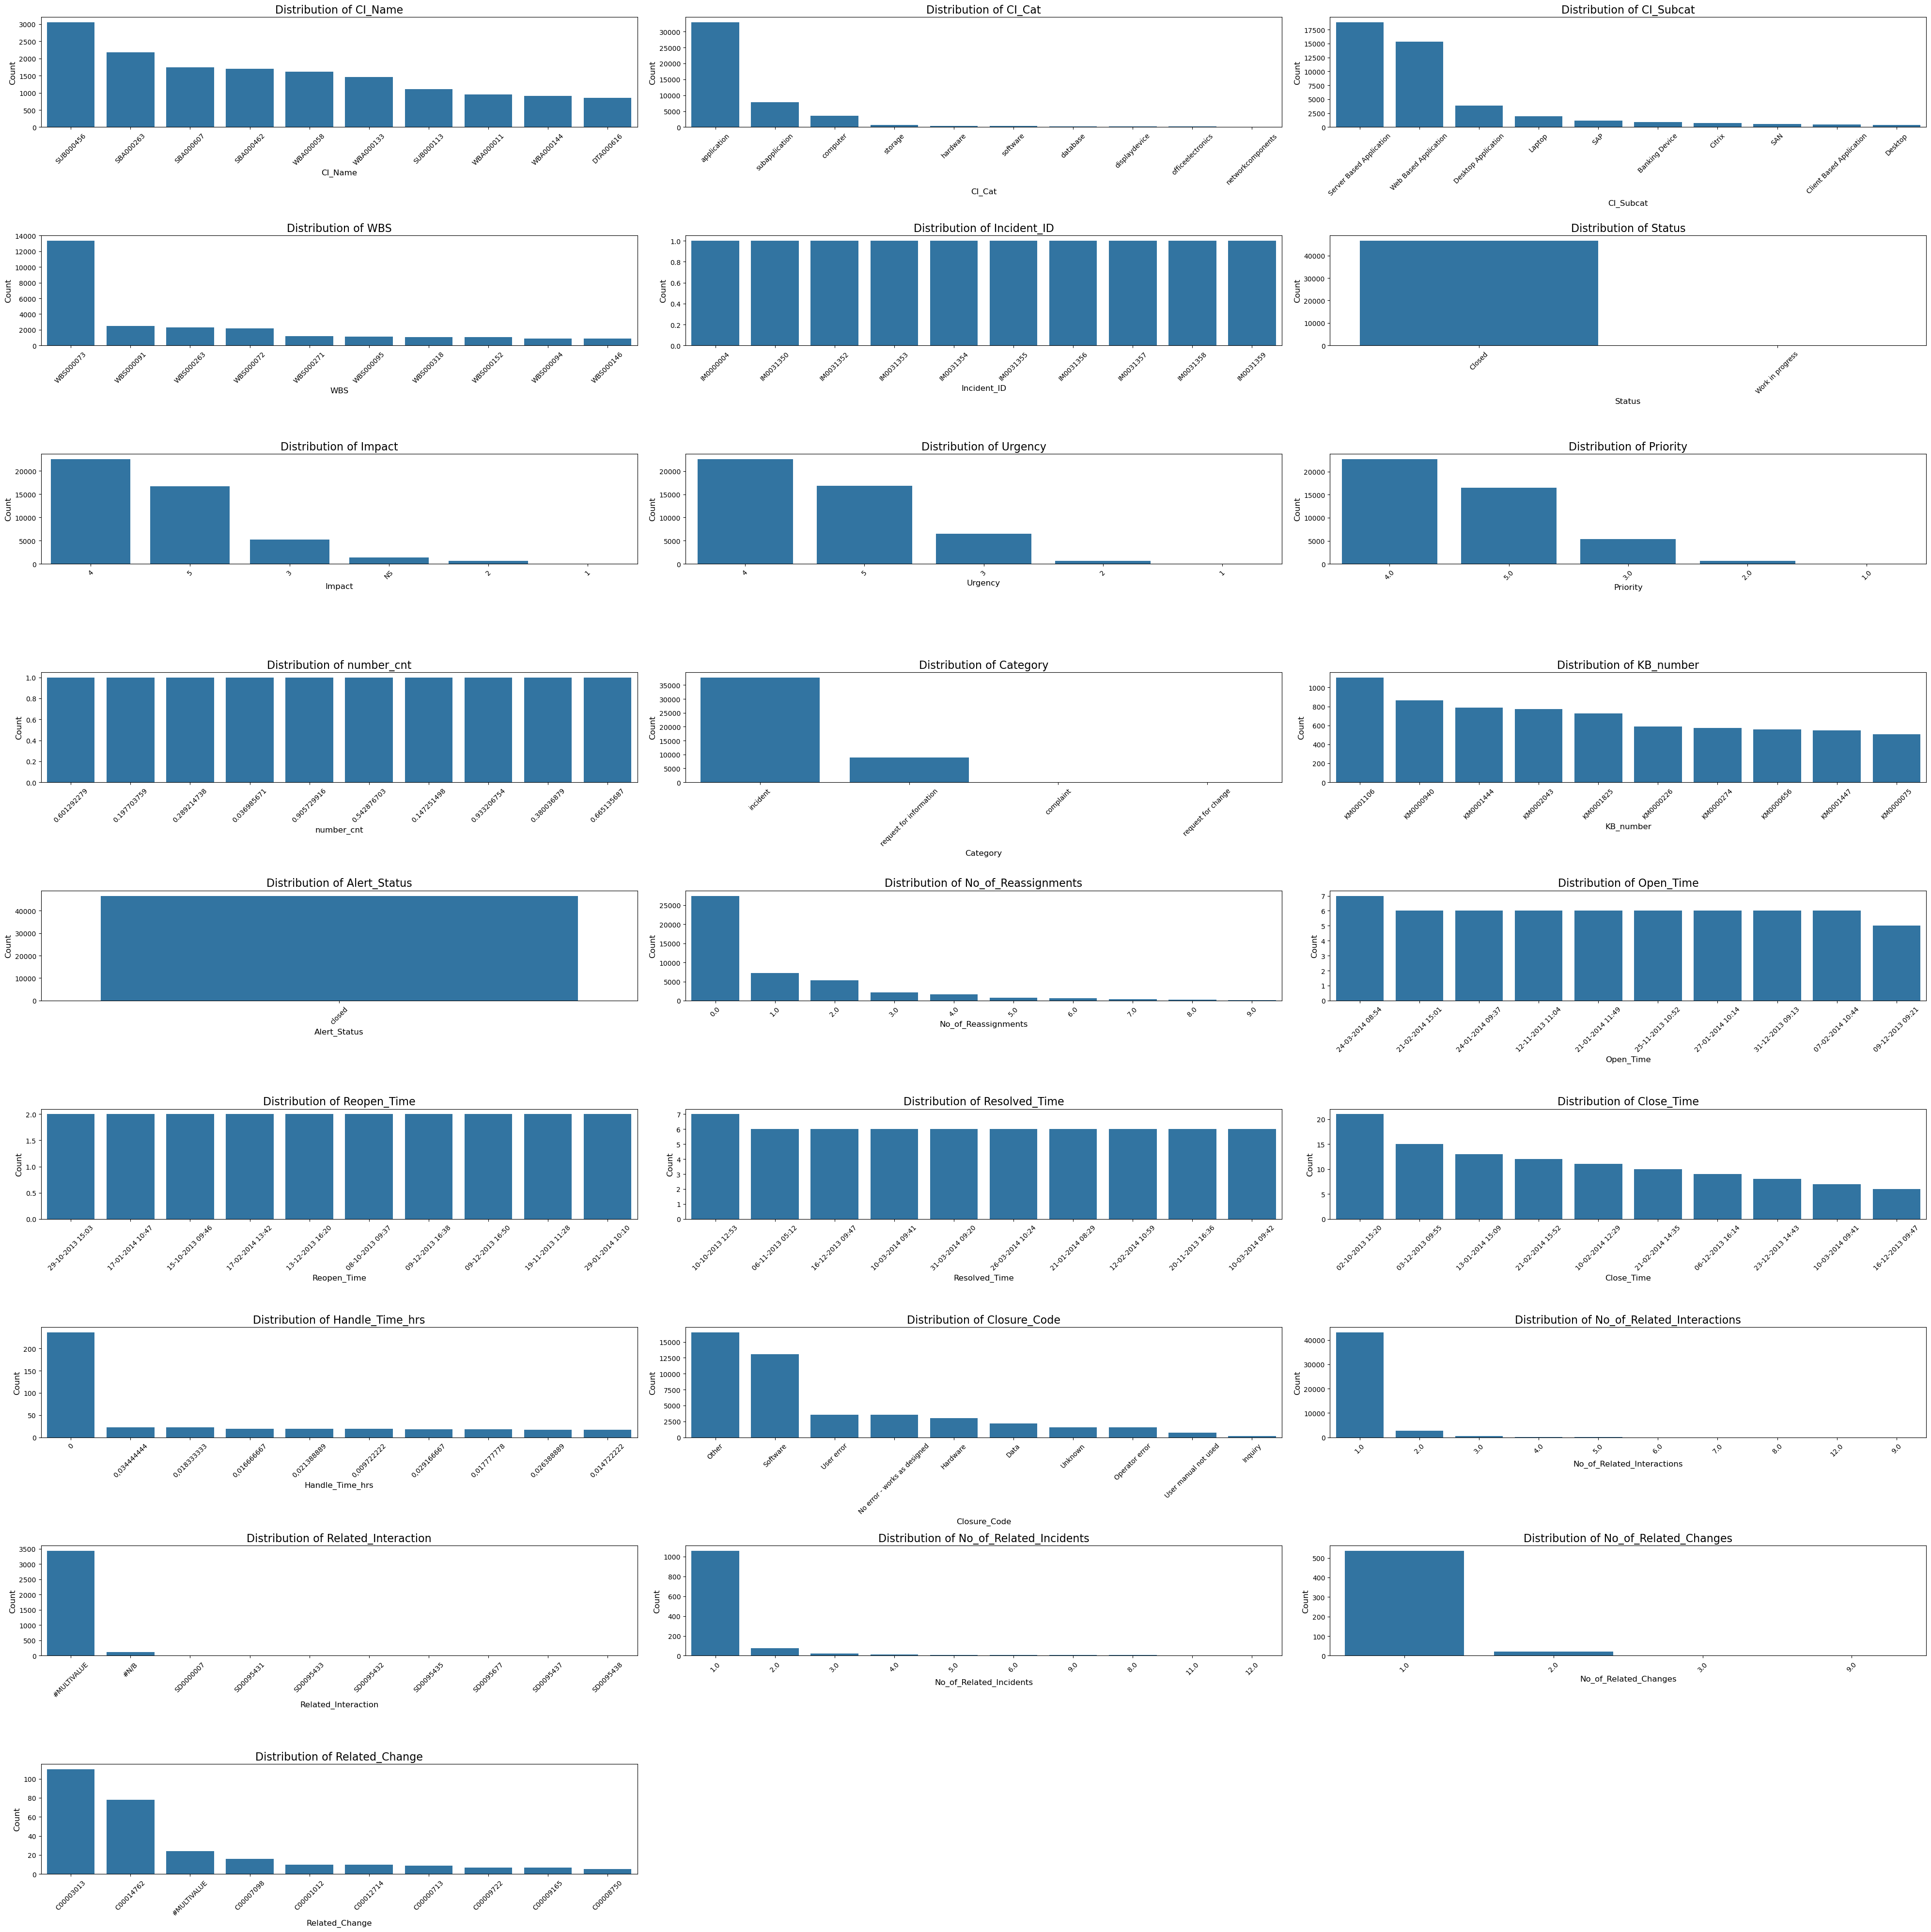

In [11]:

plt.figure(figsize=(40, 40), facecolor='white')

plotnumber = 1
n_cols = 3
n_rows = (len(df.columns) + n_cols - 1) // n_cols

for column in df.columns:
    ax = plt.subplot(n_rows, n_cols, plotnumber)

    # Limit categories for readability
    top_n = 10
    order = df[column].value_counts().head(top_n).index

    sns.countplot(
        data=df,
        x=column,
        order=order,
        ax=ax
    )

    ax.set_title(f'Distribution of {column}', fontsize=16)
    ax.set_xlabel(column, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.tick_params(axis='x', rotation=45)

    plotnumber += 1

plt.tight_layout()
plt.show()

In [12]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print("Unique values:",df[col].unique())
    

    print("\nValue counts:",df[col].value_counts())
   
    print(f"------------------------------------------------")



Column: CI_Name
Unique values: ['SUB000508' 'WBA000124' 'DTA000024' ... 'CBD000595' 'CBD000443'
 'SWT000008']

Value counts: CI_Name
SUB000456    3050
SBA000263    2176
SBA000607    1743
SBA000462    1698
WBA000058    1614
             ... 
LAP001572       1
LAP000809       1
LAP000513       1
CBD000266       1
SWT000008       1
Name: count, Length: 3019, dtype: int64
------------------------------------------------

Column: CI_Cat
Unique values: ['subapplication' 'application' 'computer' nan 'displaydevice' 'software'
 'storage' 'database' 'hardware' 'officeelectronics' 'networkcomponents'
 'applicationcomponent' 'Phone']

Value counts: CI_Cat
application             32900
subapplication           7782
computer                 3643
storage                   703
hardware                  442
software                  333
database                  214
displaydevice             212
officeelectronics         152
networkcomponents         107
applicationcomponent        5
Phone           

Corrupt data exist in CI_Cat, CI_Subcat, Closure_Code, No_of_Related_Interactions, No_of_Related_Incidents, No_of_Related_Changes, Related_Change

No need of Alert_Status columns.

Status columns has only 9 rows.

In [13]:
df[df['Priority']==2]

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
849,WSR000008,computer,Windows Server,WBS000102,IM0000944,Closed,2,2,2.0,0.798444,...,NaN,01-10-2013 18:20,01-10-2013 18:23,"2,43,70,27,778",User error,1.0,SD0001198,NaN,1.0,C00000517
1126,WBA000124,application,Web Based Application,WBS000088,IM0001225,Closed,2,2,2.0,0.509363,...,NaN,NaN,01-10-2013 15:34,"7,27,05,55,556",Other,1.0,SD0001639,NaN,NaN,NaN
1128,OVR000033,NaN,NaN,WBS000118,IM0001227,Closed,2,2,2.0,0.647833,...,NaN,NaN,01-10-2013 09:14,"0,807777778",Operator error,1.0,SD0001642,NaN,1.0,C00001549
1129,WBA000124,application,Web Based Application,WBS000088,IM0001228,Closed,2,2,2.0,0.734261,...,NaN,NaN,01-10-2013 15:34,"7,11,27,77,778",Other,1.0,SD0001641,NaN,NaN,NaN
1185,CBD000911,computer,Banking Device,WBS000146,IM0001285,Closed,2,2,2.0,0.570667,...,01-10-2013 12:56,01-10-2013 12:57,01-10-2013 12:57,"2,77,52,77,778",Other,1.0,SD0001738,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46362,SBA000263,application,Server Based Application,WBS000072,IM0046810,Closed,2,2,2.0,0.736677,...,NaN,28-03-2014 15:41,28-03-2014 15:41,"1,86,22,22,222",Other,1.0,SD0145642,NaN,NaN,NaN
46386,APP000005,application,Citrix,WBS000335,IM0046835,Closed,2,2,2.0,0.514474,...,NaN,30-03-2014 03:19,30-03-2014 03:19,"0,5375",Software,1.0,SD0146035,NaN,NaN,NaN
46416,WBA000011,application,Web Based Application,WBS000152,IM0046865,Closed,3,1,2.0,0.870740,...,NaN,31-03-2014 12:04,31-03-2014 12:05,"4,07",Software,12.0,#MULTIVALUE,12.0,1.0,C00000385
46482,SWT000008,networkcomponents,Switch,WBS000281,IM0046932,Closed,2,2,2.0,0.316205,...,NaN,31-03-2014 14:51,31-03-2014 14:52,"1,88,80,55,556",No error - works as designed,1.0,SD0146305,NaN,NaN,NaN


In [14]:

df.loc[df['Priority'].isnull(), :]

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NaN,0.517551,...,NaN,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1.0,SD0000017,NaN,NaN,NaN
8,WBA000124,application,Web Based Application,WBS000088,IM0000017,Closed,NS,3,NaN,0.269574,...,NaN,08-11-2013 14:02,08-11-2013 14:02,"0,862777778",Other,1.0,SD0000036,NaN,NaN,NaN
103,SBA000782,application,Server Based Application,WBS000043,IM0000151,Closed,NS,3,NaN,0.610829,...,NaN,17-10-2013 15:03,17-10-2013 15:03,"9,64,76,66,667",Other,1.0,SD0000177,NaN,NaN,NaN
147,SBA000782,application,Server Based Application,WBS000043,IM0000199,Closed,NS,3,NaN,0.724279,...,NaN,09-12-2013 14:49,09-12-2013 14:50,"11,26,525",Other,1.0,SD0000228,NaN,NaN,NaN
152,SBA000782,application,Server Based Application,WBS000043,IM0000205,Closed,NS,3,NaN,0.374449,...,NaN,09-12-2013 14:46,09-12-2013 14:46,"1,11,86,48,333",Other,1.0,SD0000233,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46424,SBA000172,application,Server Based Application,WBS000014,IM0046873,Closed,NS,3,NaN,0.343793,...,NaN,31-03-2014 09:20,31-03-2014 09:20,"1,01,97,22,222",Other,1.0,SD0146117,NaN,NaN,NaN
46446,ADB000010,database,Database,WBS000239,IM0046895,Closed,NS,3,NaN,0.647066,...,NaN,31-03-2014 11:14,31-03-2014 11:14,"3,01,11,11,111",User error,1.0,SD0146192,NaN,NaN,NaN
46484,SBA000759,application,Server Based Application,WBS000296,IM0046934,Closed,NS,3,NaN,0.722611,...,NaN,31-03-2014 11:10,31-03-2014 11:10,"0,39",Other,1.0,SD0146455,NaN,NaN,NaN
46553,CNT000046,storage,Controller,WBS000183,IM0047005,Closed,NS,3,NaN,0.123493,...,NaN,31-03-2014 20:35,31-03-2014 20:35,"0,485277778",Hardware,1.0,SD0146607,NaN,NaN,NaN


# Data Cleaning

## Checking Data has Null Values.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     46606 non-null  object 
 1   CI_Cat                      46495 non-null  object 
 2   CI_Subcat                   46495 non-null  object 
 3   WBS                         46606 non-null  object 
 4   Incident_ID                 46606 non-null  object 
 5   Status                      46606 non-null  object 
 6   Impact                      46606 non-null  object 
 7   Urgency                     46606 non-null  object 
 8   Priority                    45226 non-null  float64
 9   number_cnt                  46606 non-null  float64
 10  Category                    46606 non-null  object 
 11  KB_number                   46606 non-null  object 
 12  Alert_Status                46606 non-null  object 
 13  No_of_Reassignments         466

In [16]:
df.isna().sum()

CI_Name                           0
CI_Cat                          111
CI_Subcat                       111
WBS                               0
Incident_ID                       0
Status                            0
Impact                            0
Urgency                           0
Priority                       1380
number_cnt                        0
Category                          0
KB_number                         0
Alert_Status                      0
No_of_Reassignments               1
Open_Time                         0
Reopen_Time                   44322
Resolved_Time                  1780
Close_Time                        0
Handle_Time_hrs                   1
Closure_Code                    460
No_of_Related_Interactions      114
Related_Interaction               0
No_of_Related_Incidents       45384
No_of_Related_Changes         46046
Related_Change                46046
dtype: int64

Null value exist 

* Numeric columns: Priority, No_of_Related_Interactions, No_of_Related_Incidents, No_of_Related_Changes, Related_Change. So these were replaced by median or means values
* Categorical Columns: CI_Cat, CI_Subcat and Closure_Code. So these were replaced by mode
* Date-time columns: Reopen Time and Resolved time. 

In [17]:
df['CI_Cat']=df['CI_Cat'].fillna(df['CI_Cat'].mode()[0])
df['CI_Subcat']=df['CI_Subcat'].fillna(df['CI_Subcat'].mode()[0])
df['Priority']=df['Priority'].fillna(df['Priority'].mode()[0])
df['Resolved_Time']=df['Resolved_Time'].fillna(df['Resolved_Time'].mode()[0])
df['Closure_Code']=df['Closure_Code'].fillna(df['Closure_Code'].mode()[0])
df['No_of_Related_Interactions']=df['No_of_Related_Interactions'].fillna(df['No_of_Related_Interactions'].mode()[0])

**Reason:**
Here null values are less than 5% thus replace with the mode values.

In [18]:
df = df.dropna(subset=['No_of_Reassignments', 'Handle_Time_hrs'], how='all')

**Reason:**
Here null values exist in one row only thus dorp it.

In [19]:
df.isna().sum()

CI_Name                           0
CI_Cat                            0
CI_Subcat                         0
WBS                               0
Incident_ID                       0
Status                            0
Impact                            0
Urgency                           0
Priority                          0
number_cnt                        0
Category                          0
KB_number                         0
Alert_Status                      0
No_of_Reassignments               0
Open_Time                         0
Reopen_Time                   44321
Resolved_Time                     0
Close_Time                        0
Handle_Time_hrs                   0
Closure_Code                      0
No_of_Related_Interactions        0
Related_Interaction               0
No_of_Related_Incidents       45383
No_of_Related_Changes         46045
Related_Change                46045
dtype: int64

In [20]:
df = df.drop(columns=['Reopen_Time', 'Related_Change', 'Status','Alert_Status'])

**Reason :** There is no use of these column thus drop it.

In [21]:
df['has_related_incidents'] = df['No_of_Related_Incidents'].notnull().astype(int)
df['has_related_changes'] = df['No_of_Related_Changes'].notnull().astype(int)

In [22]:
df['No_of_Related_Incidents'] = df['No_of_Related_Incidents'].fillna(0)
df['No_of_Related_Changes'] = df['No_of_Related_Changes'].fillna(0)

**Reason:**
* 0 = no related incidents/changes

* Preserves business meaning

* Prevents model distortion

In [23]:
df.isna().sum()

CI_Name                       0
CI_Cat                        0
CI_Subcat                     0
WBS                           0
Incident_ID                   0
Impact                        0
Urgency                       0
Priority                      0
number_cnt                    0
Category                      0
KB_number                     0
No_of_Reassignments           0
Open_Time                     0
Resolved_Time                 0
Close_Time                    0
Handle_Time_hrs               0
Closure_Code                  0
No_of_Related_Interactions    0
Related_Interaction           0
No_of_Related_Incidents       0
No_of_Related_Changes         0
has_related_incidents         0
has_related_changes           0
dtype: int64

# Check Data has duplicate or not

In [24]:
df.duplicated().sum()

0

**Insights:** It has no duplicate values.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46605 entries, 0 to 46605
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Name                     46605 non-null  object 
 1   CI_Cat                      46605 non-null  object 
 2   CI_Subcat                   46605 non-null  object 
 3   WBS                         46605 non-null  object 
 4   Incident_ID                 46605 non-null  object 
 5   Impact                      46605 non-null  object 
 6   Urgency                     46605 non-null  object 
 7   Priority                    46605 non-null  float64
 8   number_cnt                  46605 non-null  float64
 9   Category                    46605 non-null  object 
 10  KB_number                   46605 non-null  object 
 11  No_of_Reassignments         46605 non-null  float64
 12  Open_Time                   46605 non-null  object 
 13  Resolved_Time               46605 no

## Drop Corrupt Values

In [26]:
df = df[df['Impact'] != 'NS']

**Reason:** Drop the rows that contain 'NS' values.

In [27]:
print(df['Impact'].value_counts())
print(df['Urgency'].value_counts())
print(df['Priority'].value_counts())

Impact
4    22556
5    16740
3     5234
2      692
1        3
Name: count, dtype: int64
Urgency
4               15506
5               12283
4                7050
5                4495
3                3507
3                1681
2                 538
2                 158
1                   5
1                   1
5 - Very Low        1
Name: count, dtype: int64
Priority
4.0    22717
5.0    16485
3.0     5323
2.0      697
1.0        3
Name: count, dtype: int64


## Categorical data Handeling

##### Manula Encoding

In [28]:
df['Urgency'] = df['Urgency'].astype(str).str.strip()
impact_map = {
    '1':1,
    '2':2,
    '3':3,
    '4':4,
    '5':5,
    '5 - Very Low':5
}

df['Urgency'] = df['Urgency'].map(impact_map)

**Reason:** Convert strings to the interger. because incorrect data type assigned

In [29]:
df['Urgency'].value_counts()

Urgency
4    22556
5    16779
3     5188
2      696
1        6
Name: count, dtype: int64

In [30]:
df[['Impact','Priority']] = df[['Impact','Priority']].astype(int)

**Reason:** Convert strings to the interger.

In [31]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print("Unique values:",df[col].unique())
    

    #print("\nValue counts:",df[col].value_counts())
   
    print(f"------------------------------------------------")



Column: CI_Name
Unique values: ['SUB000508' 'WBA000124' 'WBA000082' ... 'CBD000595' 'CBD000443'
 'SWT000008']
------------------------------------------------

Column: CI_Cat
Unique values: ['subapplication' 'application' 'computer' 'displaydevice' 'software'
 'storage' 'database' 'hardware' 'officeelectronics' 'networkcomponents'
 'applicationcomponent' 'Phone']
------------------------------------------------

Column: CI_Subcat
Unique values: ['Web Based Application' 'Server Based Application' 'Desktop Application'
 'SAP' 'Client Based Application' 'Citrix' 'Standard Application'
 'Windows Server' 'Laptop' 'Linux Server' 'Monitor' 'Automation Software'
 'SAN' 'Banking Device' 'Desktop' 'Database' 'Oracle Server' 'Keyboard'
 'Printer' 'Exchange' 'System Software' 'VDI' 'Encryption' 'Omgeving'
 'MigratieDummy' 'Scanner' 'Controller' 'DataCenterEquipment'
 'KVM Switches' 'Switch' 'Database Software' 'Network Component'
 'Unix Server' 'Lines' 'ESX Cluster' 'zOS Server' 'SharePoint Farm'

In [32]:
filtered_df = df[df['has_related_changes'].isin([1])]
#filtered_df.groupby('Category').size()
['CI_Cat', 'Category' ,'No_of_Related_Changes']

['CI_Cat', 'Category', 'No_of_Related_Changes']

In [33]:
filtered_df

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Impact,Urgency,Priority,number_cnt,Category,...,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,has_related_incidents,has_related_changes
10,WBA000124,application,Web Based Application,WBS000088,IM0000019,4,4,4,0.439909,incident,...,08-11-2013 14:23,08-11-2013 14:23,"3,06,74,49,167",Software,1.0,SD0000040,0.0,1.0,0,1
38,WBA000124,application,Web Based Application,WBS000088,IM0000064,3,3,3,0.481873,incident,...,08-11-2013 15:35,08-11-2013 15:35,"2,16,22,22,222",Software,1.0,SD0000090,0.0,2.0,0,1
43,SUB000508,subapplication,Web Based Application,WBS000162,IM0000074,3,3,3,0.695187,incident,...,24-03-2014 13:28,24-03-2014 13:28,"1,56,41,90,278",Other,2.0,#MULTIVALUE,1.0,1.0,1,1
54,SBA000045,application,Server Based Application,WBS000170,IM0000090,5,5,5,0.283635,incident,...,22-01-2014 16:19,22-01-2014 16:20,"21,97",Unknown,1.0,SD0000113,1.0,1.0,1,1
119,STA000033,application,Standard Application,WBS000066,IM0000168,5,5,5,0.875886,incident,...,18-11-2013 09:14,18-11-2013 09:15,"5,23,78,69,444",Software,1.0,SD0000195,2.0,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45411,DTA000024,application,Desktop Application,WBS000092,IM0045838,2,3,2,0.427608,incident,...,26-03-2014 08:10,26-03-2014 08:11,"7,16,91,66,667",Software,34.0,#MULTIVALUE,15.0,1.0,1,1
45552,SBA000360,application,Server Based Application,WBS000073,IM0045982,5,5,5,0.371645,incident,...,31-03-2014 12:45,31-03-2014 12:46,"3,23,77,77,778",Software,1.0,SD0142759,0.0,1.0,0,1
45974,SUB000508,subapplication,Web Based Application,WBS000162,IM0046410,4,4,4,0.174987,incident,...,27-03-2014 12:58,27-03-2014 12:58,"3,01,69,44,444",Other,1.0,SD0144243,0.0,1.0,0,1
46109,SUB000417,subapplication,Server Based Application,WBS000073,IM0046548,4,4,4,0.424200,incident,...,28-03-2014 15:59,28-03-2014 15:59,"1,04,18,05,556",Operator error,1.0,SD0144922,0.0,1.0,0,1


In [34]:
filtered_df1 = df[df['Category'].isin([ 'complaint'])]

In [35]:
filtered_df1

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Impact,Urgency,Priority,number_cnt,Category,...,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,has_related_incidents,has_related_changes
1096,HMD000025,hardware,MigratieDummy,WBS000258,IM0001194,5,5,5,0.627939,complaint,...,21-10-2013 12:43,21-10-2013 12:43,"1,55,93,63,889",Kwaliteit van de output,1.0,SD0001443,0.0,0.0,0,0
8720,HMD000025,hardware,MigratieDummy,WBS000258,IM0008883,5,5,5,0.124577,complaint,...,31-10-2013 17:36,31-10-2013 17:36,"2,83,89,72,222",Kwaliteit van de output,1.0,SD0023840,0.0,0.0,0,0
9713,HMD000025,hardware,MigratieDummy,WBS000258,IM0009878,5,5,5,0.802733,complaint,...,31-10-2013 17:38,31-10-2013 17:39,"2,30,30,55,556",Kwaliteit van de output,1.0,SD0027175,0.0,0.0,0,0
9733,HMD000025,hardware,MigratieDummy,WBS000258,IM0009898,5,5,5,0.687447,complaint,...,15-11-2013 15:22,15-11-2013 15:22,"1,13,03,58,333",Kwaliteit van de output,1.0,SD0027382,0.0,0.0,0,0
16813,HMD000025,hardware,MigratieDummy,WBS000258,IM0017028,5,5,5,0.306815,complaint,...,27-12-2013 11:44,27-12-2013 11:44,"2,16,83,19,444",Kwaliteit van de output,1.0,SD0048762,0.0,0.0,0,0
20264,SAN000182,storage,SAN,WBS000128,IM0020494,5,5,5,0.657625,complaint,...,13-12-2013 15:21,13-12-2013 15:21,"2,21,83,05,556",Overig,1.0,SD0060149,0.0,0.0,0,0
28907,HMD000025,hardware,MigratieDummy,WBS000258,IM0029184,5,5,5,0.956354,complaint,...,20-02-2014 15:29,20-02-2014 15:29,"1,04,69,94,444",Kwaliteit van de output,1.0,SD0088441,0.0,0.0,0,0
29523,HMD000025,hardware,MigratieDummy,WBS000258,IM0029805,5,5,5,0.012663,complaint,...,20-02-2014 15:31,20-02-2014 15:32,"9,08,51,94,444",Kwaliteit van de output,1.0,SD0090270,0.0,0.0,0,0
34699,SAN000182,storage,SAN,WBS000128,IM0035002,5,5,5,0.378607,complaint,...,10-10-2013 12:53,28-02-2014 19:08,"1,68,05,69,444",Kwaliteit van de output,1.0,SD0106145,0.0,0.0,0,0
38740,SAN000182,storage,SAN,WBS000128,IM0039064,5,5,5,0.136879,complaint,...,28-02-2014 09:53,28-02-2014 09:53,"4,03,52,22,222",Kwaliteit van de output,1.0,SD0119106,0.0,0.0,0,0


In [36]:
df['Handle_Time_hrs'] = df['Handle_Time_hrs'].str.replace(',', '', regex=False)

In [37]:
df['Handle_Time_hrs'].value_counts()
df['Handle_Time_hrs'] = pd.to_numeric(
    df['Handle_Time_hrs'],
    errors='coerce'
)

In [38]:
date_cols = ['Open_Time', 'Resolved_Time', 'Close_Time']

df[date_cols] = df[date_cols].apply(
    lambda x: pd.to_datetime(
        x,
        format='%d-%m-%Y %H:%M',
        errors='coerce'
    )
)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45225 entries, 0 to 46605
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   CI_Name                     45225 non-null  object        
 1   CI_Cat                      45225 non-null  object        
 2   CI_Subcat                   45225 non-null  object        
 3   WBS                         45225 non-null  object        
 4   Incident_ID                 45225 non-null  object        
 5   Impact                      45225 non-null  int32         
 6   Urgency                     45225 non-null  int64         
 7   Priority                    45225 non-null  int32         
 8   number_cnt                  45225 non-null  float64       
 9   Category                    45225 non-null  object        
 10  KB_number                   45225 non-null  object        
 11  No_of_Reassignments         45225 non-null  float64       


## Feature Engineering
Createing Departments with the help of CI_Cat and CI_Subcat.

In [40]:
department_mapping = {
    # -------- Application Support --------
    "Web Based Application": "Application Support",
    "Server Based Application": "Application Support",
    "Desktop Application": "Application Support",
    "Client Based Application": "Application Support",
    "Standard Application": "Application Support",
    "SAP": "Application Support",
    "SharePoint Farm": "Application Support",
    "Application Server": "Application Support",

    # -------- Server & OS Support --------
    "Windows Server": "Server & OS Support",
    "Linux Server": "Server & OS Support",
    "Unix Server": "Server & OS Support",
    "Oracle Server": "Server & OS Support",
    "X86 Server": "Server & OS Support",
    "ESX Server": "Server & OS Support",
    "ESX Cluster": "Server & OS Support",
    "Windows Server in extern beheer": "Server & OS Support",
    "Instance": "Server & OS Support",

    # -------- Database Support --------
    "Database": "Database Support",
    "Database Software": "Database Support",
    "RAC Service": "Database Support",
    "MQ Queue Manager": "Database Support",
    "Neoview Server": "Database Support",

    # -------- Network --------
    "Switch": "Network & Connectivity",
    "Router": "Network & Connectivity",
    "Firewall": "Network & Connectivity",
    "Modem": "Network & Connectivity",
    "Network Component": "Network & Connectivity",
    "Net Device": "Network & Connectivity",
    "Protocol": "Network & Connectivity",
    "Lines": "Network & Connectivity",

    # -------- EUC --------
    "Laptop": "End User Computing",
    "Desktop": "End User Computing",
    "Monitor": "End User Computing",
    "Keyboard": "End User Computing",
    "Printer": "End User Computing",
    "Scanner": "End User Computing",
    "Thin Client": "End User Computing",

    # -------- Security --------
    "Encryption": "Security",
    "Security Software": "Security",

    # -------- Storage --------
    "SAN": "Storage & Backup",
    "Tape Library": "Storage & Backup",
    "Virtual Tape Server": "Storage & Backup",
    "NonStop Harddisk": "Storage & Backup",
    "UPS": "Storage & Backup",

    # -------- Virtualization --------
    "VDI": "Virtualization",
    "Citrix": "Virtualization",
    "KVM Switches": "Virtualization",

    # -------- Messaging --------
    "Exchange": "Messaging & Collaboration",

    # -------- Telephony --------
    "IPtelephony": "Telephony",
    "Iptelephony": "Telephony",
    "Number": "Telephony",
    "Banking Device": "Telephony",

    # -------- Data Center --------
    "DataCenterEquipment": "Data Center Operations",
    "Controller": "Data Center Operations",

    # -------- Mainframe --------
    "zOS Server": "Mainframe / Legacy",
    "zOS Cluster": "Mainframe / Legacy",
    "zOS Systeem": "Mainframe / Legacy",
    "NonStop Server": "Mainframe / Legacy",

    # -------- Automation --------
    "Automation Software": "Automation / Tools",

    # -------- Unknown --------
    "Omgeving": "Unknown",
    "MigratieDummy": "Unknown"
}
df['Department'] = (
    df['CI_Subcat']
    .map(department_mapping)
    .fillna('Unknown')
)

In [41]:
df.head()

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Impact,Urgency,Priority,number_cnt,Category,...,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,has_related_incidents,has_related_changes,Department
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,4,4,4,0.601292,incident,...,2013-11-04 13:51:00,3871691111,Other,1.0,SD0000007,2.0,0.0,1,0,Application Support
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,3,3,3,0.415050,incident,...,2013-12-02 12:36:00,4354786389,Software,1.0,SD0000011,1.0,0.0,1,0,Application Support
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,4,4,4,0.642927,incident,...,2013-11-14 09:31:00,4321833333,Operator error,1.0,SD0000025,0.0,0.0,0,0,Application Support
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,4,4,4,0.345258,incident,...,2013-11-08 13:55:00,3383903333,Other,1.0,SD0000029,0.0,0.0,0,0,Application Support
5,WBA000124,application,Web Based Application,WBS000088,IM0000013,4,4,4,0.006676,incident,...,2013-11-08 13:54:00,3383436944,Other,1.0,SD0000031,0.0,0.0,0,0,Application Support


In [42]:
df['Department'].value_counts()

Department
Application Support          38814
End User Computing            2706
Telephony                      880
Virtualization                 803
Storage & Backup               535
Unknown                        375
Data Center Operations         359
Server & OS Support            219
Database Support               174
Messaging & Collaboration      130
Network & Connectivity         100
Automation / Tools              55
Security                        46
Mainframe / Legacy              29
Name: count, dtype: int64

In [43]:
department_code_map = {
    "Mainframe / Legacy": 13,
    "Server & OS Support": 7,
    "Network & Connectivity": 10,
    "Security": 12,
    "Database Support": 8,
    "Storage & Backup": 4,
    "Data Center Operations": 6,
    "Virtualization": 3,
    "Messaging & Collaboration": 9,
    "Application Support": 0,
    "Telephony": 2,
    "Automation / Tools": 11,
    "End User Computing": 1,
    "Unknown": 5
}
df['Department'] = df['Department'].map(department_code_map)

In [44]:
df.to_csv("Basic_Cleand_data.csv")

#### Frequency Encoding

In [45]:
# Frequency Encoding 
import category_encoders as ce
col=['CI_Cat', 'CI_Subcat','Closure_Code']

freq_enc=ce.CountEncoder(cols=['CI_Cat', 'CI_Subcat', 'Category','Closure_Code'], normalize=True)

df_freq=freq_enc.fit_transform(df)
df_freq

,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Impact,Urgency,Priority,number_cnt,Category,...,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,has_related_incidents,has_related_changes,Department
0,SUB000508,0.170702,0.335478,WBS000162,IM0000004,4,4,4,0.601292,0.805152,...,2013-11-04 13:51:00,3871691111,0.366147,1.0,SD0000007,2.0,0.0,1,0,0
1,WBA000124,0.707219,0.335478,WBS000088,IM0000005,3,3,3,0.415050,0.805152,...,2013-12-02 12:36:00,4354786389,0.281083,1.0,SD0000011,1.0,0.0,1,0,0
3,WBA000124,0.707219,0.335478,WBS000088,IM0000011,4,4,4,0.642927,0.805152,...,2013-11-14 09:31:00,4321833333,0.033190,1.0,SD0000025,0.0,0.0,0,0,0
4,WBA000124,0.707219,0.335478,WBS000088,IM0000012,4,4,4,0.345258,0.805152,...,2013-11-08 13:55:00,3383903333,0.366147,1.0,SD0000029,0.0,0.0,0,0,0
5,WBA000124,0.707219,0.335478,WBS000088,IM0000013,4,4,4,0.006676,0.805152,...,2013-11-08 13:54:00,3383436944,0.366147,1.0,SD0000031,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46601,SBA000464,0.707219,0.401813,WBS000073,IM0047053,4,4,4,0.231896,0.805152,...,2014-03-31 16:29:00,95,0.366147,1.0,SD0147021,0.0,0.0,0,0,0
46602,SBA000461,0.707219,0.401813,WBS000073,IM0047054,4,4,4,0.805153,0.805152,...,2014-03-31 15:29:00,428333333,0.072902,1.0,SD0146967,0.0,0.0,0,0,0
46603,LAP000019,0.078364,0.042012,WBS000091,IM0047055,5,5,5,0.917466,0.805152,...,2014-03-31 15:32:00,71666667,0.062598,1.0,SD0146982,0.0,0.0,0,0,1
46604,WBA000058,0.707219,0.335478,WBS000073,IM0047056,4,4,4,0.701278,0.805152,...,2014-03-31 15:42:00,116944444,0.281083,1.0,SD0146986,0.0,0.0,0,0,0


#### Label Encoding

In [46]:
df['Category'].value_counts()

Category
incident                   36413
request for information     8801
complaint                     11
Name: count, dtype: int64

In [47]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Category']=le.fit_transform(df['Category'])

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45225 entries, 0 to 46605
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   CI_Name                     45225 non-null  object        
 1   CI_Cat                      45225 non-null  object        
 2   CI_Subcat                   45225 non-null  object        
 3   WBS                         45225 non-null  object        
 4   Incident_ID                 45225 non-null  object        
 5   Impact                      45225 non-null  int32         
 6   Urgency                     45225 non-null  int64         
 7   Priority                    45225 non-null  int32         
 8   number_cnt                  45225 non-null  float64       
 9   Category                    45225 non-null  int32         
 10  KB_number                   45225 non-null  object        
 11  No_of_Reassignments         45225 non-null  float64       


In [49]:
col_to_float=['CI_Cat', 'CI_Subcat', 'Category','Closure_Code']

df_freq['CI_Cat'] = df_freq['CI_Cat'].astype(float)
df_freq['CI_Subcat'] = df_freq['CI_Subcat'].astype(float)
df_freq['Category'] = df_freq['Category'].astype(float)
df_freq['Closure_Code'] = df_freq['Closure_Code'].astype(float)

**Reason**: Correcting data type for ML processing

In [50]:
for col in df_freq.columns:
    print(f"\nColumn: {col}")
    print("Unique values:",df_freq[col].unique())
    

    print("\nValue counts:",df_freq[col].value_counts())
   
    print(f"------------------------------------------------")



Column: CI_Name
Unique values: ['SUB000508' 'WBA000124' 'WBA000082' ... 'CBD000595' 'CBD000443'
 'SWT000008']

Value counts: CI_Name
SUB000456    3042
SBA000263    2169
SBA000607    1737
SBA000462    1693
WBA000058    1613
             ... 
LAP000426       1
OVR000082       1
LAP001000       1
LAP001572       1
SWT000008       1
Name: count, Length: 2928, dtype: int64
------------------------------------------------

Column: CI_Cat
Unique values: [1.70702045e-01 7.07219458e-01 7.83637369e-02 4.68767275e-03
 6.50082919e-03 1.44389165e-02 3.71475954e-03 8.97733554e-03
 3.07352128e-03 2.18905473e-03 8.84466556e-05 4.42233278e-05]

Value counts: CI_Cat
0.707219    31984
0.170702     7720
0.078364     3544
0.014439      653
0.008977      406
0.006501      294
0.004688      212
0.003715      168
0.003074      139
0.002189       99
0.000088        4
0.000044        2
Name: count, dtype: int64
------------------------------------------------

Column: CI_Subcat
Unique values: [3.35478165e-01 4

# Outlier Handeling

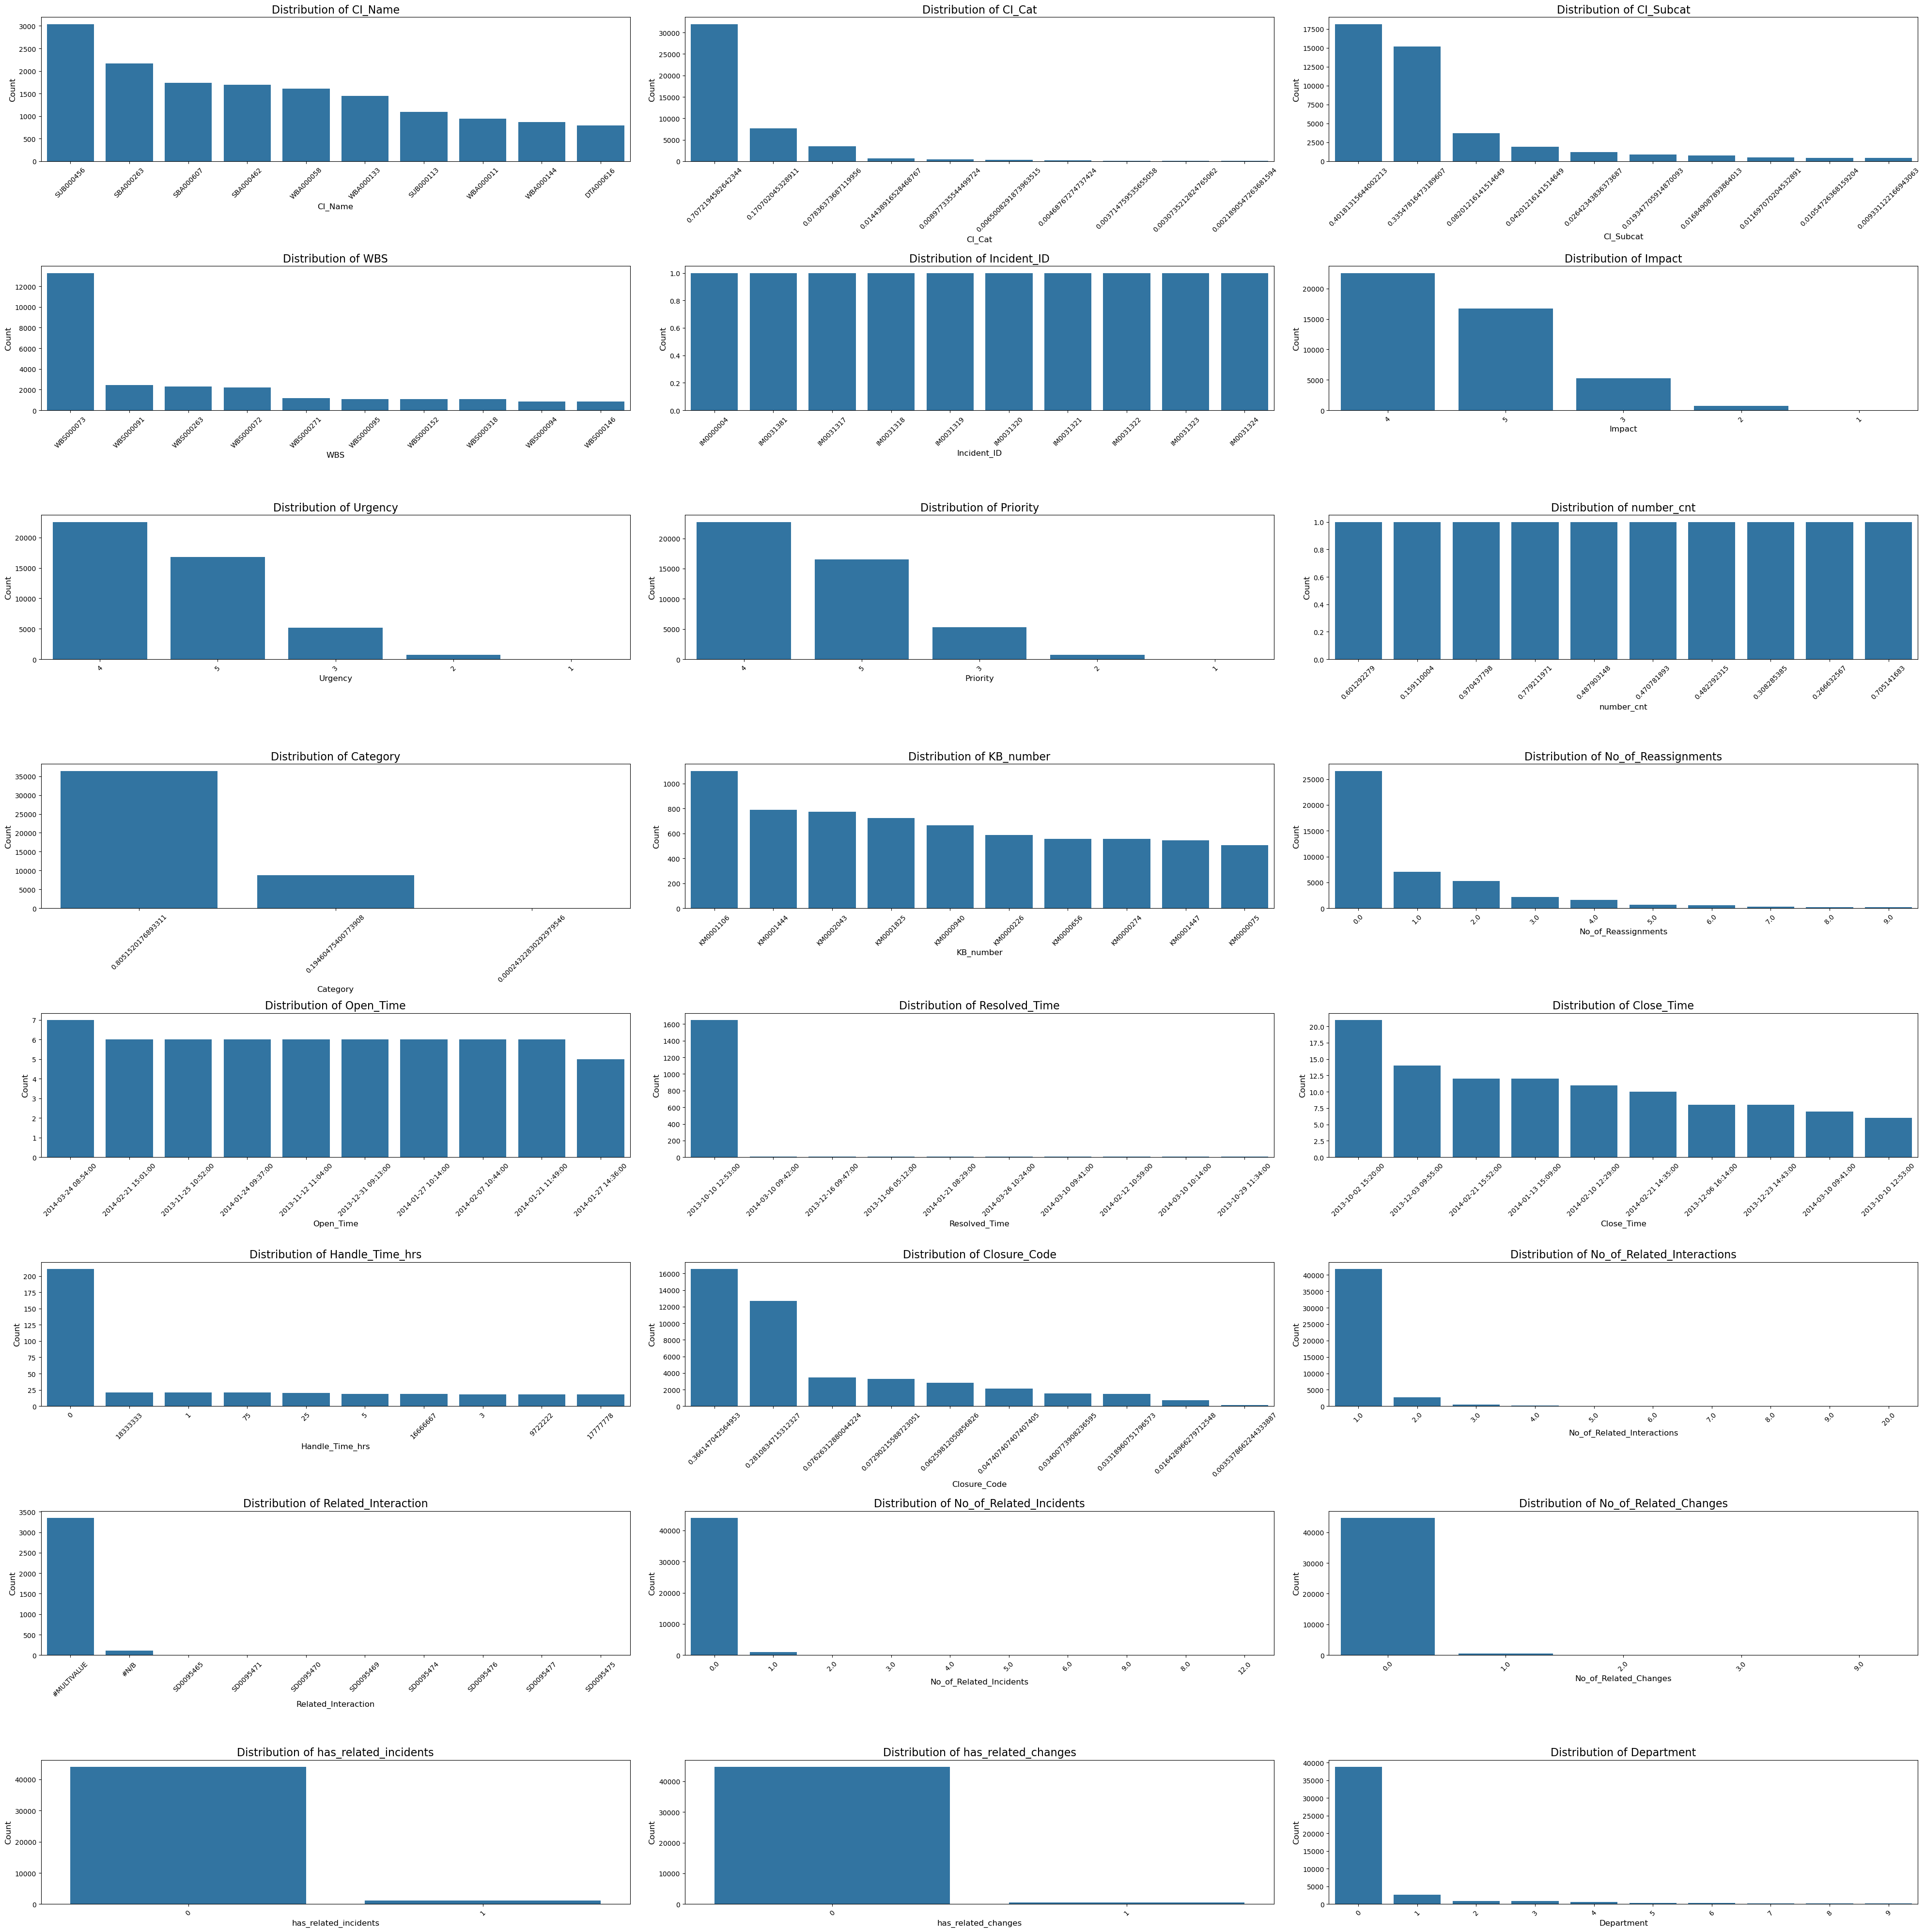

In [51]:

plt.figure(figsize=(40, 40), facecolor='white')

plotnumber = 1
n_cols = 3
n_rows = (len(df_freq.columns) + n_cols - 1) // n_cols

for column in df_freq.columns:
    ax = plt.subplot(n_rows, n_cols, plotnumber)

    # Limit categories for readability
    top_n = 10
    order = df_freq[column].value_counts().head(top_n).index

    sns.countplot(
        data=df_freq,
        x=column,
        order=order,
        ax=ax
    )

    ax.set_title(f'Distribution of {column}', fontsize=16)
    ax.set_xlabel(column, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.tick_params(axis='x', rotation=45)

    plotnumber += 1

plt.tight_layout()
plt.show()

In [52]:
df_freq.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Impact',
       'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'No_of_Reassignments', 'Open_Time', 'Resolved_Time', 'Close_Time',
       'Handle_Time_hrs', 'Closure_Code', 'No_of_Related_Interactions',
       'Related_Interaction', 'No_of_Related_Incidents',
       'No_of_Related_Changes', 'has_related_incidents', 'has_related_changes',
       'Department'],
      dtype='object')

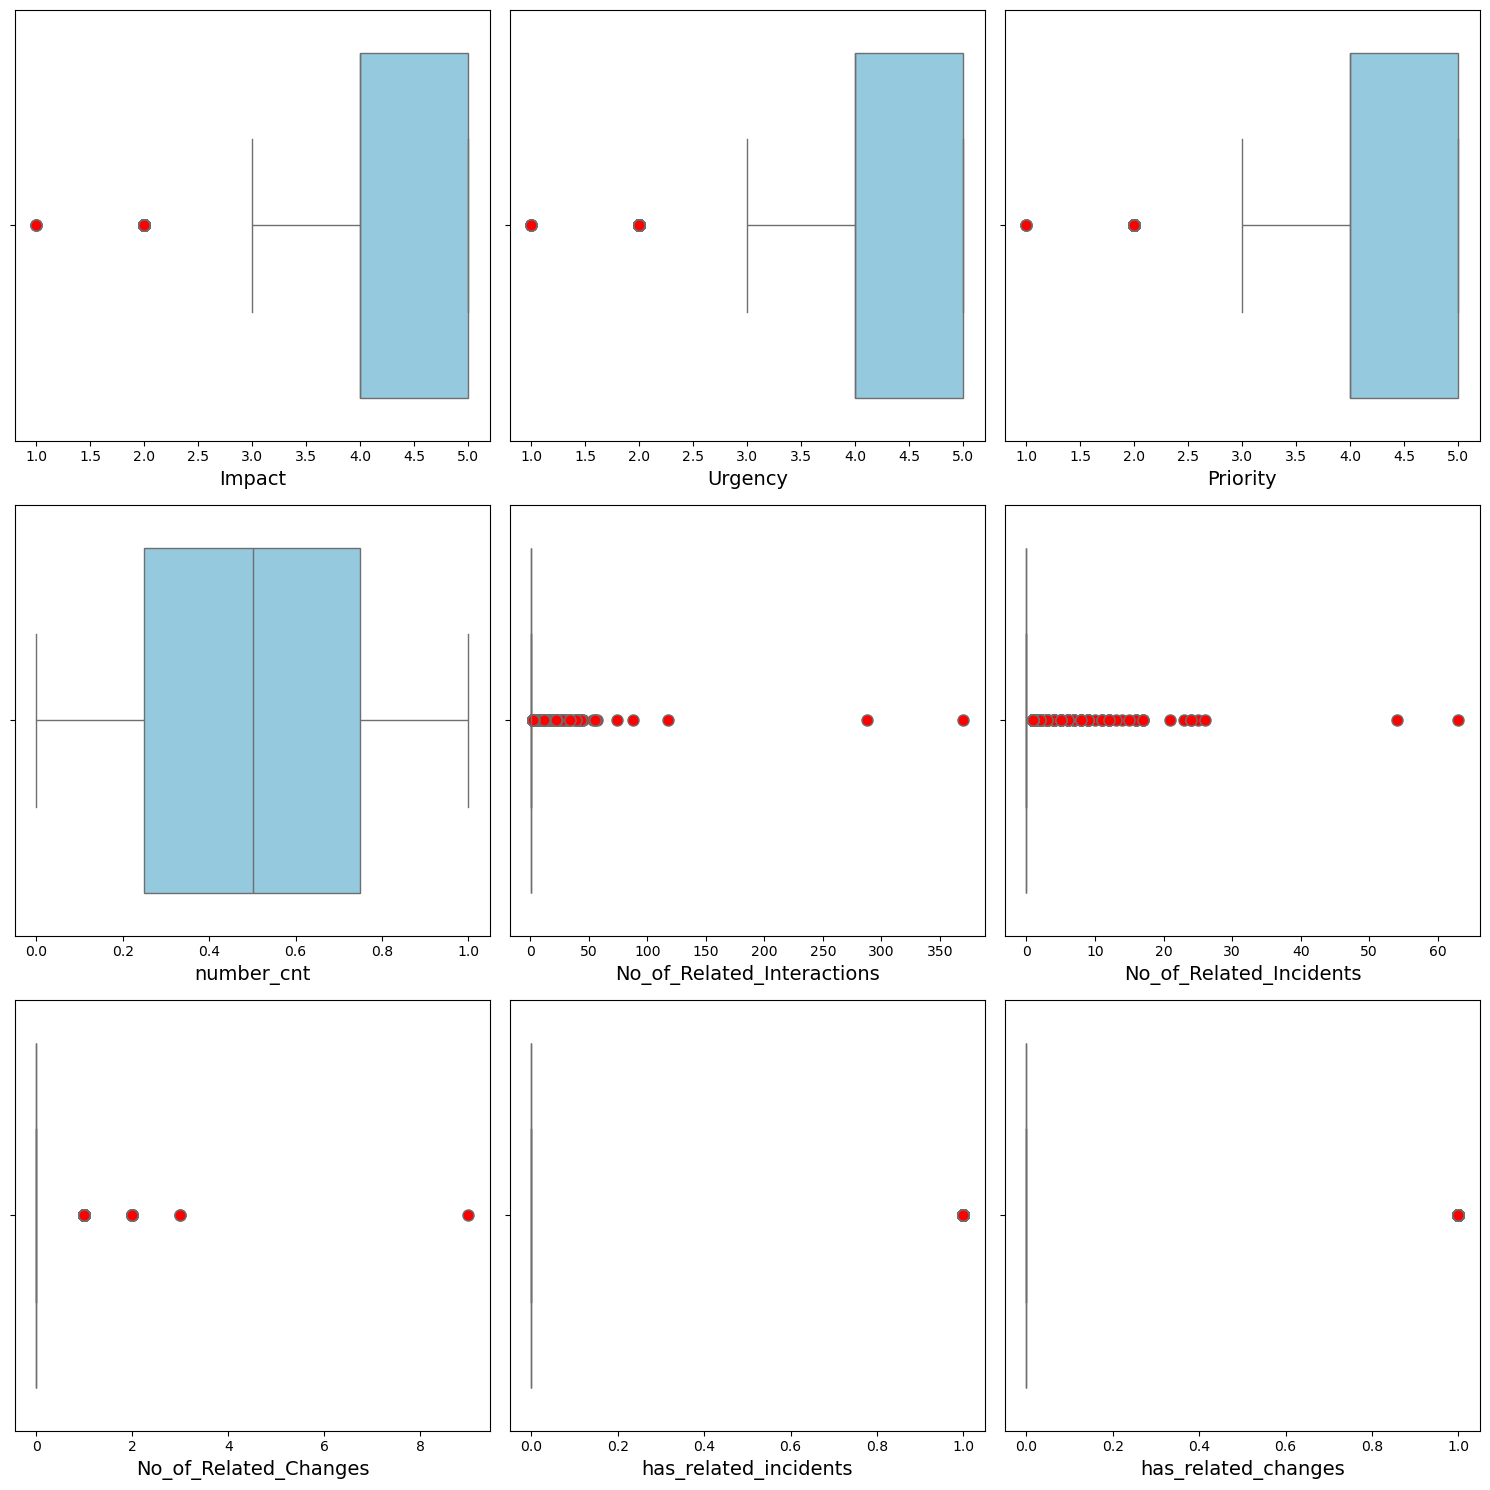

In [53]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Impact', 'Urgency', 'Priority', 'number_cnt','No_of_Related_Interactions',
  'No_of_Related_Incidents', 'No_of_Related_Changes',
       'has_related_incidents', 'has_related_changes']  # your column list
n = len(cols)
rows = math.ceil(n / 3)

plt.figure(figsize=(15, 5*rows))

plotnumber = 1
for column in cols:
    plt.subplot(rows, 3, plotnumber)
    sns.boxplot(x=df_freq[column], color='skyblue',
                flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 8})
    plt.xlabel(column, fontsize=14)
    plotnumber += 1

plt.tight_layout()
plt.show()



--- No_of_Related_Interactions ---
Original range: 1.00 to 370.00
IQR: 0.00
Lower bound: 1.00
Upper bound: 1.00
Number of outliers below lower bound: 0
Number of outliers above upper bound: 3352

--- No_of_Related_Incidents ---
Original range: 0.00 to 63.00
IQR: 0.00
Lower bound: 0.00
Upper bound: 0.00
Number of outliers below lower bound: 0
Number of outliers above upper bound: 1166

--- No_of_Related_Changes ---
Original range: 0.00 to 9.00
IQR: 0.00
Lower bound: 0.00
Upper bound: 0.00
Number of outliers below lower bound: 0
Number of outliers above upper bound: 525

--- has_related_incidents ---
Original range: 0.00 to 1.00
IQR: 0.00
Lower bound: 0.00
Upper bound: 0.00
Number of outliers below lower bound: 0
Number of outliers above upper bound: 1166

--- has_related_changes ---
Original range: 0.00 to 1.00
IQR: 0.00
Lower bound: 0.00
Upper bound: 0.00
Number of outliers below lower bound: 0
Number of outliers above upper bound: 525


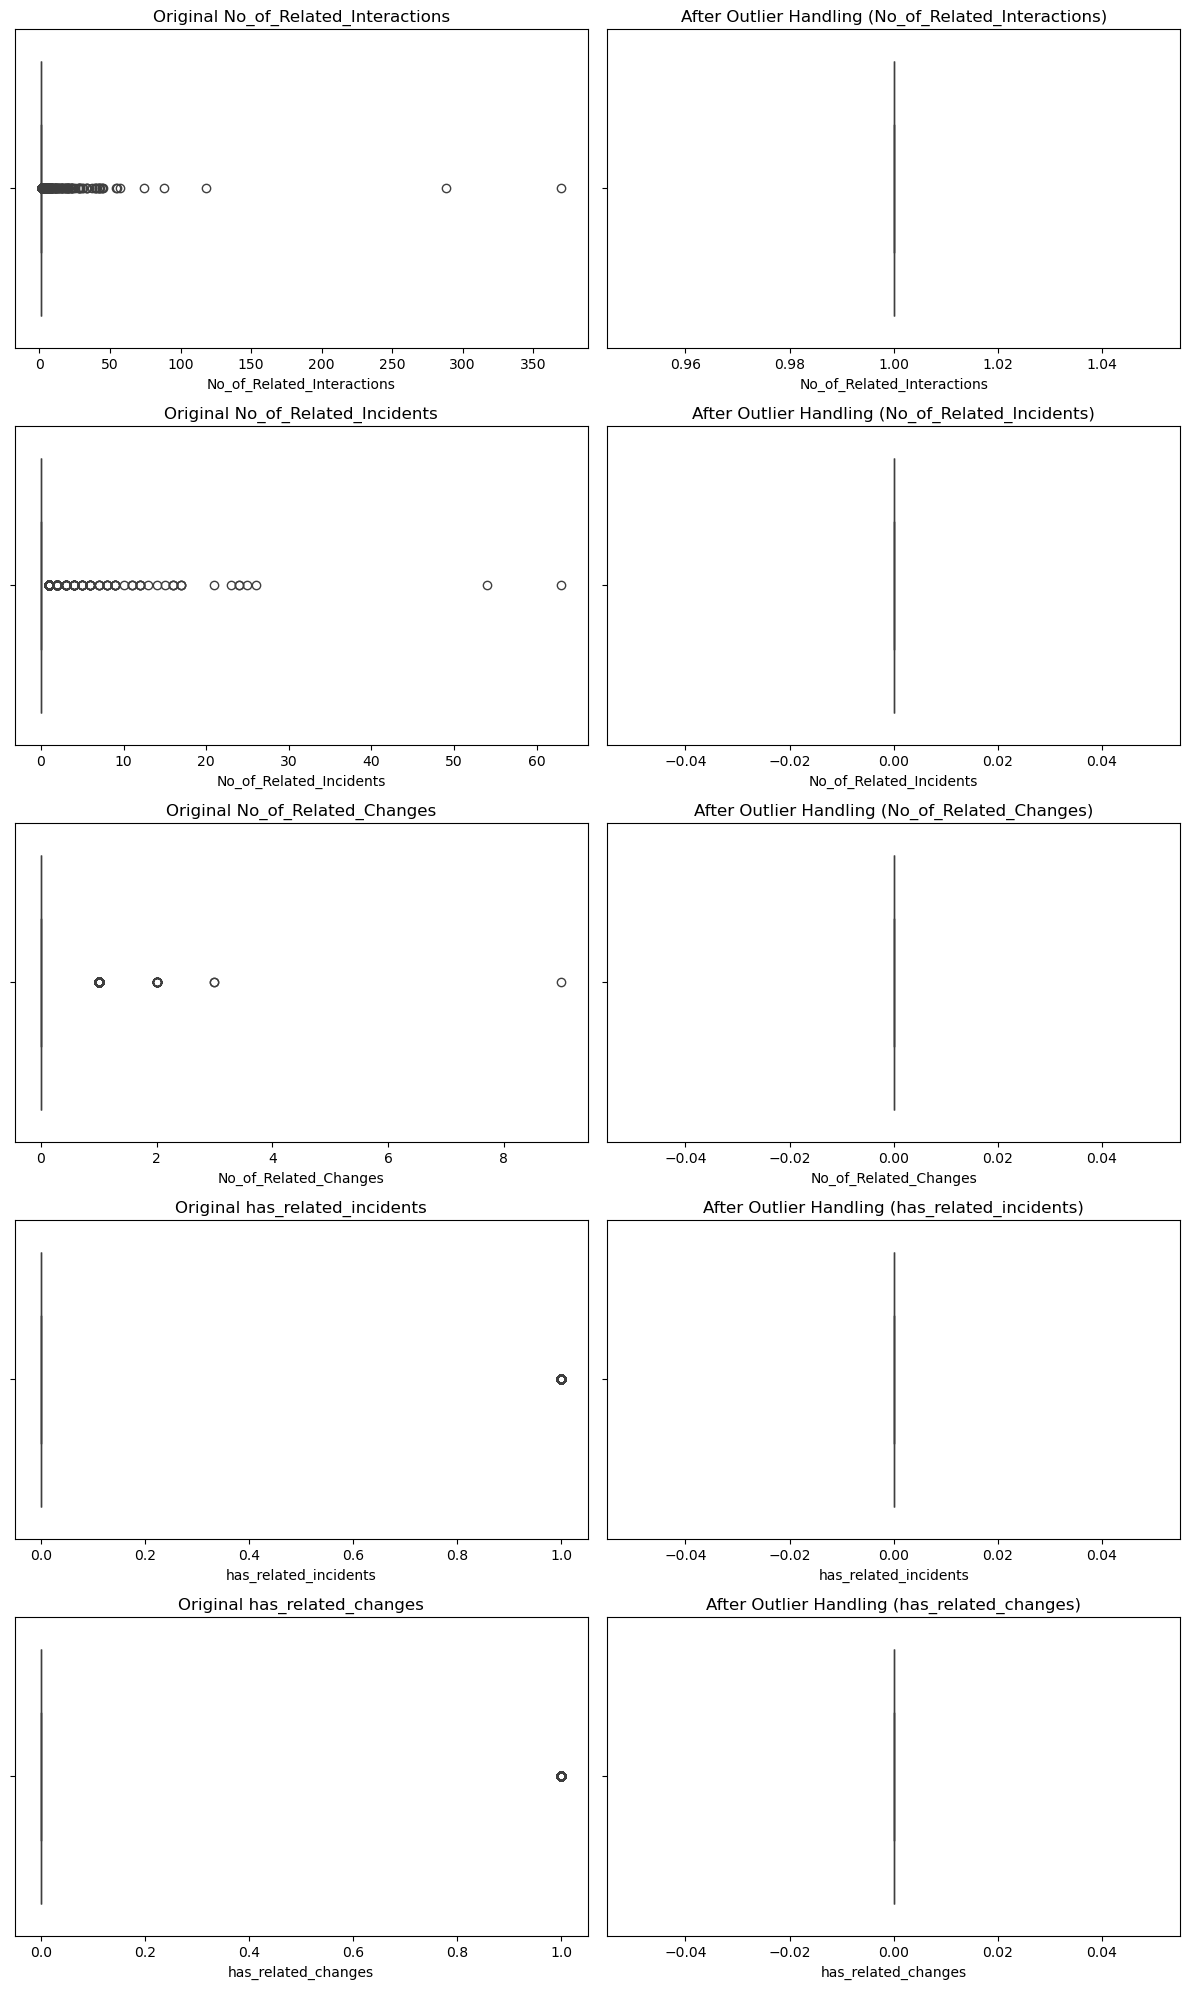

In [54]:
def handle_outliers_and_plot(df, columns_to_process):
    """
    Handle outliers using IQR method and create before/after boxplot comparisons

    Parameters:
    df (pd.DataFrame): Input DataFrame
    columns_to_process (list): List of column names to process
    """

    # Create a copy of the DataFrame to avoid modifying the original
    df_capped = df.copy()

    # Set up the figure for plotting
    n_cols = 2  # Before and after columns
    n_rows = len(columns_to_process)
    plt.figure(figsize=(12, 4*n_rows))

    for i, column in enumerate(columns_to_process, 1):
        # Skip if column doesn't exist
        if column not in df.columns:
            print(f"Column '{column}' not found in DataFrame. Skipping...")
            continue

        # Calculate IQR and bounds
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        min_limit = Q1 - 1.5 * IQR
        max_limit = Q3 + 1.5 * IQR

        # Print statistics
        print(f"\n--- {column} ---")
        print(f"Original range: {df[column].min():.2f} to {df[column].max():.2f}")
        print(f"IQR: {IQR:.2f}")
        print(f"Lower bound: {min_limit:.2f}")
        print(f"Upper bound: {max_limit:.2f}")
        print(f"Number of outliers below lower bound: {len(df[df[column] < min_limit])}")
        print(f"Number of outliers above upper bound: {len(df[df[column] > max_limit])}")

        # Cap outliers to median
        median_val = df[column].median()
        df_capped.loc[df_capped[column] < min_limit, column] = median_val
        df_capped.loc[df_capped[column] > max_limit, column] = median_val

        # Plot before/after comparison
        plt.subplot(n_rows, n_cols, (i-1)*2 + 1)
        sns.boxplot(x=df[column])
        plt.title(f'Original {column}')

        plt.subplot(n_rows, n_cols, (i-1)*2 + 2)
        sns.boxplot(x=df_capped[column])
        plt.title(f'After Outlier Handling ({column})')

    plt.tight_layout()
    plt.show()

    return df_capped

# Example usage:
# Assuming you have a DataFrame called 'df' and want to process these columns:
columns_to_process = ['No_of_Related_Interactions','No_of_Related_Incidents', 'No_of_Related_Changes',
       'has_related_incidents', 'has_related_changes']

# Process the data and get the cleaned DataFrame
df_cleaned = handle_outliers_and_plot(df_freq, columns_to_process)

In [55]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45225 entries, 0 to 46605
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   CI_Name                     45225 non-null  object        
 1   CI_Cat                      45225 non-null  float64       
 2   CI_Subcat                   45225 non-null  float64       
 3   WBS                         45225 non-null  object        
 4   Incident_ID                 45225 non-null  object        
 5   Impact                      45225 non-null  int32         
 6   Urgency                     45225 non-null  int64         
 7   Priority                    45225 non-null  int32         
 8   number_cnt                  45225 non-null  float64       
 9   Category                    45225 non-null  float64       
 10  KB_number                   45225 non-null  object        
 11  No_of_Reassignments         45225 non-null  float64       


# **Feature Engineering**

## Drop Columns

In [56]:
df_cleaned.drop(
    columns=['CI_Name','WBS','Incident_ID','KB_number','Related_Interaction'],
    inplace=True
)

In [57]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45225 entries, 0 to 46605
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   CI_Cat                      45225 non-null  float64       
 1   CI_Subcat                   45225 non-null  float64       
 2   Impact                      45225 non-null  int32         
 3   Urgency                     45225 non-null  int64         
 4   Priority                    45225 non-null  int32         
 5   number_cnt                  45225 non-null  float64       
 6   Category                    45225 non-null  float64       
 7   No_of_Reassignments         45225 non-null  float64       
 8   Open_Time                   45225 non-null  datetime64[ns]
 9   Resolved_Time               45225 non-null  datetime64[ns]
 10  Close_Time                  45225 non-null  datetime64[ns]
 11  Handle_Time_hrs             45225 non-null  int64         


# Scaling the data

In [58]:
df_cleaned.describe()

,CI_Cat,CI_Subcat,Impact,Urgency,Priority,number_cnt,Category,No_of_Reassignments,Open_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes,has_related_incidents,has_related_changes,Department
count,45225.000000,45225.000000,45225.000000,45225.000000,45225.000000,45225.000000,45225.000000,45225.00000,45225,45225,45225,4.522500e+04,45225.000000,45225.0,45225.0,45225.0,45225.0,45225.0,45225.000000
mean,0.535821,0.284316,4.223615,4.225119,4.215788,0.499885,0.686141,1.14105,2013-12-24 09:02:53.090547200,2013-12-26 17:22:46.522056448,2013-12-29 13:05:40.371475968,2.415853e+09,0.232928,1.0,0.0,0.0,0.0,0.0,0.435003
min,0.000044,0.000022,1.000000,1.000000,1.000000,0.000023,0.000243,0.00000,2012-02-05 13:32:00,2013-10-01 06:45:00,2013-10-01 06:45:00,0.000000e+00,0.000022,1.0,0.0,0.0,0.0,0.0,0.000000
25%,0.170702,0.082012,4.000000,4.000000,4.000000,0.248770,0.805152,0.00000,2013-11-07 12:48:00,2013-11-07 10:51:00,2013-11-12 17:59:00,4.508333e+08,0.072902,1.0,0.0,0.0,0.0,0.0,0.000000
50%,0.707219,0.335478,4.000000,4.000000,4.000000,0.500859,0.805152,0.00000,2013-12-23 11:15:00,2013-12-24 10:57:00,2013-12-31 09:13:00,1.604389e+09,0.281083,1.0,0.0,0.0,0.0,0.0,0.000000
75%,0.707219,0.401813,5.000000,5.000000,5.000000,0.749246,0.805152,2.00000,2014-02-07 14:16:00,2014-02-11 13:23:00,2014-02-12 13:49:00,3.612139e+09,0.366147,1.0,0.0,0.0,0.0,0.0,0.000000
max,0.707219,0.401813,5.000000,5.000000,5.000000,0.999997,0.805152,46.00000,2014-03-31 17:24:00,2014-03-31 22:47:00,2014-03-31 22:47:00,9.999722e+09,0.366147,1.0,0.0,0.0,0.0,0.0,13.000000
std,0.268477,0.149853,0.705472,0.705558,0.705622,0.288668,0.241946,2.28447,NaN,NaN,NaN,2.458651e+09,0.135289,0.0,0.0,0.0,0.0,0.0,1.459483


In [59]:

from sklearn.preprocessing import MinMaxScaler

num_cols = ['No_of_Reassignments', 'Handle_Time_hrs', 'Impact', 'Urgency']

# Scale numeric columns
scale = MinMaxScaler()
df_cleaned[num_cols] = scale.fit_transform(df_cleaned[num_cols])


In [60]:
df_cleaned['Priority'].value_counts()

Priority
4    22717
5    16485
3     5323
2      697
1        3
Name: count, dtype: int64

In [61]:
df_cleaned.head()

,CI_Cat,CI_Subcat,Impact,Urgency,Priority,number_cnt,Category,No_of_Reassignments,Open_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes,has_related_incidents,has_related_changes,Department
0,0.170702,0.335478,0.75,0.75,4,0.601292,0.805152,0.565217,2012-02-05 13:32:00,2013-11-04 13:50:00,2013-11-04 13:51:00,0.387180,0.366147,1.0,0.0,0.0,0,0,0
1,0.707219,0.335478,0.50,0.50,3,0.415050,0.805152,0.717391,2012-03-12 15:44:00,2013-12-02 12:36:00,2013-12-02 12:36:00,0.435491,0.281083,1.0,0.0,0.0,0,0,0
3,0.707219,0.335478,0.75,0.75,4,0.642927,0.805152,0.282609,2012-07-17 11:49:00,2013-11-14 09:31:00,2013-11-14 09:31:00,0.432195,0.033190,1.0,0.0,0.0,0,0,0
4,0.707219,0.335478,0.75,0.75,4,0.345258,0.805152,0.043478,2012-08-10 11:01:00,2013-11-08 13:55:00,2013-11-08 13:55:00,0.338400,0.366147,1.0,0.0,0.0,0,0,0
5,0.707219,0.335478,0.75,0.75,4,0.006676,0.805152,0.086957,2012-08-10 11:27:00,2013-11-08 13:54:00,2013-11-08 13:54:00,0.338353,0.366147,1.0,0.0,0.0,0,0,0


In [62]:
df_cleaned.columns

Index(['CI_Cat', 'CI_Subcat', 'Impact', 'Urgency', 'Priority', 'number_cnt',
       'Category', 'No_of_Reassignments', 'Open_Time', 'Resolved_Time',
       'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'No_of_Related_Incidents',
       'No_of_Related_Changes', 'has_related_incidents', 'has_related_changes',
       'Department'],
      dtype='object')

In [63]:
df_cleaned.to_csv("Cleaned_Data.csv")

# **Task 1 :**
##### Predicting High Priority Tickets: To predict priority 1 & 2 tickets, sothat they can take preventive measures or fix the problem before it surfaces.

### What is Predicting High Priority Tickets?

In ITSM, Priority tells how urgently an incident must be fixed.

P1 / P2 → Critical & High (business impact, outages)

P3 / P4 → Medium & Low

🎯 Goal

Use machine learning to predict whether a newly created ticket will become P1 or P2, before humans assign it.

👉 This allows:

Faster escalation

Preventive action

Reduced MTTR (Mean Time To Resolution)

### How do we frame this as a Machine Learning problem?
ML Problem Type

✅ Binary Classification
| Label | Meaning                  |
| ----- | ------------------------ |
| 1     | High Priority (P1, P2)   |
| 0     | Normal Priority (P3, P4) |


In [64]:
df=pd.read_csv("Cleaned_Data.csv", usecols=['CI_Cat','CI_Subcat','Impact', 'Urgency', 'Priority', 'number_cnt','Open_Time',
       'Category', 'Handle_Time_hrs','No_of_Reassignments','No_of_Related_Incidents','No_of_Related_Changes', 'has_related_incidents','has_related_changes'])
df.head()

,CI_Cat,CI_Subcat,Impact,Urgency,Priority,number_cnt,Category,No_of_Reassignments,Open_Time,Handle_Time_hrs,No_of_Related_Incidents,No_of_Related_Changes,has_related_incidents,has_related_changes
0,0.170702,0.335478,0.75,0.75,4,0.601292,0.805152,0.565217,2012-02-05 13:32:00,0.387180,0.0,0.0,0,0
1,0.707219,0.335478,0.50,0.50,3,0.415050,0.805152,0.717391,2012-03-12 15:44:00,0.435491,0.0,0.0,0,0
2,0.707219,0.335478,0.75,0.75,4,0.642927,0.805152,0.282609,2012-07-17 11:49:00,0.432195,0.0,0.0,0,0
3,0.707219,0.335478,0.75,0.75,4,0.345258,0.805152,0.043478,2012-08-10 11:01:00,0.338400,0.0,0.0,0,0
4,0.707219,0.335478,0.75,0.75,4,0.006676,0.805152,0.086957,2012-08-10 11:27:00,0.338353,0.0,0.0,0,0


## Feature Engineering

In [65]:
# Target Column.
df['High_Priority'] = df['Priority'].apply(
    lambda x: 1 if x in [2, 1] else 0
)

In [66]:
df['High_Priority'].value_counts()

High_Priority
0    44525
1      700
Name: count, dtype: int64

In [67]:
df.head()

,CI_Cat,CI_Subcat,Impact,Urgency,Priority,number_cnt,Category,No_of_Reassignments,Open_Time,Handle_Time_hrs,No_of_Related_Incidents,No_of_Related_Changes,has_related_incidents,has_related_changes,High_Priority
0,0.170702,0.335478,0.75,0.75,4,0.601292,0.805152,0.565217,2012-02-05 13:32:00,0.387180,0.0,0.0,0,0,0
1,0.707219,0.335478,0.50,0.50,3,0.415050,0.805152,0.717391,2012-03-12 15:44:00,0.435491,0.0,0.0,0,0,0
2,0.707219,0.335478,0.75,0.75,4,0.642927,0.805152,0.282609,2012-07-17 11:49:00,0.432195,0.0,0.0,0,0,0
3,0.707219,0.335478,0.75,0.75,4,0.345258,0.805152,0.043478,2012-08-10 11:01:00,0.338400,0.0,0.0,0,0,0
4,0.707219,0.335478,0.75,0.75,4,0.006676,0.805152,0.086957,2012-08-10 11:27:00,0.338353,0.0,0.0,0,0,0


In [68]:
df.drop(['Priority'],axis=1, inplace=True)

In [69]:
df['Open_Time'] = pd.to_datetime(df['Open_Time'], errors='coerce')
df['Open_Time'].dtype

dtype('<M8[ns]')

In [70]:
df['open_hour'] = df['Open_Time'].dt.hour
df['is_peak_hour'] = df['open_hour'].between(10,18).astype(int)

In [71]:
df.head()

,CI_Cat,CI_Subcat,Impact,Urgency,number_cnt,Category,No_of_Reassignments,Open_Time,Handle_Time_hrs,No_of_Related_Incidents,No_of_Related_Changes,has_related_incidents,has_related_changes,High_Priority,open_hour,is_peak_hour
0,0.170702,0.335478,0.75,0.75,0.601292,0.805152,0.565217,2012-02-05 13:32:00,0.387180,0.0,0.0,0,0,0,13,1
1,0.707219,0.335478,0.50,0.50,0.415050,0.805152,0.717391,2012-03-12 15:44:00,0.435491,0.0,0.0,0,0,0,15,1
2,0.707219,0.335478,0.75,0.75,0.642927,0.805152,0.282609,2012-07-17 11:49:00,0.432195,0.0,0.0,0,0,0,11,1
3,0.707219,0.335478,0.75,0.75,0.345258,0.805152,0.043478,2012-08-10 11:01:00,0.338400,0.0,0.0,0,0,0,11,1
4,0.707219,0.335478,0.75,0.75,0.006676,0.805152,0.086957,2012-08-10 11:27:00,0.338353,0.0,0.0,0,0,0,11,1


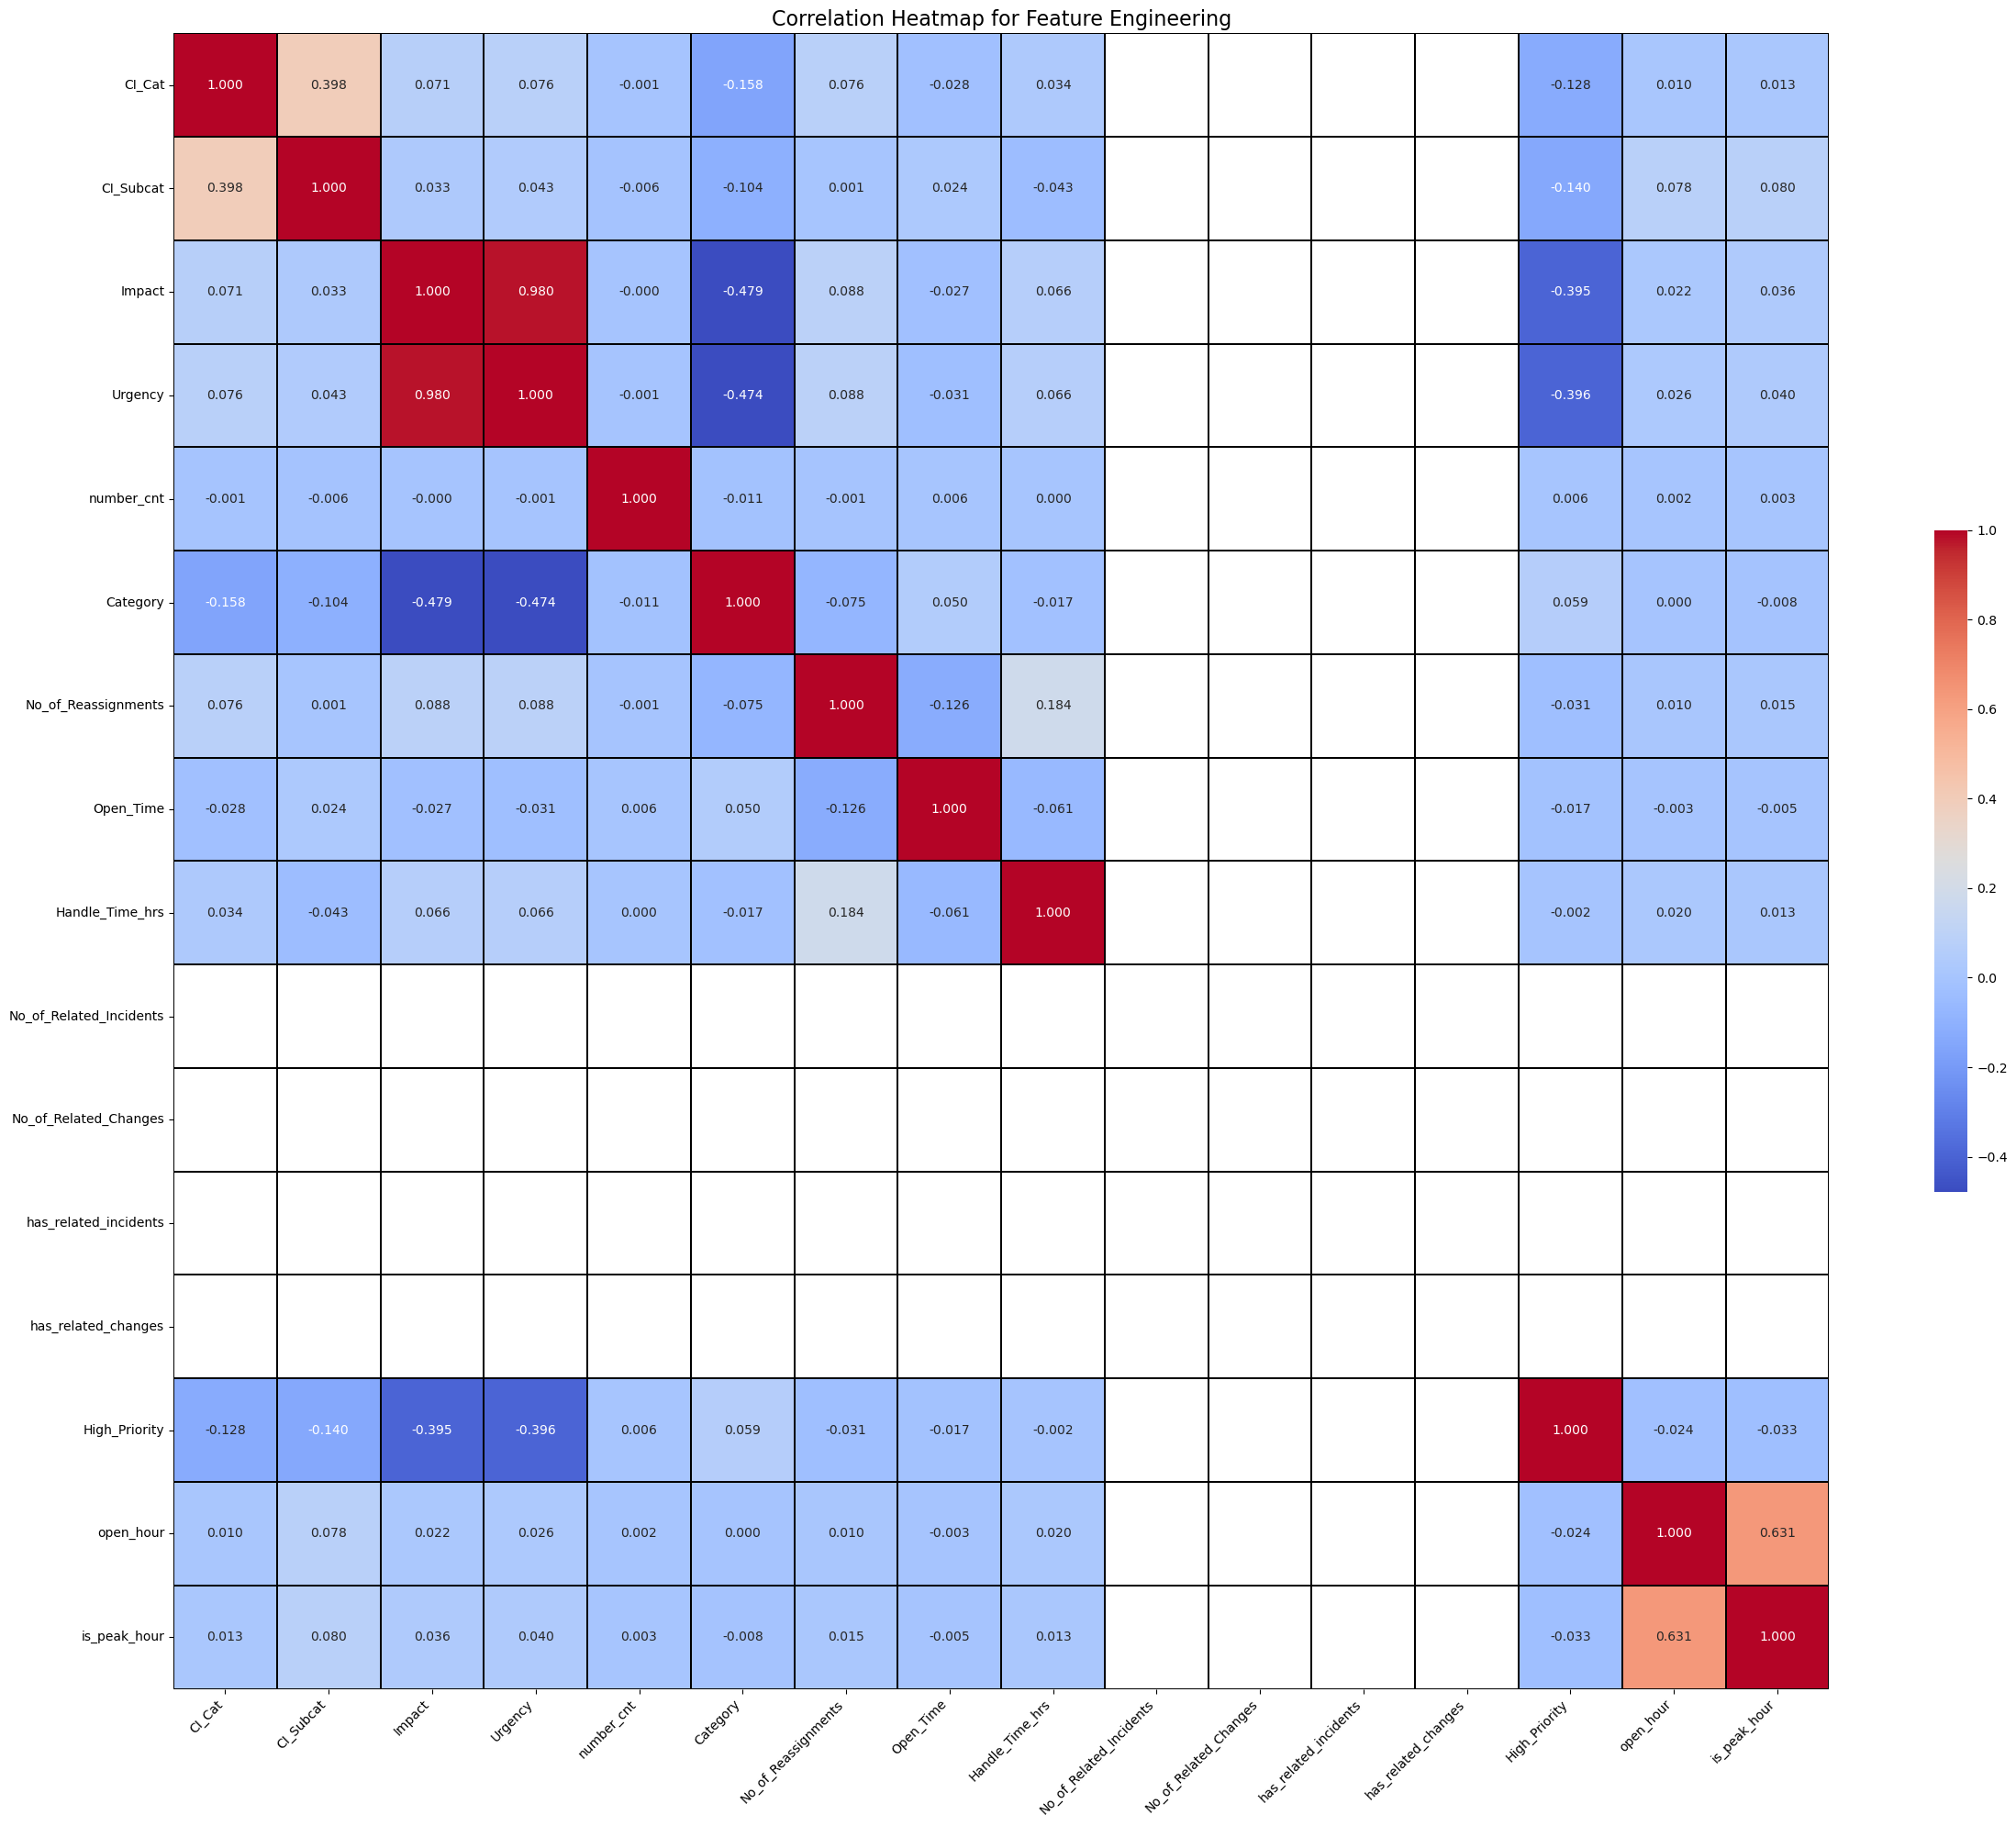

In [72]:
corr=df.corr()
plt.figure(figsize=(25,20))
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    square=True,
    linewidths=0.2,        # Lines between boxes
    linecolor='black',     
    cbar_kws={'shrink': 0.4}  # Smaller color bar
)

plt.title("Correlation Heatmap for Feature Engineering", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [73]:
df.columns

Index(['CI_Cat', 'CI_Subcat', 'Impact', 'Urgency', 'number_cnt', 'Category',
       'No_of_Reassignments', 'Open_Time', 'Handle_Time_hrs',
       'No_of_Related_Incidents', 'No_of_Related_Changes',
       'has_related_incidents', 'has_related_changes', 'High_Priority',
       'open_hour', 'is_peak_hour'],
      dtype='object')

In [74]:
df.drop(columns=['number_cnt', 'Handle_Time_hrs','No_of_Related_Incidents', 'No_of_Related_Changes', 'has_related_incidents',
 'has_related_changes','Open_Time','number_cnt','No_of_Reassignments','Open_Time', 'Handle_Time_hrs','open_hour', 'is_peak_hour'], inplace=True)


In [75]:
X =df.drop(['High_Priority'],axis=1)
y = df['High_Priority']

In [76]:
X.columns

Index(['CI_Cat', 'CI_Subcat', 'Impact', 'Urgency', 'Category'], dtype='object')

In [77]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

                     Train Accuracy  Test Accuracy  CV Score
Decision Tree              1.000000       1.000000  1.000000
Random Forest              1.000000       1.000000  1.000000
Gradient Boosting          1.000000       1.000000  1.000000
XGBoost                    1.000000       1.000000       NaN
Logistic Regression        0.999853       0.999912  0.999867
SVM                        0.999941       0.999912  0.999956
KNN                        0.999941       0.999912  0.999779
Naive Bayes                0.999528       0.999823  0.999602


<Figure size 1200x600 with 0 Axes>

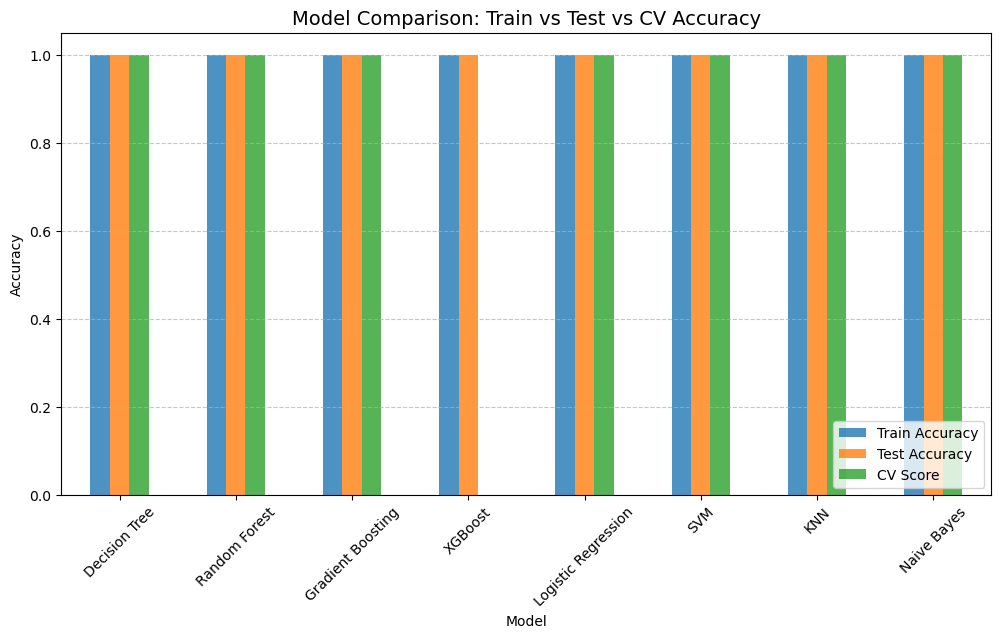


========== DETAILED CLASSIFICATION REPORTS & CONFUSION MATRICES ==========


Model: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11132
           1       1.00      0.99      1.00       175

    accuracy                           1.00     11307
   macro avg       1.00      1.00      1.00     11307
weighted avg       1.00      1.00      1.00     11307

Confusion Matrix:
 [[11132     0]
 [    1   174]]


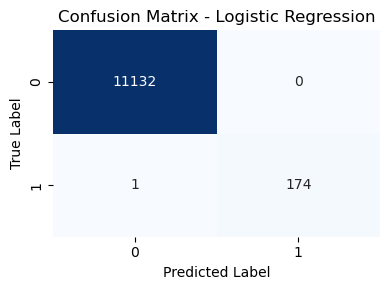

------------------------------------------------------------

Model: Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11132
           1       1.00      1.00      1.00       175

    accuracy                           1.00     11307
   macro avg       1.00      1.00      1.00     11307
weighted avg       1.00      1.00      1.00     11307

Confusion Matrix:
 [[11132     0]
 [    0   175]]


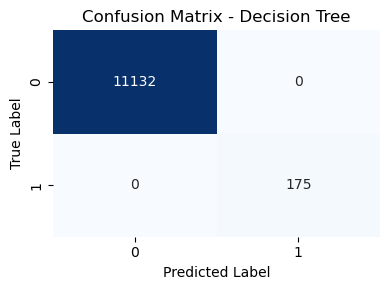

------------------------------------------------------------

Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11132
           1       1.00      1.00      1.00       175

    accuracy                           1.00     11307
   macro avg       1.00      1.00      1.00     11307
weighted avg       1.00      1.00      1.00     11307

Confusion Matrix:
 [[11132     0]
 [    0   175]]


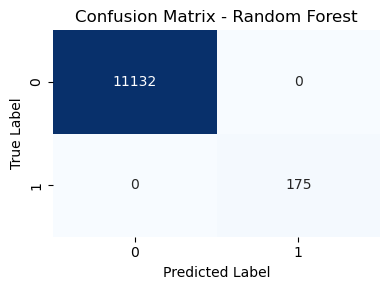

------------------------------------------------------------

Model: Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11132
           1       1.00      1.00      1.00       175

    accuracy                           1.00     11307
   macro avg       1.00      1.00      1.00     11307
weighted avg       1.00      1.00      1.00     11307

Confusion Matrix:
 [[11132     0]
 [    0   175]]


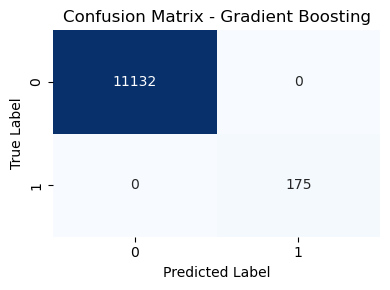

------------------------------------------------------------

Model: SVM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11132
           1       1.00      0.99      1.00       175

    accuracy                           1.00     11307
   macro avg       1.00      1.00      1.00     11307
weighted avg       1.00      1.00      1.00     11307

Confusion Matrix:
 [[11132     0]
 [    1   174]]


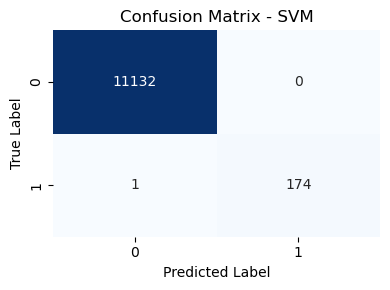

------------------------------------------------------------

Model: KNN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11132
           1       1.00      0.99      1.00       175

    accuracy                           1.00     11307
   macro avg       1.00      1.00      1.00     11307
weighted avg       1.00      1.00      1.00     11307

Confusion Matrix:
 [[11132     0]
 [    1   174]]


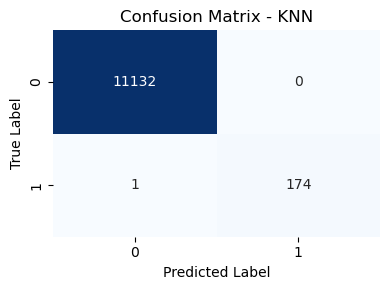

------------------------------------------------------------

Model: Naive Bayes
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11132
           1       1.00      0.99      0.99       175

    accuracy                           1.00     11307
   macro avg       1.00      0.99      1.00     11307
weighted avg       1.00      1.00      1.00     11307

Confusion Matrix:
 [[11132     0]
 [    2   173]]


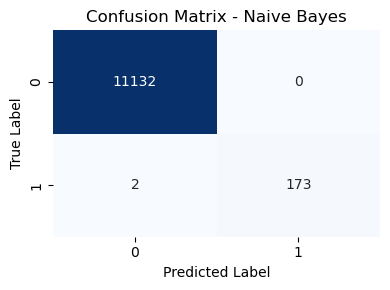

------------------------------------------------------------

Model: XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11132
           1       1.00      1.00      1.00       175

    accuracy                           1.00     11307
   macro avg       1.00      1.00      1.00     11307
weighted avg       1.00      1.00      1.00     11307

Confusion Matrix:
 [[11132     0]
 [    0   175]]


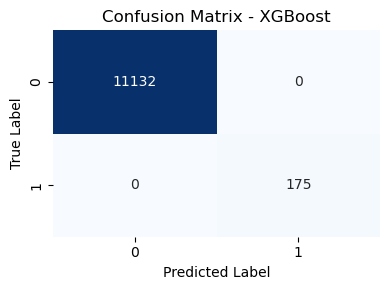

------------------------------------------------------------


In [78]:
# ---------------------------------------
# MULTIPLE CLASSIFICATION MODELS TESTING
# ---------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split dataset
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(eval_metric='mlogloss')
}

# Evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    if name == "XGBoost":
        cv_score = np.nan   # or compute manually
    else:
        cv_score = cross_val_score(model, X, y, cv=5).mean()

    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "CV Score": cv_score
    }

# Convert to DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)
print(results_df)

# ---------------------------------------
# 📊 Visualization
# ---------------------------------------

plt.figure(figsize=(12,6))
'''results_df[['Train Accuracy','Test Accuracy','CV Score']].plot(
    kind='bar', figsize=(12,6), rot=45, alpha=0.8
)'''
results_df[['Train Accuracy','Test Accuracy','CV Score']].plot(
    kind='bar', figsize=(12,6), rot=45, alpha=0.8
)
plt.title("Model Comparison: Train vs Test vs CV Accuracy", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ---------------------------------------------------------
# CLASSIFICATION REPORTS + CONFUSION MATRIX
# ---------------------------------------------------------
print("\n========== DETAILED CLASSIFICATION REPORTS & CONFUSION MATRICES ==========\n")

for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)
    
    # Plot Confusion Matrix as Heatmap
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    print("-" * 60)


In [79]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12, random_state=42)

In [80]:
from sklearn.metrics import classification_report, confusion_matrix
report=classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11132
           1       1.00      1.00      1.00       175

    accuracy                           1.00     11307
   macro avg       1.00      1.00      1.00     11307
weighted avg       1.00      1.00      1.00     11307



In [81]:
y_pred_rf=rf.predict(X_test)

In [82]:
matrix=confusion_matrix(y_test, y_pred_rf)
print(matrix)

[[11132     0]
 [    0   175]]


In [83]:
import xgboost as xgb
model=xgb.XGBClassifier(eval_metric='mlogloss')
model.fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [84]:
y_pred_xgb=model.predict(X_test)

In [85]:
from sklearn.metrics import classification_report, confusion_matrix
report=classification_report(y_test, y_pred_xgb)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11132
           1       1.00      1.00      1.00       175

    accuracy                           1.00     11307
   macro avg       1.00      1.00      1.00     11307
weighted avg       1.00      1.00      1.00     11307



In [86]:
matrix=confusion_matrix(y_test, y_pred_xgb)
print(matrix)

[[11132     0]
 [    0   175]]


In [87]:
import joblib
joblib.dump(model, "Priority_Classifer_1.pkl")

['Priority_Classifer_1.pkl']

## 6️⃣ Real-World Deployment Flow

Ticket created

Feature extracted instantly

ML predicts → High / Normal

Auto-escalate P1/P2

Alert SME team



# **Task 2:**
## Incident Volume Forecasting for ITSM Resource & Technology Planning

1️⃣ What is This Project?

This project predicts how many IT incidents will occur in the future:

* Quarterly
* Annually
* Across different fields like:
    * Category
    * CI_Cat
    * Priority
    * Impact
    * Urgency

The forecast helps the organization prepare in advance with:
* Right number of SMEs (support engineers)
* Better infrastructure & tools
* Reduced SLA breaches
* Smarter capacity planning

### 2️⃣ Why This Project is Needed (Business Problem)
❌ Without Forecasting

* Sudden incident spikes
* Understaffed teams
* SLA violations
* Firefighting mode

✅ With Forecasting

* Proactive hiring
* Planned upgrades
* Stable operations
* Lower MTTR

📌 This aligns directly with ITIL Demand & Capacity Management


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [89]:
df=pd.read_csv("Basic_Cleand_data.csv")

## Data Preparation (Most Critical Step)

In [90]:
df.head()

,Unnamed: 0,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Impact,Urgency,Priority,number_cnt,...,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,has_related_incidents,has_related_changes,Department
0,0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,4,4,4,0.601292,...,2013-11-04 13:51:00,3871691111,Other,1.0,SD0000007,2.0,0.0,1,0,0
1,1,WBA000124,application,Web Based Application,WBS000088,IM0000005,3,3,3,0.415050,...,2013-12-02 12:36:00,4354786389,Software,1.0,SD0000011,1.0,0.0,1,0,0
2,3,WBA000124,application,Web Based Application,WBS000088,IM0000011,4,4,4,0.642927,...,2013-11-14 09:31:00,4321833333,Operator error,1.0,SD0000025,0.0,0.0,0,0,0
3,4,WBA000124,application,Web Based Application,WBS000088,IM0000012,4,4,4,0.345258,...,2013-11-08 13:55:00,3383903333,Other,1.0,SD0000029,0.0,0.0,0,0,0
4,5,WBA000124,application,Web Based Application,WBS000088,IM0000013,4,4,4,0.006676,...,2013-11-08 13:54:00,3383436944,Other,1.0,SD0000031,0.0,0.0,0,0,0


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45225 entries, 0 to 45224
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  45225 non-null  int64  
 1   CI_Name                     45225 non-null  object 
 2   CI_Cat                      45225 non-null  object 
 3   CI_Subcat                   45225 non-null  object 
 4   WBS                         45225 non-null  object 
 5   Incident_ID                 45225 non-null  object 
 6   Impact                      45225 non-null  int64  
 7   Urgency                     45225 non-null  int64  
 8   Priority                    45225 non-null  int64  
 9   number_cnt                  45225 non-null  float64
 10  Category                    45225 non-null  object 
 11  KB_number                   45225 non-null  object 
 12  No_of_Reassignments         45225 non-null  float64
 13  Open_Time                   452

In [92]:
df.columns

Index(['Unnamed: 0', 'CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'No_of_Reassignments', 'Open_Time', 'Resolved_Time', 'Close_Time',
       'Handle_Time_hrs', 'Closure_Code', 'No_of_Related_Interactions',
       'Related_Interaction', 'No_of_Related_Incidents',
       'No_of_Related_Changes', 'has_related_incidents', 'has_related_changes',
       'Department'],
      dtype='object')

In [93]:
df.drop(columns=['Unnamed: 0', 'CI_Name','WBS', 'Incident_ID', 'number_cnt', 'KB_number', 'Resolved_Time', 'Close_Time',
                 'Closure_Code', 'Related_Interaction',], inplace=True)

In [94]:
df.head()

,CI_Cat,CI_Subcat,Impact,Urgency,Priority,Category,No_of_Reassignments,Open_Time,Handle_Time_hrs,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes,has_related_incidents,has_related_changes,Department
0,subapplication,Web Based Application,4,4,4,incident,26.0,2012-02-05 13:32:00,3871691111,1.0,2.0,0.0,1,0,0
1,application,Web Based Application,3,3,3,incident,33.0,2012-03-12 15:44:00,4354786389,1.0,1.0,0.0,1,0,0
2,application,Web Based Application,4,4,4,incident,13.0,2012-07-17 11:49:00,4321833333,1.0,0.0,0.0,0,0,0
3,application,Web Based Application,4,4,4,incident,2.0,2012-08-10 11:01:00,3383903333,1.0,0.0,0.0,0,0,0
4,application,Web Based Application,4,4,4,incident,4.0,2012-08-10 11:27:00,3383436944,1.0,0.0,0.0,0,0,0


In [95]:
for col in df.columns:
    print(f"Column: {col}")
    print("Unique values:")
    print(df[col].unique())
    print("Value counts:")
    print(df[col].value_counts())
    print('-' * 60)

Column: CI_Cat
Unique values:
['subapplication' 'application' 'computer' 'displaydevice' 'software'
 'storage' 'database' 'hardware' 'officeelectronics' 'networkcomponents'
 'applicationcomponent' 'Phone']
Value counts:
CI_Cat
application             31984
subapplication           7720
computer                 3544
storage                   653
hardware                  406
software                  294
displaydevice             212
database                  168
officeelectronics         139
networkcomponents          99
applicationcomponent        4
Phone                       2
Name: count, dtype: int64
------------------------------------------------------------
Column: CI_Subcat
Unique values:
['Web Based Application' 'Server Based Application' 'Desktop Application'
 'SAP' 'Client Based Application' 'Citrix' 'Standard Application'
 'Windows Server' 'Laptop' 'Linux Server' 'Monitor' 'Automation Software'
 'SAN' 'Banking Device' 'Desktop' 'Database' 'Oracle Server' 'Keyboard'
 'Print

In [96]:
with pd.option_context('display.max_rows', None):
    print(df['CI_Subcat'].value_counts())

CI_Subcat
Server Based Application           18172
Web Based Application              15172
Desktop Application                 3709
Laptop                              1900
SAP                                 1195
Banking Device                       875
Citrix                               762
SAN                                  529
Client Based Application             477
Desktop                              422
DataCenterEquipment                  243
System Software                      233
Monitor                              212
Database                             165
Windows Server                       141
Exchange                             130
Controller                           116
Printer                               87
Omgeving                              84
Standard Application                  77
MigratieDummy                         58
Automation Software                   55
Scanner                               52
Linux Server                          49
Encryp

In [97]:
with pd.option_context('display.max_rows', None):
    print(df['CI_Subcat'].unique())

['Web Based Application' 'Server Based Application' 'Desktop Application'
 'SAP' 'Client Based Application' 'Citrix' 'Standard Application'
 'Windows Server' 'Laptop' 'Linux Server' 'Monitor' 'Automation Software'
 'SAN' 'Banking Device' 'Desktop' 'Database' 'Oracle Server' 'Keyboard'
 'Printer' 'Exchange' 'System Software' 'VDI' 'Encryption' 'Omgeving'
 'MigratieDummy' 'Scanner' 'Controller' 'DataCenterEquipment'
 'KVM Switches' 'Switch' 'Database Software' 'Network Component'
 'Unix Server' 'Lines' 'ESX Cluster' 'zOS Server' 'SharePoint Farm'
 'NonStop Server' 'Application Server' 'Security Software' 'Thin Client'
 'Router' 'Net Device' 'Neoview Server' 'MQ Queue Manager' 'zOS Cluster'
 'UPS' 'Number' 'Iptelephony' 'Windows Server in extern beheer' 'Modem'
 'X86 Server' 'ESX Server' 'Virtual Tape Server' 'IPtelephony'
 'NonStop Harddisk' 'RAC Service' 'zOS Systeem' 'Firewall' 'Instance'
 'Protocol' 'Tape Library']


In [98]:
df['CI_Cat']=df['CI_Cat'].map(
    {"officeelectronics":"Other",
     "networkcomponents":"Other",
     "applicationcomponent": "Other",
     "Phone":"Other",
     "application": "application",
     "subapplication":"subapplication",          
     "computer": "computer",                
     "storage":"Other",
     "hardware":"Other",
     "software":"Other",
     "displaydevice":"Other",
     "database":"Other"}
)

other_values = [
'Standard Application', 'SAN','Client Based Application',
 'Windows Server', 'Laptop', 'Linux Server', 'Monitor', 'Automation Software',
  'Banking Device', 'Desktop', 'Database', 'Oracle Server', 'Keyboard',
 'Printer' ,'Exchange' ,'System Software', 'VDI', 'Encryption', 'Omgeving',
 'MigratieDummy', 'Scanner', 'Controller', 'DataCenterEquipment',
 'KVM Switches', 'Switch', 'Database Software', 'Network Component',
 'Unix Server', 'Lines', 'ESX Cluster', 'zOS Server', 'SharePoint Farm',
 'NonStop Server', 'Application Server', 'Security Software', 'Thin Client',
 'Router', 'Net Device', 'Neoview Server', 'MQ Queue Manager', 'zOS Cluster',
 'UPS', 'Number', 'Iptelephony', 'Windows Server in extern beheer', 'Modem',
 'X86 Server', 'ESX Server', 'Virtual Tape Server', 'IPtelephony',
 'NonStop Harddisk', 'RAC Service', 'zOS Systeem', 'Firewall', 'Instance',
 'Protocol', 'Tape Library']
df['CI_Subcat_Group'] = df['CI_Subcat'].apply(
    lambda x: 'Other' if x in other_values else x
)


df['High_Priority'] = df['Priority'].apply(
    lambda x: 1 if x in [1, 2] else 0
)

**Reason:**
 Only selecting the segment of the features having maximum incidents thus majority focus on that segment only, and remaining minority segments were managed by the limited staff with no change untill we have sudden spike in minority sections. 

In [99]:
for col in df.columns:
    print(f"Column: {col}")
    print("Unique values:")
    print(df[col].unique())
    print("Value counts:")
    print(df[col].value_counts())
    print('-' * 60)

Column: CI_Cat
Unique values:
['subapplication' 'application' 'computer' 'Other']
Value counts:
CI_Cat
application       31984
subapplication     7720
computer           3544
Other              1977
Name: count, dtype: int64
------------------------------------------------------------
Column: CI_Subcat
Unique values:
['Web Based Application' 'Server Based Application' 'Desktop Application'
 'SAP' 'Client Based Application' 'Citrix' 'Standard Application'
 'Windows Server' 'Laptop' 'Linux Server' 'Monitor' 'Automation Software'
 'SAN' 'Banking Device' 'Desktop' 'Database' 'Oracle Server' 'Keyboard'
 'Printer' 'Exchange' 'System Software' 'VDI' 'Encryption' 'Omgeving'
 'MigratieDummy' 'Scanner' 'Controller' 'DataCenterEquipment'
 'KVM Switches' 'Switch' 'Database Software' 'Network Component'
 'Unix Server' 'Lines' 'ESX Cluster' 'zOS Server' 'SharePoint Farm'
 'NonStop Server' 'Application Server' 'Security Software' 'Thin Client'
 'Router' 'Net Device' 'Neoview Server' 'MQ Queue Manager

In [100]:
df.drop(columns=['CI_Subcat','Impact','Urgency','Priority','No_of_Reassignments','Handle_Time_hrs', 'No_of_Related_Interactions',
                 'No_of_Related_Incidents', 'No_of_Related_Changes','has_related_incidents','has_related_changes'], inplace=True)
                 

In [101]:
df.head()

,CI_Cat,Category,Open_Time,Department,CI_Subcat_Group,High_Priority
0,subapplication,incident,2012-02-05 13:32:00,0,Web Based Application,0
1,application,incident,2012-03-12 15:44:00,0,Web Based Application,0
2,application,incident,2012-07-17 11:49:00,0,Web Based Application,0
3,application,incident,2012-08-10 11:01:00,0,Web Based Application,0
4,application,incident,2012-08-10 11:27:00,0,Web Based Application,0


In [102]:
df["Open_Time"]=pd.to_datetime(df["Open_Time"])

In [103]:
# Create Time Buckets
df['Month']=df['Open_Time'].dt.to_period('M')

**Reason**: data-type correction , i.e assinging datetime to columns


In [104]:
df.head(1).T

,0
CI_Cat,subapplication
Category,incident
Open_Time,2012-02-05 13:32:00
Department,0
CI_Subcat_Group,Web Based Application
High_Priority,0
Month,2012-02


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45225 entries, 0 to 45224
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CI_Cat           45225 non-null  object        
 1   Category         45225 non-null  object        
 2   Open_Time        45225 non-null  datetime64[ns]
 3   Department       45225 non-null  int64         
 4   CI_Subcat_Group  45225 non-null  object        
 5   High_Priority    45225 non-null  int64         
 6   Month            45225 non-null  period[M]     
dtypes: datetime64[ns](1), int64(2), object(3), period[M](1)
memory usage: 2.4+ MB


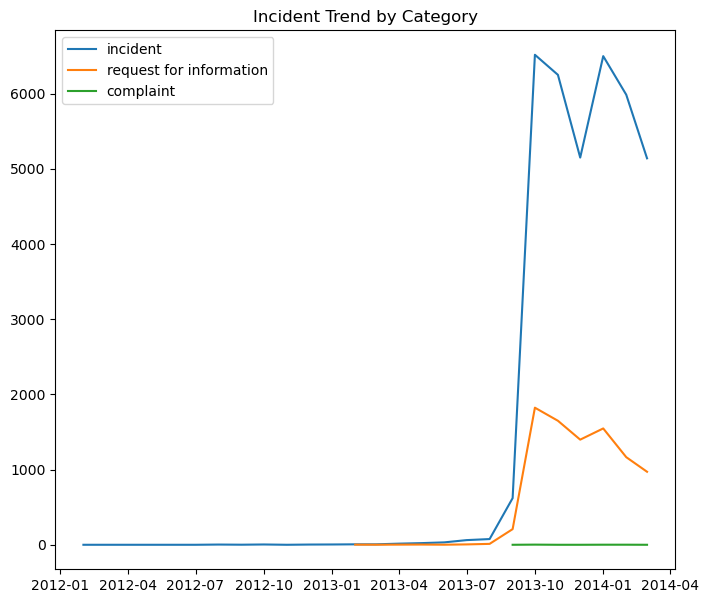

In [106]:
category_ts = (
    df.groupby(['Month','Category'])
      .size()
      .reset_index(name='count')
)
plt.figure(figsize=(8,7))
for cat in category_ts['Category'].unique():
    temp = category_ts[category_ts['Category'] == cat]
    plt.plot(temp['Month'].dt.to_timestamp(), temp['count'], label=cat)

plt.legend()
plt.title("Incident Trend by Category")
plt.show()


**Insights:** There is a sudden spike in the incidents after July 2013, thus data has no seasonal pattern from the initial stages but it has seen in the last 1 year data from April 2013 to April 2014. but which is insufficient for drawing seasonal inference. But the trend is indicating there is a spike in incidents.

In [107]:
ci_cat_ts = (
    df.groupby(['Month','CI_Cat'])
      .size()
      .reset_index(name='incident_count')
)

ci_cat_ts.head()

,Month,CI_Cat,incident_count
0,2012-02,subapplication,1
1,2012-03,application,1
2,2012-07,application,1
3,2012-08,application,4
4,2012-09,application,2


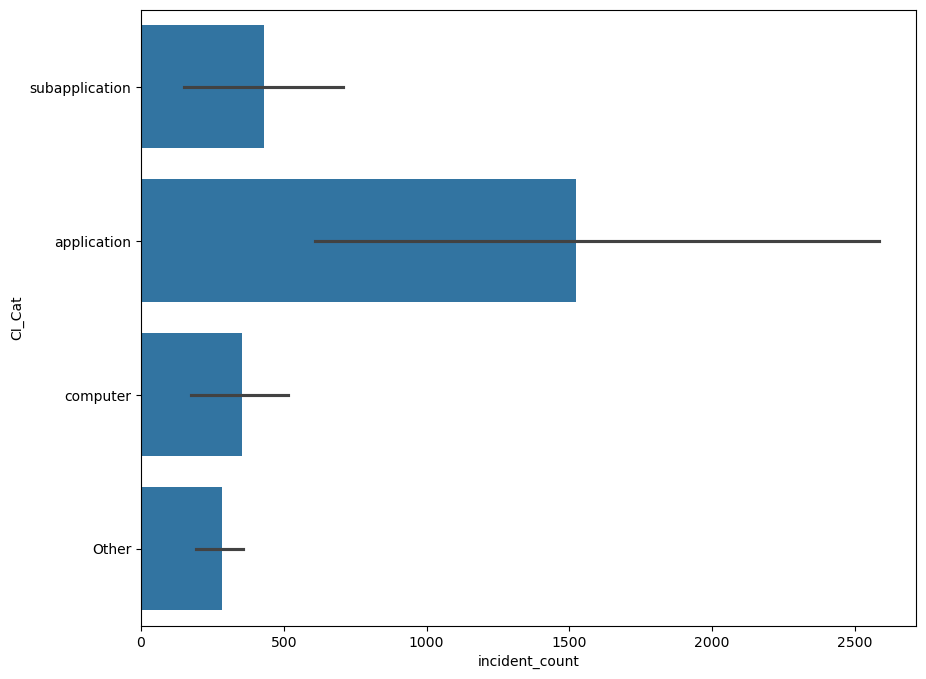

In [108]:
order = ci_cat_ts.sort_values('incident_count')['CI_Cat']

plt.figure(figsize=(10,8))
sns.barplot(
    y='CI_Cat',
    x='incident_count',
    data=ci_cat_ts,
    order=order
)
plt.show()

**Insights**: Majority segment in CI_Cat are application and subapplication. Thus focus only on that segment.

In [109]:
ci_subcat_ts = (
    df.groupby(['Month','CI_Subcat_Group'])
      .size()
      .reset_index(name='incident_count')
)

In [110]:
ci_subcat_ts.head()

,Month,CI_Subcat_Group,incident_count
0,2012-02,Web Based Application,1
1,2012-03,Web Based Application,1
2,2012-07,Web Based Application,1
3,2012-08,Web Based Application,4
4,2012-09,Web Based Application,2


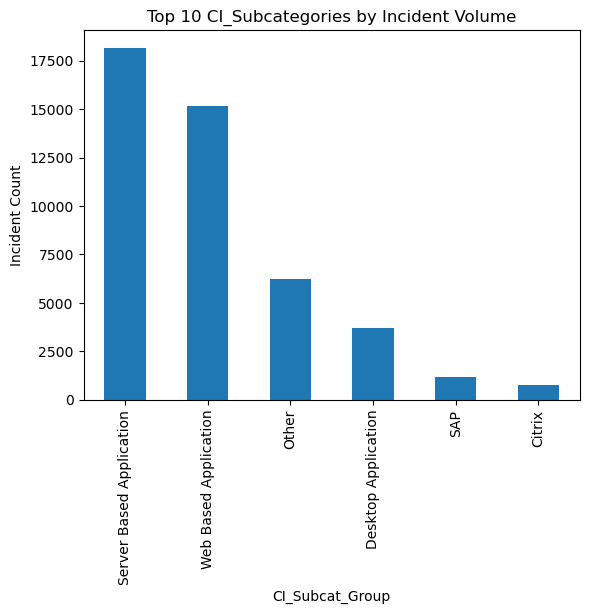

In [111]:
top_ci = (
    df['CI_Subcat_Group']
    .value_counts()
    .head(10)
)

plt.figure()
top_ci.plot(kind='bar')
plt.title("Top 10 CI_Subcategories by Incident Volume")
plt.ylabel("Incident Count")
plt.show()


**Insights**: Majority segement are Server Based Application and Web Based Application thus focus only on that forecasting.

In [112]:
priority_ts = (
    df.groupby(['Month','High_Priority'])
      .size()
      .reset_index(name='incident_count')
)

In [113]:
priority_ts.head()

,Month,High_Priority,incident_count
0,2012-02,0,1
1,2012-03,0,1
2,2012-07,0,1
3,2012-08,0,4
4,2012-09,0,2


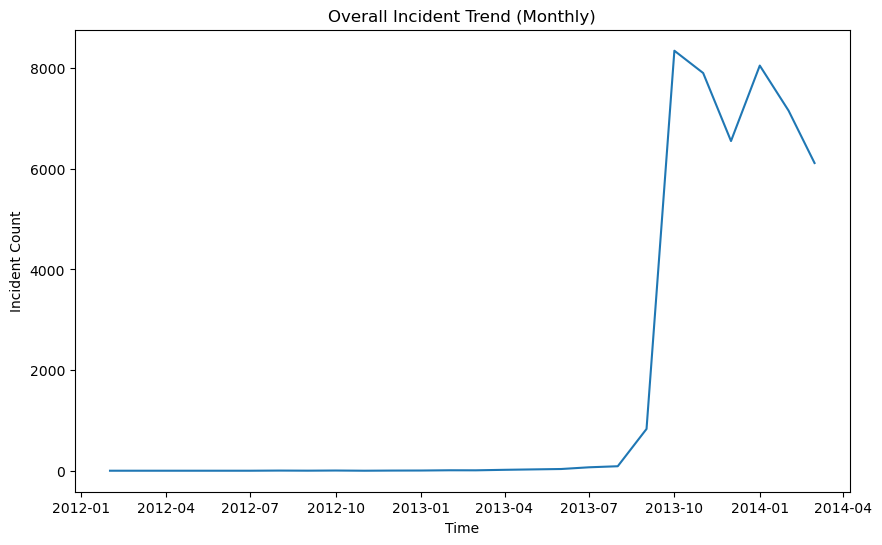

In [114]:
monthly_total = (
    df.groupby('Month')
      .size()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(monthly_total.index.to_timestamp(), monthly_total.values)
plt.title("Overall Incident Trend (Monthly)")
plt.xlabel("Time")
plt.ylabel("Incident Count")
plt.show()

In [115]:
df.head()

,CI_Cat,Category,Open_Time,Department,CI_Subcat_Group,High_Priority,Month
0,subapplication,incident,2012-02-05 13:32:00,0,Web Based Application,0,2012-02
1,application,incident,2012-03-12 15:44:00,0,Web Based Application,0,2012-03
2,application,incident,2012-07-17 11:49:00,0,Web Based Application,0,2012-07
3,application,incident,2012-08-10 11:01:00,0,Web Based Application,0,2012-08
4,application,incident,2012-08-10 11:27:00,0,Web Based Application,0,2012-08


### Time Series for Overall Incident Forecasting

In [116]:
df['Open_Date']=pd.to_datetime(df['Open_Time'])

ts_incident=(
    df.groupby(pd.Grouper(key='Open_Date', freq='M'),'Category'=='incident')
    .size()
    .reset_index(name='incident_count')
)

In [117]:
ts_incident

,Open_Date,incident_count
0,2012-02-29,1
1,2012-03-31,1
2,2012-04-30,0
3,2012-05-31,0
4,2012-06-30,0
5,2012-07-31,1
6,2012-08-31,4
7,2012-09-30,2
8,2012-10-31,5
9,2012-11-30,1


In [118]:
ts_incident.dtypes

Open_Date         datetime64[ns]
incident_count             int64
dtype: object

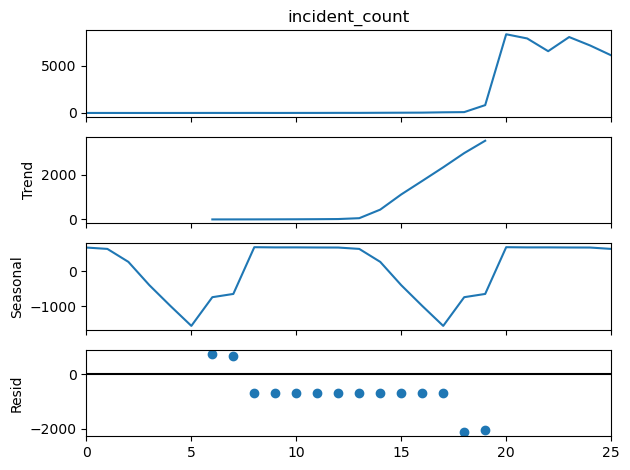

In [119]:
from statsmodels.tsa.seasonal import seasonal_decompose

#ts_incident = ts_incident.set_index('Open_Date')

decomp = seasonal_decompose(
    ts_incident['incident_count'],
    model='additive',  # or 'multiplicative'
    period=12          # 12 for monthly data
)

decomp.plot()
plt.show()

#### Cleaning Time series

In [120]:
ts_incident

,Open_Date,incident_count
0,2012-02-29,1
1,2012-03-31,1
2,2012-04-30,0
3,2012-05-31,0
4,2012-06-30,0
5,2012-07-31,1
6,2012-08-31,4
7,2012-09-30,2
8,2012-10-31,5
9,2012-11-30,1


In [121]:
Q1 = ts_incident['incident_count'].quantile(0.25)
Q3 = ts_incident['incident_count'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR
ts_incident['incident_count'] = ts_incident['incident_count'].clip(
    lower=lower,
    upper=upper
)

In [122]:
ts_incident

,Open_Date,incident_count
0,2012-02-29,1.0
1,2012-03-31,1.0
2,2012-04-30,0.0
3,2012-05-31,0.0
4,2012-06-30,0.0
5,2012-07-31,1.0
6,2012-08-31,4.0
7,2012-09-30,2.0
8,2012-10-31,5.0
9,2012-11-30,1.0


In [123]:
ts_incident['incident_count'] = np.log1p(
    ts_incident['incident_count']
)

In [124]:
ts_incident

,Open_Date,incident_count
0,2012-02-29,0.693147
1,2012-03-31,0.693147
2,2012-04-30,0.000000
3,2012-05-31,0.000000
4,2012-06-30,0.000000
5,2012-07-31,0.693147
6,2012-08-31,1.609438
7,2012-09-30,1.098612
8,2012-10-31,1.791759
9,2012-11-30,0.693147


In [125]:
#ts_incident.drop(columns=['month'], inplace=True)

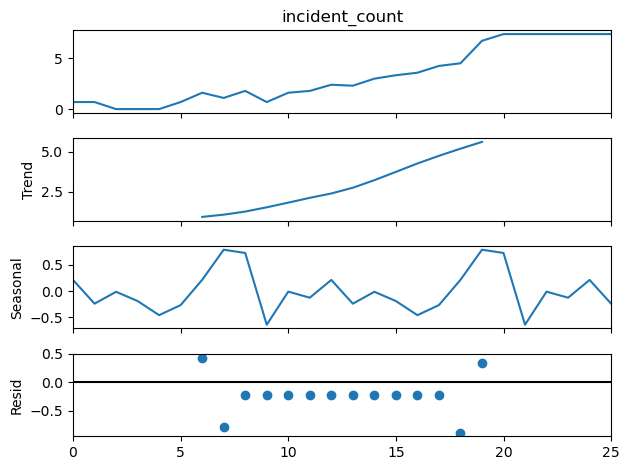

In [126]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(
    ts_incident['incident_count'],
    model='additive',
    period=12
)
decomp.plot()
plt.show()

In [127]:
# Convert DataFrame → Series
ts_incident = ts_incident['incident_count']

# Ensure index is datetime
#ts_incident.index = pd.to_datetime(ts_incident.index)

# Ensure values are numeric
ts_incident = pd.to_numeric(ts_incident, errors='coerce')

# Drop bad rows
ts_incident = ts_incident.dropna()


In [128]:
#ts_incident = ts_incident.squeeze()

In [129]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts_incident.values)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.05662574336005484
p-value: 0.9629718823959648


In [130]:
# Train-test split (80%-20%)
train_size = int(len(ts_incident) * 0.8)
train, test = ts_incident[:train_size], ts_incident[train_size:]

In [131]:
from statsmodels.tsa.arima.model import ARIMA

model=ARIMA(train, order=(0, 1, 3),
    seasonal_order=(1,1,1,12))

model=model.fit()

In [132]:
print(model.aic)

32.81288825207844


In [133]:
forecast_log = model.forecast(steps=12)
forecast = np.expm1(forecast_log)

In [134]:
prediction=model.forecast(steps=6)

In [135]:
prediction

20    6.884181
21    4.664658
22    6.772344
23    6.954841
24    7.560824
25    7.465470
Name: predicted_mean, dtype: float64

In [136]:
test.shape

(6,)

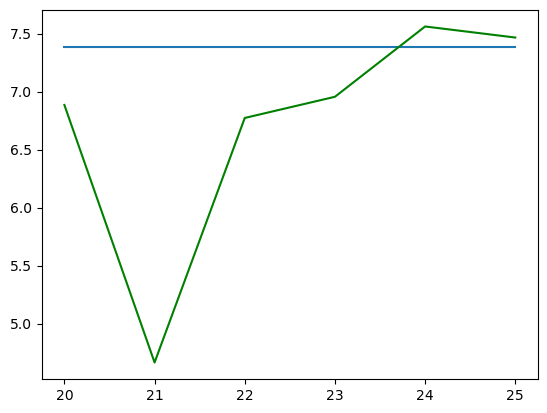

In [137]:
plt.plot(test[:6])    #actual values   >>> blue
plt.plot(prediction, color='green')  #graph of test vs prediction

In [138]:
 import numpy as np

def forecast_accuracy(prediction, actual):
    mse = np.mean((prediction - actual)**2)        # MSE
    mae = np.mean(np.abs(prediction - actual))     # MAE
    rmse = np.sqrt(mse)                             # RMSE

    return {'mse': mse, 'mae': mae, 'rmse': rmse}

In [139]:
# Hyperparameter Tuening
def tune_arima(ts, p_range, d_range, q_range, test_size=6):
    from statsmodels.tsa.arima.model import ARIMA
    from sklearn.metrics import mean_absolute_error
    import itertools, warnings

    warnings.filterwarnings("ignore")

    train = ts[:-test_size]
    test  = ts[-test_size:]

    best_score = float("inf")
    best_order = None

    for order in itertools.product(p_range, d_range, q_range):
        try:
            model = ARIMA(train, order=order)
            model_fit = model.fit()

            preds = model_fit.forecast(len(test))
            score = mean_absolute_error(test, preds)

            if score < best_score:
                best_score = score
                best_order = order
        except:
            continue

    return best_order, best_score


In [140]:
best_order, best_mae = tune_arima(
    ts_incident,
    p_range=range(0,4),
    d_range=range(0,3),
    q_range=range(0,4)
)

best_order, best_mae


((0, 1, 3), 0.14733131671322072)

In [141]:
import itertools

p = range(0, 4)
d = range(0, 3)
q = range(0, 4)

pdq = list(itertools.product(p, d, q))

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

results = []

for order in pdq:
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()

        forecast = model_fit.forecast(steps=len(test))
        mae = mean_absolute_error(test, forecast)

        results.append({
            'order': order,
            'MAE': mae
        })
    except:
        continue


In [142]:
results_df = pd.DataFrame(results)
best_model = results_df.sort_values('MAE').iloc[0]

best_model


order    (0, 1, 3)
MAE       0.147331
Name: 7, dtype: object

## CI_Cat feature

In [143]:
df.head()

,CI_Cat,Category,Open_Time,Department,CI_Subcat_Group,High_Priority,Month,Open_Date
0,subapplication,incident,2012-02-05 13:32:00,0,Web Based Application,0,2012-02,2012-02-05 13:32:00
1,application,incident,2012-03-12 15:44:00,0,Web Based Application,0,2012-03,2012-03-12 15:44:00
2,application,incident,2012-07-17 11:49:00,0,Web Based Application,0,2012-07,2012-07-17 11:49:00
3,application,incident,2012-08-10 11:01:00,0,Web Based Application,0,2012-08,2012-08-10 11:01:00
4,application,incident,2012-08-10 11:27:00,0,Web Based Application,0,2012-08,2012-08-10 11:27:00


### Time Series for application of CI_Cat's, incident forecasting

In [144]:
# CI_Cat
df['Open_Date']=pd.to_datetime(df['Open_Time'])
ts_Cat_1= (
    df[(df['Category'] == 'incident') & (df['CI_Cat'] == 'application')]
      .groupby(pd.Grouper(key='Open_Date', freq='M'))
      .size()
      .reset_index(name='incident_count')
)


In [145]:
ts_Cat_1

,Open_Date,incident_count
0,2012-03-31,1
1,2012-04-30,0
2,2012-05-31,0
3,2012-06-30,0
4,2012-07-31,1
5,2012-08-31,4
6,2012-09-30,2
7,2012-10-31,5
8,2012-11-30,0
9,2012-12-31,3


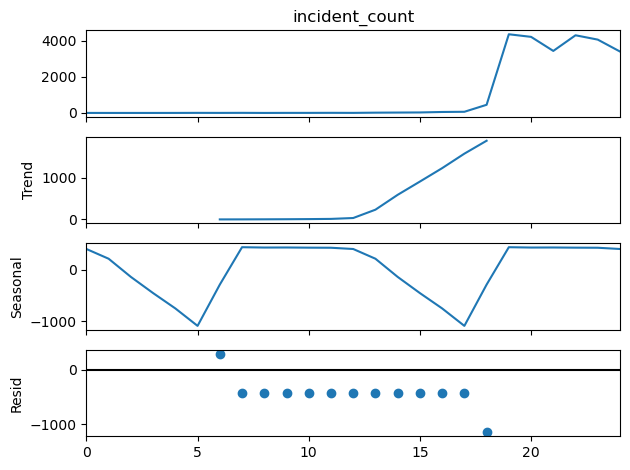

In [146]:
from statsmodels.tsa.seasonal import seasonal_decompose

#ts_incident = ts_incident.set_index('Open_Date')

decomp = seasonal_decompose(
    ts_Cat_1['incident_count'],
    model='additive',  # or 'multiplicative'
    period=12          # 12 for monthly data
)

decomp.plot()
plt.show()

In [147]:
ts_Cat_1

,Open_Date,incident_count
0,2012-03-31,1
1,2012-04-30,0
2,2012-05-31,0
3,2012-06-30,0
4,2012-07-31,1
5,2012-08-31,4
6,2012-09-30,2
7,2012-10-31,5
8,2012-11-30,0
9,2012-12-31,3


#### Cleaning Time series

In [148]:
Q1 = ts_Cat_1['incident_count'].quantile(0.25)
Q3 = ts_Cat_1['incident_count'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR
ts_Cat_1['incident_count'] = ts_Cat_1['incident_count'].clip(
    lower=lower,
    upper=upper
)

In [149]:
ts_Cat_1['incident_count'] = np.log1p(
    ts_Cat_1['incident_count']
)

In [150]:
ts_Cat_1

,Open_Date,incident_count
0,2012-03-31,0.693147
1,2012-04-30,0.000000
2,2012-05-31,0.000000
3,2012-06-30,0.000000
4,2012-07-31,0.693147
5,2012-08-31,1.609438
6,2012-09-30,1.098612
7,2012-10-31,1.791759
8,2012-11-30,0.000000
9,2012-12-31,1.386294


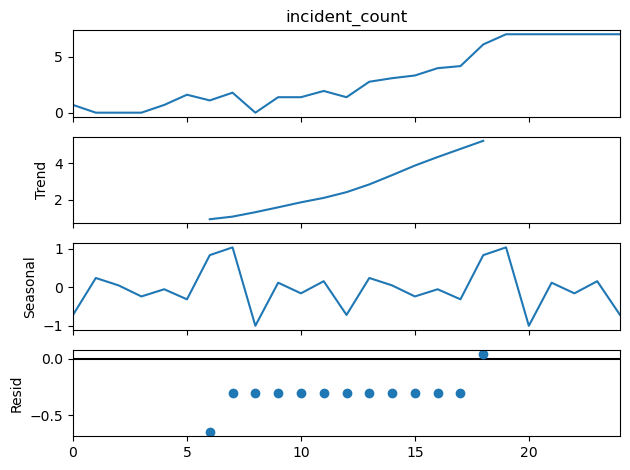

In [151]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(
    ts_Cat_1['incident_count'],
    model='additive',
    period=12
)
decomp.plot()
plt.show()

In [152]:
ts_Cat_1 = ts_Cat_1['incident_count']
ts_Cat_1 = pd.to_numeric(ts_Cat_1, errors='coerce')
ts_Cat_1 = ts_Cat_1.dropna()

In [153]:
# Train-test split (80%-20%)
train_size = int(len(ts_Cat_1) * 0.8)
train, test = ts_Cat_1[:train_size], ts_Cat_1[train_size:]

In [154]:
print(type(train))
print(train.dtype if hasattr(train, 'dtype') else train.dtypes)
print(train.head())

<class 'pandas.core.series.Series'>
float64
0    0.693147
1    0.000000
2    0.000000
3    0.000000
4    0.693147
Name: incident_count, dtype: float64


In [155]:
print(train.dtype)
print(train.head())

float64
0    0.693147
1    0.000000
2    0.000000
3    0.000000
4    0.693147
Name: incident_count, dtype: float64


In [156]:
from statsmodels.tsa.arima.model import ARIMA

model_CI_1=ARIMA(train, order=(0, 1, 0))

model_CI_1=model_CI_1.fit()

In [157]:
print(model_CI_1.aic)

51.989047805574636


In [158]:
prediction=model_CI_1.forecast(steps=6)
prediction

20    7.028201
21    7.028201
22    7.028201
23    7.028201
24    7.028201
25    7.028201
Name: predicted_mean, dtype: float64

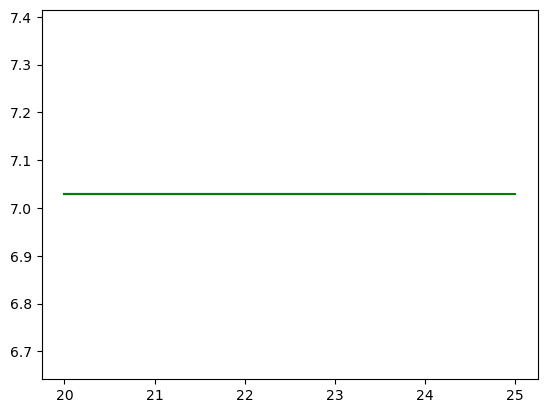

In [159]:
plt.plot(test[:6])    #actual values   >>> blue
plt.plot(prediction, color='green')  #graph of test vs prediction

In [160]:
 import numpy as np

def forecast_accuracy(prediction, actual):
    mse = np.mean((prediction - actual)**2)        # MSE
    mae = np.mean(np.abs(prediction - actual))     # MAE
    rmse = np.sqrt(mse)                             # RMSE

    return {'mse': mse, 'mae': mae, 'rmse': rmse}

In [161]:
forecast_accuracy(prediction,test)

{'mse': 0.0, 'mae': 0.0, 'rmse': 0.0}

#### Hyperparameter Tuening of Time Series

In [162]:
import itertools

p = range(0, 4)
d = range(0, 3)
q = range(0, 4)

pdq = list(itertools.product(p, d, q))

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

results = []

for order in pdq:
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()

        forecast = model_fit.forecast(steps=len(test))
        mae = mean_absolute_error(test, forecast)

        results.append({
            'order': order,
            'MAE': mae
        })
    except:
        continue


In [163]:
results_df = pd.DataFrame(results)
best_model = results_df.sort_values('MAE').iloc[0]

best_model

order    (0, 1, 0)
MAE            0.0
Name: 4, dtype: object

### Time Series for subapplication of CI_Cat's, incident forecasting

In [164]:
df.head()

,CI_Cat,Category,Open_Time,Department,CI_Subcat_Group,High_Priority,Month,Open_Date
0,subapplication,incident,2012-02-05 13:32:00,0,Web Based Application,0,2012-02,2012-02-05 13:32:00
1,application,incident,2012-03-12 15:44:00,0,Web Based Application,0,2012-03,2012-03-12 15:44:00
2,application,incident,2012-07-17 11:49:00,0,Web Based Application,0,2012-07,2012-07-17 11:49:00
3,application,incident,2012-08-10 11:01:00,0,Web Based Application,0,2012-08,2012-08-10 11:01:00
4,application,incident,2012-08-10 11:27:00,0,Web Based Application,0,2012-08,2012-08-10 11:27:00


In [165]:
df['Open_Date']=pd.to_datetime(df['Open_Time'])

ts_Cat_2= (
    df[(df['Category'] == 'incident') & (df['CI_Cat'] == 'subapplication')]
      .groupby(pd.Grouper(key='Open_Date', freq='M'))
      .size()
      .reset_index(name='incident_count')
)

In [166]:
ts_Cat_2

,Open_Date,incident_count
0,2012-02-29,1
1,2012-03-31,0
2,2012-04-30,0
3,2012-05-31,0
4,2012-06-30,0
5,2012-07-31,0
6,2012-08-31,0
7,2012-09-30,0
8,2012-10-31,0
9,2012-11-30,1


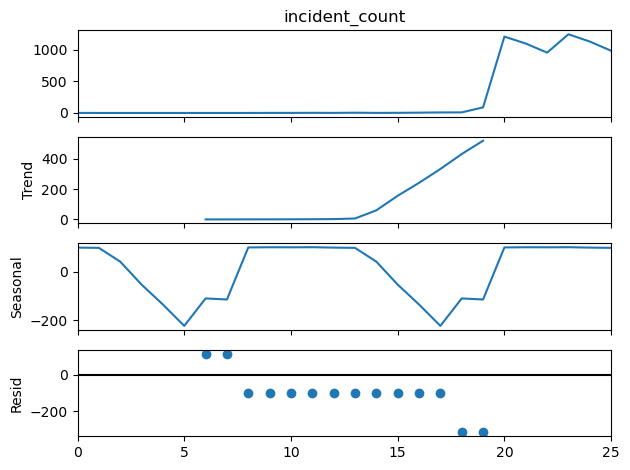

In [167]:
from statsmodels.tsa.seasonal import seasonal_decompose

#ts_incident = ts_incident.set_index('Open_Date')

decomp = seasonal_decompose(
    ts_Cat_2['incident_count'],
    model='additive',  # or 'multiplicative'
    period=12          # 12 for monthly data
)

decomp.plot()
plt.show()

### Data Clening

In [168]:
Q1 = ts_Cat_2['incident_count'].quantile(0.25)
Q3 = ts_Cat_2['incident_count'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR
ts_Cat_2['incident_count'] = ts_Cat_2['incident_count'].clip(
    lower=lower,
    upper=upper
)

In [169]:
ts_Cat_2['incident_count'] = np.log1p(
    ts_Cat_2['incident_count']
)

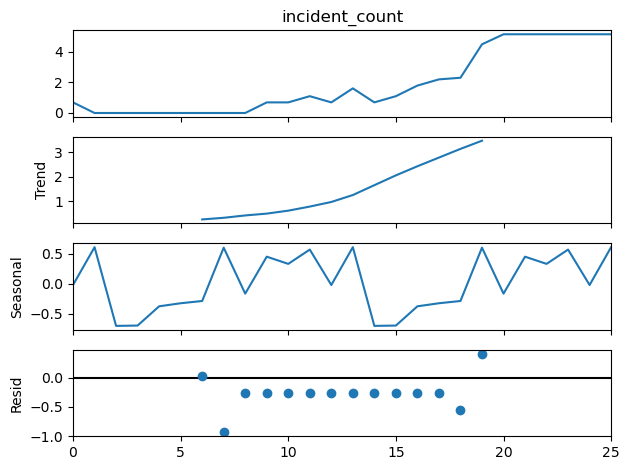

In [170]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(
    ts_Cat_2['incident_count'],
    model='additive',
    period=12
)
decomp.plot()
plt.show()

In [171]:
ts_Cat_2 = ts_Cat_2['incident_count']
ts_Cat_2 = pd.to_numeric(ts_Cat_2, errors='coerce')
ts_Cat_2 = ts_Cat_2.dropna()

In [172]:
# Train-test split (80%-20%)
train_size = int(len(ts_Cat_2) * 0.8)
train, test = ts_Cat_2[:train_size], ts_Cat_2[train_size:]

In [173]:
from statsmodels.tsa.arima.model import ARIMA

model_CI_2=ARIMA(train, order=(0, 1, 3))

model_CI_2=model_CI_2.fit()

In [174]:
print(model_CI_2.aic)

39.75517987530006


In [175]:
prediction=model_CI_2.forecast(steps=6)

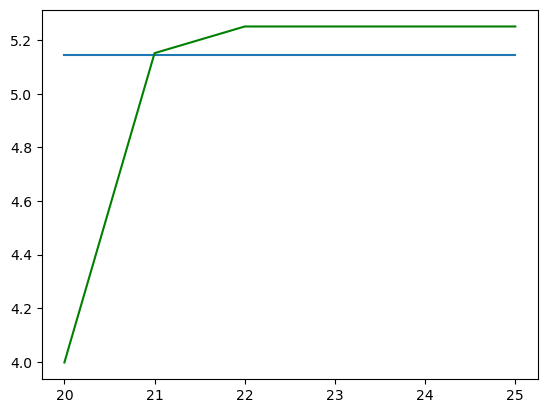

In [176]:
plt.plot(test[:6])    #actual values   >>> blue
plt.plot(prediction, color='green')  #graph of test vs prediction

In [177]:
forecast_accuracy(prediction, test)

{'mse': 0.22687991355432824,
 'mae': 0.26270905976798437,
 'rmse': 0.476319129947904}

### Hyperparameter tuening

In [178]:
import itertools

p = range(0, 4)
d = range(0, 3)
q = range(0, 4)

pdq = list(itertools.product(p, d, q))

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

results = []

for order in pdq:
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()

        forecast = model_fit.forecast(steps=len(test))
        mae = mean_absolute_error(test, forecast)

        results.append({
            'order': order,
            'MAE': mae
        })
    except:
        continue


In [179]:
results_df = pd.DataFrame(results)
best_model = results_df.sort_values('MAE').iloc[0]

best_model


order    (0, 1, 3)
MAE       0.262709
Name: 7, dtype: object

## CI_Subcat

In [180]:
df.head()

,CI_Cat,Category,Open_Time,Department,CI_Subcat_Group,High_Priority,Month,Open_Date
0,subapplication,incident,2012-02-05 13:32:00,0,Web Based Application,0,2012-02,2012-02-05 13:32:00
1,application,incident,2012-03-12 15:44:00,0,Web Based Application,0,2012-03,2012-03-12 15:44:00
2,application,incident,2012-07-17 11:49:00,0,Web Based Application,0,2012-07,2012-07-17 11:49:00
3,application,incident,2012-08-10 11:01:00,0,Web Based Application,0,2012-08,2012-08-10 11:01:00
4,application,incident,2012-08-10 11:27:00,0,Web Based Application,0,2012-08,2012-08-10 11:27:00


In [181]:
df['CI_Subcat_Group'].value_counts()

CI_Subcat_Group
Server Based Application    18172
Web Based Application       15172
Other                        6215
Desktop Application          3709
SAP                          1195
Citrix                        762
Name: count, dtype: int64

In [182]:
df['Open_Date']=pd.to_datetime(df['Open_Time'])

ts_Cat_3= (
    df[(df['Category'] == 'incident') & (df['CI_Subcat_Group'] == 'Server Based Application')]
      .groupby(pd.Grouper(key='Open_Date', freq='M'))
      .size()
      .reset_index(name='incident_count')
)

In [183]:
df['Open_Date']=pd.to_datetime(df['Open_Time'])

ts_Cat_4= (
    df[(df['Category'] == 'incident') & (df['CI_Subcat_Group'] == 'Web Based Application')]
      .groupby(pd.Grouper(key='Open_Date', freq='M'))
      .size()
      .reset_index(name='incident_count')
)

### Time Series for Server Based Application of CI_Cat's, incident forecasting

In [184]:
ts_Cat_3

,Open_Date,incident_count
0,2012-10-31,1
1,2012-11-30,0
2,2012-12-31,0
3,2013-01-31,0
4,2013-02-28,0
5,2013-03-31,1
6,2013-04-30,4
7,2013-05-31,7
8,2013-06-30,7
9,2013-07-31,13


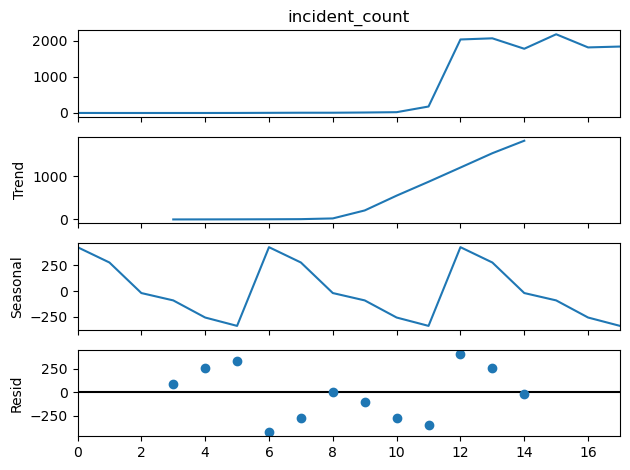

In [185]:
from statsmodels.tsa.seasonal import seasonal_decompose

#ts_incident = ts_incident.set_index('Open_Date')

decomp = seasonal_decompose(
    ts_Cat_3['incident_count'],
    model='additive',  # or 'multiplicative'
    period=6          # 12 for monthly data
)

decomp.plot()
plt.show()

### Data Cleaning

In [186]:
Q1 = ts_Cat_3['incident_count'].quantile(0.25)
Q3 = ts_Cat_3['incident_count'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR
ts_Cat_3['incident_count'] = ts_Cat_3['incident_count'].clip(
    lower=lower,
    upper=upper
)

In [187]:
ts_Cat_3['incident_count'] = np.log1p(
    ts_Cat_3['incident_count']
)

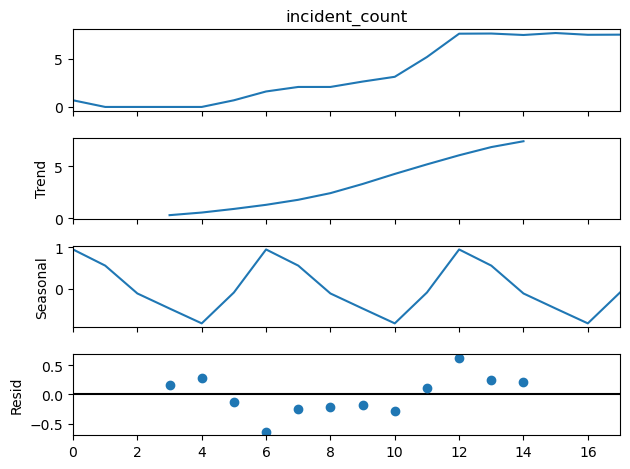

In [188]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(
    ts_Cat_3['incident_count'],
    model='additive',
    period=6
)
decomp.plot()
plt.show()

In [189]:
ts_Cat_3 = ts_Cat_3['incident_count']
ts_Cat_3 = pd.to_numeric(ts_Cat_3, errors='coerce')
ts_Cat_3 = ts_Cat_3.dropna()

In [190]:
# Train-test split (80%-20%)
train_size = int(len(ts_Cat_3) * 0.8)
train, test = ts_Cat_3[:train_size], ts_Cat_3[train_size:]

In [191]:
from statsmodels.tsa.arima.model import ARIMA

model_CI_3=ARIMA(train, order=(3, 1, 1))

model_CI_3=model_CI_3.fit()

In [192]:
print(model_CI_3.aic)

38.513184281396875


In [193]:
prediction=model_CI_3.forecast(steps=6)
prediction

14    7.402317
15    7.552478
16    7.533848
17    7.534496
18    7.542221
19    7.541376
Name: predicted_mean, dtype: float64

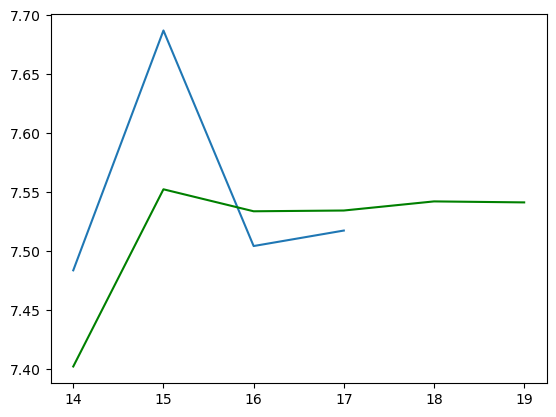

In [194]:
plt.plot(test[:6])    #actual values   >>> blue
plt.plot(prediction, color='green')  #graph of test vs prediction

In [195]:
forecast_accuracy(prediction, test)

{'mse': 0.006478522315860847,
 'mae': 0.06563081504043344,
 'rmse': 0.0804892683272798}

### Hyperparameter Tuening

In [196]:
import itertools

p = range(0, 4)
d = range(0, 3)
q = range(0, 4)

pdq = list(itertools.product(p, d, q))

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

results = []

for order in pdq:
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()

        forecast = model_fit.forecast(steps=len(test))
        mae = mean_absolute_error(test, forecast)

        results.append({
            'order': order,
            'MAE': mae
        })
    except:
        continue


In [197]:
results_df = pd.DataFrame(results)
best_model = results_df.sort_values('MAE').iloc[0]

best_model

order    (3, 1, 1)
MAE       0.065631
Name: 41, dtype: object

### Time Series for Web Based Application of CI_Cat's, incident forecasting

In [198]:
ts_Cat_4

,Open_Date,incident_count
0,2012-02-29,1
1,2012-03-31,1
2,2012-04-30,0
3,2012-05-31,0
4,2012-06-30,0
5,2012-07-31,1
6,2012-08-31,4
7,2012-09-30,2
8,2012-10-31,4
9,2012-11-30,1


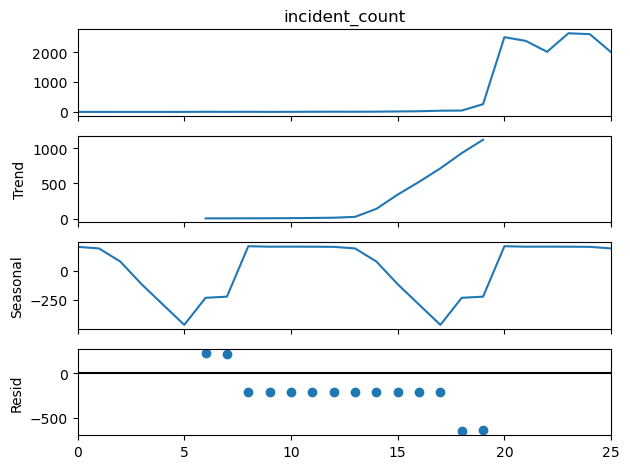

In [199]:
decomp = seasonal_decompose(
    ts_Cat_4['incident_count'],
    model='additive',  # or 'multiplicative'
    period=12          # 12 for monthly data
)

decomp.plot()
plt.show()

### Hyperparameter tuening

In [200]:
Q1 = ts_Cat_4['incident_count'].quantile(0.25)
Q3 = ts_Cat_4['incident_count'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR
ts_Cat_4['incident_count'] = ts_Cat_4['incident_count'].clip(
    lower=lower,
    upper=upper
)

In [201]:
ts_Cat_4['incident_count'] = np.log1p(
    ts_Cat_4['incident_count']
)

In [202]:
ts_Cat_4

,Open_Date,incident_count
0,2012-02-29,0.693147
1,2012-03-31,0.693147
2,2012-04-30,0.000000
3,2012-05-31,0.000000
4,2012-06-30,0.000000
5,2012-07-31,0.693147
6,2012-08-31,1.609438
7,2012-09-30,1.098612
8,2012-10-31,1.609438
9,2012-11-30,0.693147


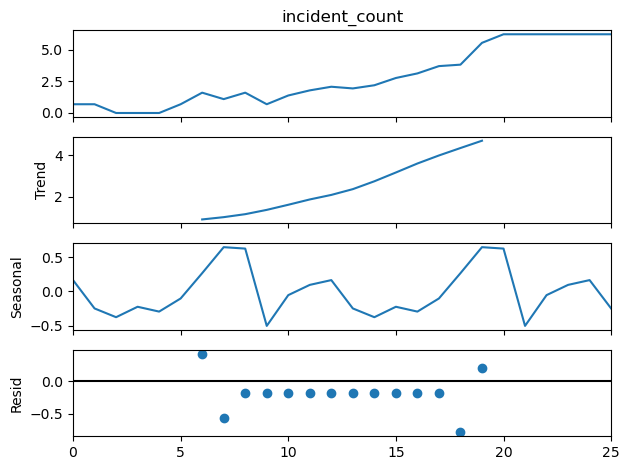

In [203]:
decomp = seasonal_decompose(
    ts_Cat_4['incident_count'],
    model='additive',
    period=12
)
decomp.plot()
plt.show()

In [204]:
ts_Cat_4 = ts_Cat_4['incident_count']
ts_Cat_4 = pd.to_numeric(ts_Cat_4, errors='coerce')
ts_Cat_4 = ts_Cat_4.dropna()

In [205]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts_Cat_4)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.05076099474699184
p-value: 0.9625340132664922


In [206]:
# Make it Stationary
#ts_Cat_4 = ts_Cat_4.diff().diff(12).dropna()

In [207]:
# Train-test split (80%-20%)
train_size = int(len(ts_Cat_4) * 0.8)
train, test = ts_Cat_4[:train_size], ts_Cat_4[train_size:]

In [208]:
from statsmodels.tsa.arima.model import ARIMA

model_CI_4=ARIMA(train, order=(2, 1, 3))

model_CI_4=model_CI_4.fit()

In [209]:
print(model_CI_4.aic)

43.38044962950317


In [210]:
prediction=model_CI_4.forecast(steps=6)
prediction

20    5.667207
21    6.251301
22    5.973341
23    5.982896
24    6.094666
25    5.984575
Name: predicted_mean, dtype: float64

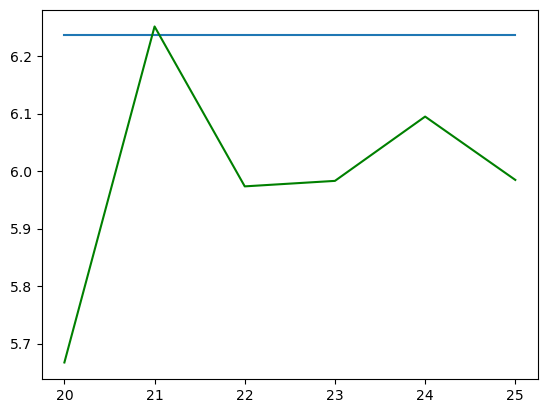

In [211]:
plt.plot(test[:6])    #actual values   >>> blue
plt.plot(prediction, color='green')  #graph of test vs prediction

In [212]:
forecast_accuracy(prediction, test)

{'mse': 0.0901804694133551,
 'mae': 0.2490157883734092,
 'rmse': 0.3003006317232035}

### Hyperparameter tuening

In [213]:
import itertools

p = range(0, 4)
d = range(0, 3)
q = range(0, 4)

pdq = list(itertools.product(p, d, q))

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

results = []

for order in pdq:
    try:
        model = ARIMA(train, order=order)
        model_fit = model.fit()

        forecast = model_fit.forecast(steps=len(test))
        mae = mean_absolute_error(test, forecast)

        results.append({
            'order': order,
            'MAE': mae
        })
    except:
        continue


In [214]:
results_df = pd.DataFrame(results)
best_model = results_df.sort_values('MAE').iloc[0]

best_model

order    (3, 1, 2)
MAE       0.224032
Name: 42, dtype: object

In [215]:
import joblib

joblib.dump(model, "model_overall_forecast.pkl")
joblib.dump(model_CI_1, "model_CI_1.pkl")
joblib.dump(model_CI_2, "model_CI_2.pkl")
joblib.dump(model_CI_3, "model_CI_3.pkl")
joblib.dump(model_CI_4, "model_CI_4.pkl")


['model_CI_4.pkl']

# **Task 3️⃣ Auto-Tag Priority & Department**
### 🎯 Business Goal

Reduce wrong assignment, reassignments, and SLA delays.

### 🧠 ML Problem Type

👉 Multi-class / Multi-output Classification

### Part 1: for Priority predition

In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [217]:
col=['CI_Cat', 'CI_Subcat', 'Impact', 'Urgency', 'Category',
       'No_of_Reassignments', 'Priority']

df=pd.read_csv('Cleaned_Data.csv', usecols=col)

In [218]:
df

,CI_Cat,CI_Subcat,Impact,Urgency,Priority,Category,No_of_Reassignments
0,0.170702,0.335478,0.75,0.75,4,0.805152,0.565217
1,0.707219,0.335478,0.50,0.50,3,0.805152,0.717391
2,0.707219,0.335478,0.75,0.75,4,0.805152,0.282609
3,0.707219,0.335478,0.75,0.75,4,0.805152,0.043478
4,0.707219,0.335478,0.75,0.75,4,0.805152,0.086957
...,...,...,...,...,...,...,...
45220,0.707219,0.401813,0.75,0.75,4,0.805152,0.000000
45221,0.707219,0.401813,0.75,0.75,4,0.805152,0.000000
45222,0.078364,0.042012,1.00,1.00,5,0.805152,0.000000
45223,0.707219,0.335478,0.75,0.75,4,0.805152,0.000000


In [219]:
X = df.drop(columns=['Priority'], errors='ignore')
y = df['Priority']

In [220]:
print(y.dtype)
print(np.unique(y))

int64
[1 2 3 4 5]


In [221]:
y.value_counts()

Priority
4    22717
5    16485
3     5323
2      697
1        3
Name: count, dtype: int64

In [222]:
X

,CI_Cat,CI_Subcat,Impact,Urgency,Category,No_of_Reassignments
0,0.170702,0.335478,0.75,0.75,0.805152,0.565217
1,0.707219,0.335478,0.50,0.50,0.805152,0.717391
2,0.707219,0.335478,0.75,0.75,0.805152,0.282609
3,0.707219,0.335478,0.75,0.75,0.805152,0.043478
4,0.707219,0.335478,0.75,0.75,0.805152,0.086957
...,...,...,...,...,...,...
45220,0.707219,0.401813,0.75,0.75,0.805152,0.000000
45221,0.707219,0.401813,0.75,0.75,0.805152,0.000000
45222,0.078364,0.042012,1.00,1.00,0.805152,0.000000
45223,0.707219,0.335478,0.75,0.75,0.805152,0.000000


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=42)

                     Train Accuracy  Test Accuracy  CV Score
Decision Tree              1.000000       1.000000  0.999912
Gradient Boosting          1.000000       1.000000  0.999956
Random Forest              1.000000       0.999889  0.999934
SVM                        0.999862       0.999889  0.999889
KNN                        0.999668       0.999558  0.999403
Naive Bayes                0.999668       0.999558  0.999558
Logistic Regression        0.997402       0.997236  0.995976


<Figure size 1200x600 with 0 Axes>

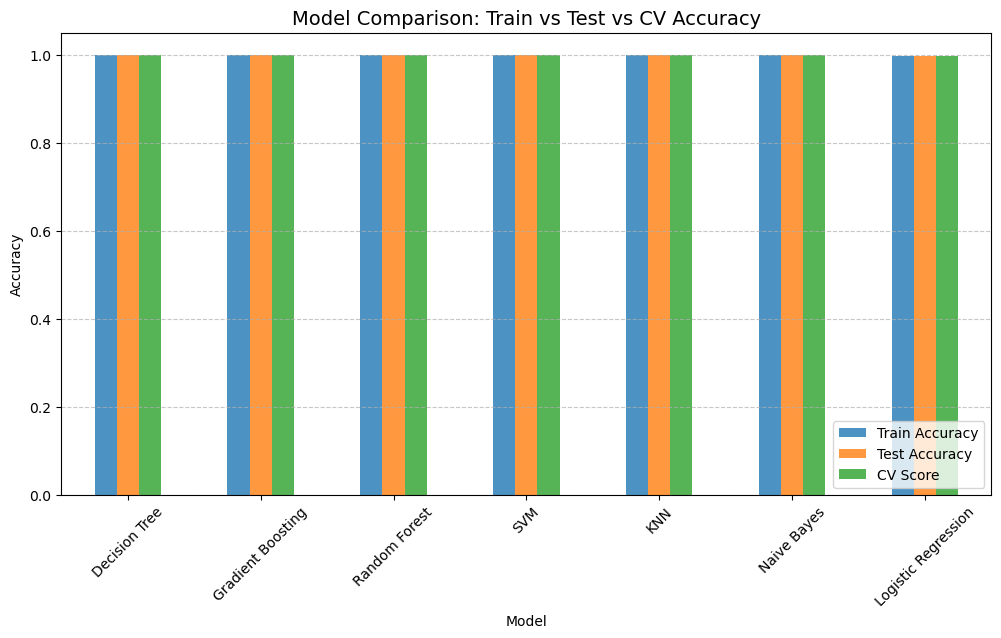


========== DETAILED CLASSIFICATION REPORTS & CONFUSION MATRICES ==========


Model: Logistic Regression
              precision    recall  f1-score   support

           2       1.00      0.99      1.00       134
           3       1.00      0.98      0.99      1080
           4       0.99      1.00      1.00      4499
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9045
   macro avg       1.00      0.99      1.00      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[ 133    1    0    0]
 [   0 1056   24    0]
 [   0    0 4499    0]
 [   0    0    0 3332]]


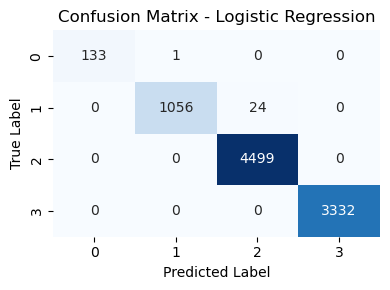

------------------------------------------------------------

Model: Decision Tree
              precision    recall  f1-score   support

           2       1.00      1.00      1.00       134
           3       1.00      1.00      1.00      1080
           4       1.00      1.00      1.00      4499
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[ 134    0    0    0]
 [   0 1080    0    0]
 [   0    0 4499    0]
 [   0    0    0 3332]]


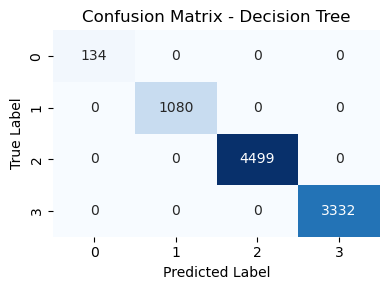

------------------------------------------------------------

Model: Random Forest
              precision    recall  f1-score   support

           2       1.00      1.00      1.00       134
           3       1.00      1.00      1.00      1080
           4       1.00      1.00      1.00      4499
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[ 134    0    0    0]
 [   0 1079    1    0]
 [   0    0 4499    0]
 [   0    0    0 3332]]


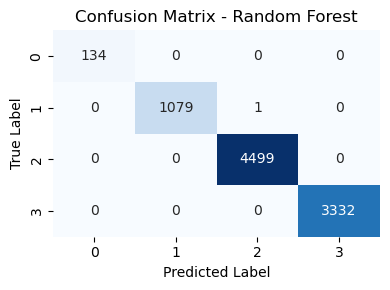

------------------------------------------------------------

Model: Gradient Boosting
              precision    recall  f1-score   support

           2       1.00      1.00      1.00       134
           3       1.00      1.00      1.00      1080
           4       1.00      1.00      1.00      4499
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[ 134    0    0    0]
 [   0 1080    0    0]
 [   0    0 4499    0]
 [   0    0    0 3332]]


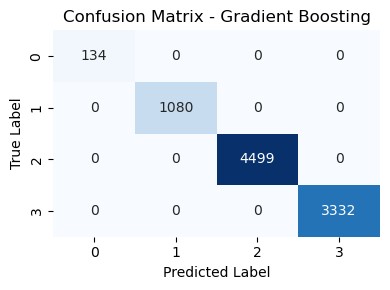

------------------------------------------------------------

Model: SVM
              precision    recall  f1-score   support

           2       1.00      0.99      1.00       134
           3       1.00      1.00      1.00      1080
           4       1.00      1.00      1.00      4499
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[ 133    1    0    0]
 [   0 1080    0    0]
 [   0    0 4499    0]
 [   0    0    0 3332]]


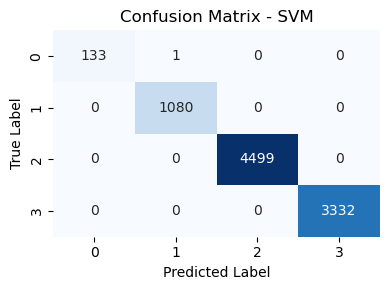

------------------------------------------------------------

Model: KNN
              precision    recall  f1-score   support

           2       1.00      0.99      1.00       134
           3       1.00      1.00      1.00      1080
           4       1.00      1.00      1.00      4499
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[ 133    1    0    0]
 [   0 1079    1    0]
 [   0    1 4497    1]
 [   0    0    0 3332]]


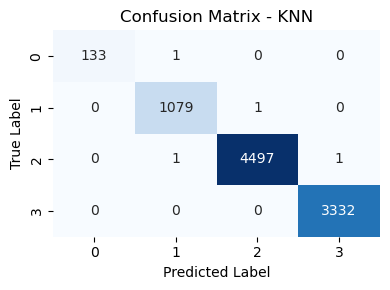

------------------------------------------------------------

Model: Naive Bayes
              precision    recall  f1-score   support

           2       1.00      0.99      0.99       134
           3       1.00      1.00      1.00      1080
           4       1.00      1.00      1.00      4499
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[ 132    2    0    0]
 [   0 1080    0    0]
 [   0    2 4497    0]
 [   0    0    0 3332]]


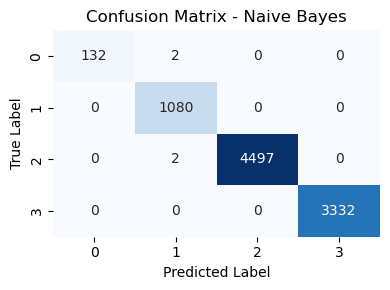

------------------------------------------------------------


In [223]:
# ---------------------------------------
# MULTIPLE CLASSIFICATION MODELS TESTING
# ---------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    #"XGBoost": xgb.XGBClassifier(eval_metric='mlogloss')
}

# Evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Scores
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    cv_score = cross_val_score(model, X, y, cv=5).mean()
    
    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "CV Score": cv_score
    }#

# Convert to DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)
print(results_df)

# ---------------------------------------
# 📊 Visualization
# ---------------------------------------

plt.figure(figsize=(12,6))
results_df[['Train Accuracy','Test Accuracy','CV Score']].plot(
    kind='bar', figsize=(12,6), rot=45, alpha=0.8
)
plt.title("Model Comparison: Train vs Test vs CV Accuracy", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ---------------------------------------------------------
# CLASSIFICATION REPORTS + CONFUSION MATRIX
# ---------------------------------------------------------
print("\n========== DETAILED CLASSIFICATION REPORTS & CONFUSION MATRICES ==========\n")

for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)
    
    # Plot Confusion Matrix as Heatmap
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    print("-" * 60)


In [224]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
ticket_classifier=model.fit(X_train, y_train)

In [225]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred=ticket_classifier.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           2       1.00      1.00      1.00       134
           3       1.00      1.00      1.00      1080
           4       1.00      1.00      1.00      4499
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

[[ 134    0    0    0]
 [   0 1079    1    0]
 [   0    0 4499    0]
 [   0    0    0 3332]]


In [226]:
import joblib
joblib.dump(ticket_classifier, 'Ticket_Classifer_2.pkl')

['Ticket_Classifer_2.pkl']

### Part 2: for Department prediction

## Feature Engineering
Creating Department based on the CI_cat and CI_Subcat

In [227]:
df=pd.read_csv('Cleaned_Data.csv',usecols=['CI_Cat', 'CI_Subcat', 'Department'])
df.head()

,CI_Cat,CI_Subcat,Department
0,0.170702,0.335478,0
1,0.707219,0.335478,0
2,0.707219,0.335478,0
3,0.707219,0.335478,0
4,0.707219,0.335478,0


In [228]:
X=df[['CI_Cat','CI_Subcat']]
y=df['Department']

In [229]:
y.value_counts()

Department
0     38814
1      2706
2       880
3       803
4       535
5       375
6       359
7       219
8       174
9       130
10      100
11       55
12       46
13       29
Name: count, dtype: int64

                     Train Accuracy  Test Accuracy  CV Score
Random Forest              0.999807       0.999779  0.999580
Decision Tree              0.999807       0.999668  0.999580
KNN                        0.999613       0.999668  0.999270
Gradient Boosting          0.999613       0.999337  0.999292
Naive Bayes                0.970647       0.970149  0.970547
SVM                        0.933997       0.932228  0.933643
Logistic Regression        0.917883       0.915644  0.917435


<Figure size 1200x600 with 0 Axes>

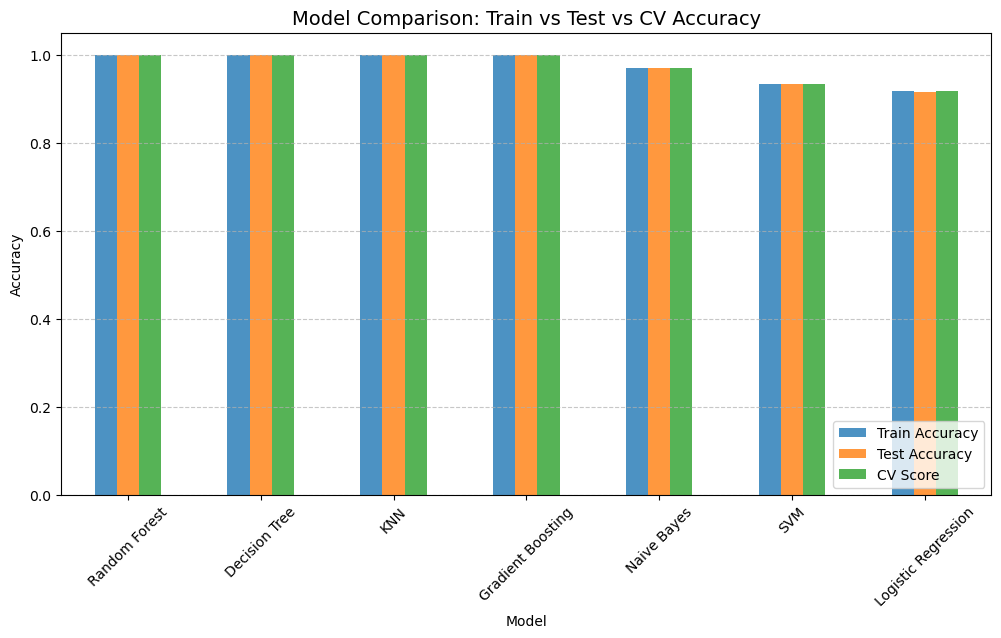


========== DETAILED CLASSIFICATION REPORTS & CONFUSION MATRICES ==========


Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7739
           1       0.47      1.00      0.64       548
           2       0.00      0.00      0.00       189
           3       0.00      0.00      0.00       162
           4       0.00      0.00      0.00       103
           5       0.00      0.00      0.00        77
           6       0.00      0.00      0.00        73
           7       0.00      0.00      0.00        39
           8       0.00      0.00      0.00        39
           9       0.00      0.00      0.00        29
          10       0.00      0.00      0.00        18
          11       0.00      0.00      0.00        13
          12       0.00      0.00      0.00        11
          13       0.00      0.00      0.00         5

    accuracy                           0.92      9045
   macro avg       0.10      

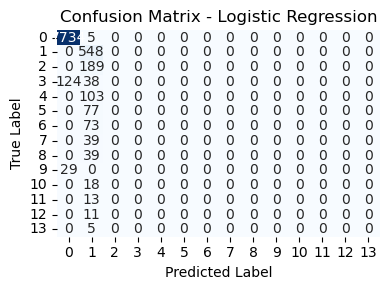

------------------------------------------------------------

Model: Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7739
           1       1.00      1.00      1.00       548
           2       1.00      1.00      1.00       189
           3       1.00      1.00      1.00       162
           4       0.99      1.00      1.00       103
           5       1.00      1.00      1.00        77
           6       1.00      1.00      1.00        73
           7       1.00      0.97      0.99        39
           8       0.97      1.00      0.99        39
           9       1.00      1.00      1.00        29
          10       1.00      1.00      1.00        18
          11       1.00      1.00      1.00        13
          12       1.00      1.00      1.00        11
          13       1.00      1.00      1.00         5

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      90

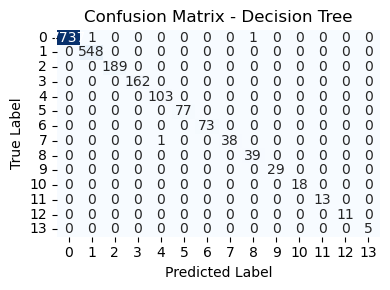

------------------------------------------------------------

Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7739
           1       1.00      1.00      1.00       548
           2       1.00      1.00      1.00       189
           3       1.00      1.00      1.00       162
           4       0.99      1.00      1.00       103
           5       1.00      1.00      1.00        77
           6       1.00      1.00      1.00        73
           7       1.00      0.97      0.99        39
           8       0.97      1.00      0.99        39
           9       1.00      1.00      1.00        29
          10       1.00      1.00      1.00        18
          11       1.00      1.00      1.00        13
          12       1.00      1.00      1.00        11
          13       1.00      1.00      1.00         5

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      90

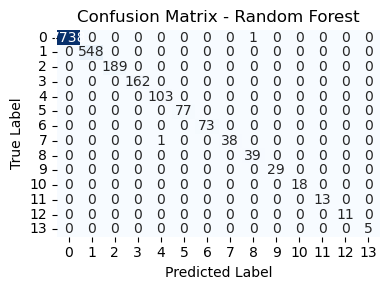

------------------------------------------------------------

Model: Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7739
           1       1.00      1.00      1.00       548
           2       1.00      0.99      0.99       189
           3       0.99      1.00      1.00       162
           4       0.98      1.00      0.99       103
           5       1.00      1.00      1.00        77
           6       1.00      1.00      1.00        73
           7       0.97      0.97      0.97        39
           8       0.97      1.00      0.99        39
           9       1.00      1.00      1.00        29
          10       1.00      0.94      0.97        18
          11       1.00      1.00      1.00        13
          12       1.00      1.00      1.00        11
          13       0.83      1.00      0.91         5

    accuracy                           1.00      9045
   macro avg       0.98      0.99      0.99    

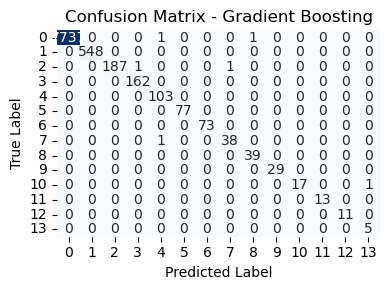

------------------------------------------------------------

Model: SVM
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      7739
           1       1.00      0.69      0.82       548
           2       0.55      0.99      0.70       189
           3       0.88      0.18      0.30       162
           4       0.26      1.00      0.41       103
           5       0.00      0.00      0.00        77
           6       0.00      0.00      0.00        73
           7       0.00      0.00      0.00        39
           8       0.00      0.00      0.00        39
           9       0.00      0.00      0.00        29
          10       0.00      0.00      0.00        18
          11       0.00      0.00      0.00        13
          12       0.00      0.00      0.00        11
          13       0.00      0.00      0.00         5

    accuracy                           0.93      9045
   macro avg       0.26      0.28      0.23      9045
weighte

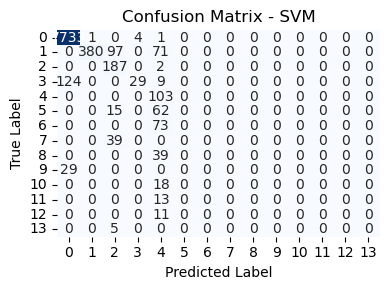

------------------------------------------------------------

Model: KNN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7739
           1       1.00      1.00      1.00       548
           2       1.00      0.99      1.00       189
           3       1.00      1.00      1.00       162
           4       0.99      1.00      1.00       103
           5       1.00      1.00      1.00        77
           6       1.00      1.00      1.00        73
           7       1.00      0.97      0.99        39
           8       0.97      1.00      0.99        39
           9       1.00      1.00      1.00        29
          10       0.95      1.00      0.97        18
          11       1.00      1.00      1.00        13
          12       1.00      1.00      1.00        11
          13       1.00      1.00      1.00         5

    accuracy                           1.00      9045
   macro avg       0.99      1.00      1.00      9045
weighte

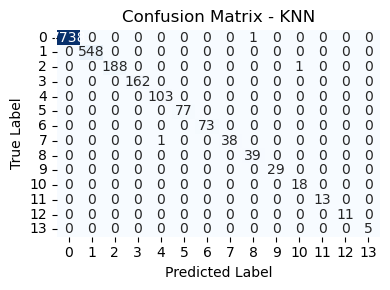

------------------------------------------------------------

Model: Naive Bayes
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      7739
           1       1.00      0.87      0.93       548
           2       1.00      0.99      0.99       189
           3       0.59      0.94      0.73       162
           4       1.00      0.99      1.00       103
           5       0.00      0.00      0.00        77
           6       0.60      1.00      0.75        73
           7       0.71      0.92      0.80        39
           8       0.37      0.97      0.54        39
           9       1.00      1.00      1.00        29
          10       0.82      1.00      0.90        18
          11       1.00      1.00      1.00        13
          12       0.28      1.00      0.43        11
          13       0.62      1.00      0.77         5

    accuracy                           0.97      9045
   macro avg       0.71      0.91      0.77      9045

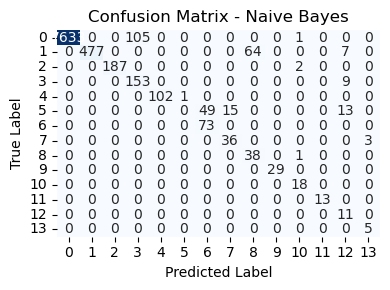

------------------------------------------------------------


In [230]:
# ---------------------------------------
# MULTIPLE CLASSIFICATION MODELS TESTING
# ---------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    #"XGBoost": xgb.XGBClassifier(eval_metric='mlogloss')
}

# Evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Scores
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    cv_score = cross_val_score(model, X, y, cv=5).mean()
    
    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "CV Score": cv_score
    }

# Convert to DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)
print(results_df)

# ---------------------------------------
# 📊 Visualization
# ---------------------------------------

plt.figure(figsize=(12,6))
results_df[['Train Accuracy','Test Accuracy','CV Score']].plot(
    kind='bar', figsize=(12,6), rot=45, alpha=0.8
)
plt.title("Model Comparison: Train vs Test vs CV Accuracy", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ---------------------------------------------------------
# CLASSIFICATION REPORTS + CONFUSION MATRIX
# ---------------------------------------------------------
print("\n========== DETAILED CLASSIFICATION REPORTS & CONFUSION MATRICES ==========\n")

for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)
    
    # Plot Confusion Matrix as Heatmap
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    print("-" * 60)


In [231]:
model=RandomForestClassifier()
Dep_assign=model.fit(X_train, y_train)

In [232]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred=Dep_assign.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7739
           1       1.00      1.00      1.00       548
           2       0.99      1.00      1.00       189
           3       1.00      1.00      1.00       162
           4       0.99      1.00      1.00       103
           5       1.00      1.00      1.00        77
           6       1.00      1.00      1.00        73
           7       1.00      0.97      0.99        39
           8       1.00      1.00      1.00        39
           9       1.00      1.00      1.00        29
          10       1.00      1.00      1.00        18
          11       1.00      1.00      1.00        13
          12       1.00      1.00      1.00        11
          13       1.00      1.00      1.00         5

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

[[7738    0    1    0    

In [233]:
import joblib

joblib.dump(Dep_assign, "Department_Assigned.pkl")

['Department_Assigned.pkl']

# **Task 4️⃣ Predict RFC & Failure / Misconfiguration**
## 🎯 Business Goal

Prevent outages by proactive changes.

## 🧠 ML Problem Type

👉 Classification + Anomaly Detection

In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [235]:
df=pd.read_csv('Basic_Cleand_data.csv', usecols=['CI_Cat','CI_Subcat','Impact','Urgency', 'Category','No_of_Related_Incidents' , 'has_related_incidents' ,'No_of_Related_Changes','has_related_changes','No_of_Reassignments','No_of_Related_Interactions','Open_Time'])

In [236]:
for column in df.columns:
    print(df[column].value_counts())
    print('*********************************************************')
    column=+1
    

#df[['CI_Cat', 'Category' ,'No_of_Related_Changes']].value_counts()

CI_Cat
application             31984
subapplication           7720
computer                 3544
storage                   653
hardware                  406
software                  294
displaydevice             212
database                  168
officeelectronics         139
networkcomponents          99
applicationcomponent        4
Phone                       2
Name: count, dtype: int64
*********************************************************
CI_Subcat
Server Based Application    18172
Web Based Application       15172
Desktop Application          3709
Laptop                       1900
SAP                          1195
                            ...  
zOS Systeem                     1
Firewall                        1
Application Server              1
Protocol                        1
Neoview Server                  1
Name: count, Length: 62, dtype: int64
*********************************************************
Impact
4    22556
5    16740
3     5234
2      692
1        3
Name: c

## Feature Engineering

In [237]:
df['rfc_failed'] = (
    (df['No_of_Related_Incidents'] > 0) |
    (df['has_related_incidents'] == 1)
).astype(int)

**Reason**: create a traget columns which consist of 0 for not failute and 1 for failure based on numbers of related incidents and has related incidents.

In [238]:
ci_fail_rate = df.groupby('CI_Subcat')['rfc_failed'].mean()
df['CI_Subcat_risk'] = df['CI_Subcat'].map(ci_fail_rate)

In [239]:
ci_cat_fail_rate = (
    df.groupby('CI_Cat')['rfc_failed']
      .mean()
)

df['CI_Cat_risk'] = df['CI_Cat'].map(ci_cat_fail_rate)


**Reason**: Create a risk score for specific segments of CI_Cat and CI_Subcat features with repect to failure rate

In [240]:
df['Impact'] = df['Impact'].astype(int)
df['Urgency'] = df['Urgency'].astype(int)


In [241]:
df = pd.get_dummies(df, columns=['Category'], drop_first=True)

**Reason**: Created features such as Category_incidents, Category_complaints and Category_request_for_information. which is used for categorization.

In [242]:
df['related_incident_cnt'] = df['No_of_Related_Incidents']
df['related_change_cnt'] = df['No_of_Related_Changes']


In [243]:
df['reassign_log'] = np.log1p(df['No_of_Reassignments'])

df['interaction_cnt_capped'] = df['No_of_Related_Interactions'].clip(upper=50)


**Reason :** reassign_log features are derived from No_of_reassignment.

In [244]:
df['Open_Time'] = pd.to_datetime(
    df['Open_Time'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)
#df['Open_Time'] = pd.to_datetime(df['Open_Time'], dayfirst=True)

df['open_hour'] = df['Open_Time'].dt.hour
df['open_dow'] = df['Open_Time'].dt.dayofweek
df['is_weekend'] = df['open_dow'].isin([5, 6]).astype(int)
df['is_business_hours'] = df['open_hour'].between(9, 18).astype(int)


**Reason:** Created time based features which are used to analyse it with respect to target feature.

In [281]:
df.head()

,Unnamed: 0,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Impact,Urgency,Priority,number_cnt,...,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,has_related_incidents,has_related_changes,Department
0,0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,4,4,4,0.601292,...,2013-11-04 13:51:00,3871691111,Other,1.0,SD0000007,2.0,0.0,1,0,0
1,1,WBA000124,application,Web Based Application,WBS000088,IM0000005,3,3,3,0.415050,...,2013-12-02 12:36:00,4354786389,Software,1.0,SD0000011,1.0,0.0,1,0,0
2,3,WBA000124,application,Web Based Application,WBS000088,IM0000011,4,4,4,0.642927,...,2013-11-14 09:31:00,4321833333,Operator error,1.0,SD0000025,0.0,0.0,0,0,0
3,4,WBA000124,application,Web Based Application,WBS000088,IM0000012,4,4,4,0.345258,...,2013-11-08 13:55:00,3383903333,Other,1.0,SD0000029,0.0,0.0,0,0,0
4,5,WBA000124,application,Web Based Application,WBS000088,IM0000013,4,4,4,0.006676,...,2013-11-08 13:54:00,3383436944,Other,1.0,SD0000031,0.0,0.0,0,0,0


In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45225 entries, 0 to 45224
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   CI_Cat                            45225 non-null  object        
 1   CI_Subcat                         45225 non-null  object        
 2   Impact                            45225 non-null  int32         
 3   Urgency                           45225 non-null  int32         
 4   No_of_Reassignments               45225 non-null  float64       
 5   Open_Time                         45225 non-null  datetime64[ns]
 6   No_of_Related_Interactions        45225 non-null  float64       
 7   No_of_Related_Incidents           45225 non-null  float64       
 8   No_of_Related_Changes             45225 non-null  float64       
 9   has_related_incidents             45225 non-null  int64         
 10  has_related_changes               45225 non-nu

In [247]:
for column in df.columns:
    print(df[column].value_counts())
    print('*********************************************************')
    column=+1

CI_Cat
application             31984
subapplication           7720
computer                 3544
storage                   653
hardware                  406
software                  294
displaydevice             212
database                  168
officeelectronics         139
networkcomponents          99
applicationcomponent        4
Phone                       2
Name: count, dtype: int64
*********************************************************
CI_Subcat
Server Based Application    18172
Web Based Application       15172
Desktop Application          3709
Laptop                       1900
SAP                          1195
                            ...  
zOS Systeem                     1
Firewall                        1
Application Server              1
Protocol                        1
Neoview Server                  1
Name: count, Length: 62, dtype: int64
*********************************************************
Impact
4    22556
5    16740
3     5234
2      692
1        3
Name: c

In [248]:
features = [
    'CI_Subcat_risk',
    'CI_Cat_risk',
    'Impact',
    'Urgency',
    'Category_incident',
    'Category_request for information',
    'related_incident_cnt',
    #'has_related_incidents',
    'related_change_cnt',
    #'has_related_changes',
    'reassign_log',
    'interaction_cnt_capped',
    #'open_hour',
    #'open_dow',
    #'is_weekend',
    #'is_business_hours',
    'rfc_failed'
]
df=df[features]

**Reason:** Which are used for processing

## Checking Correlation of each features

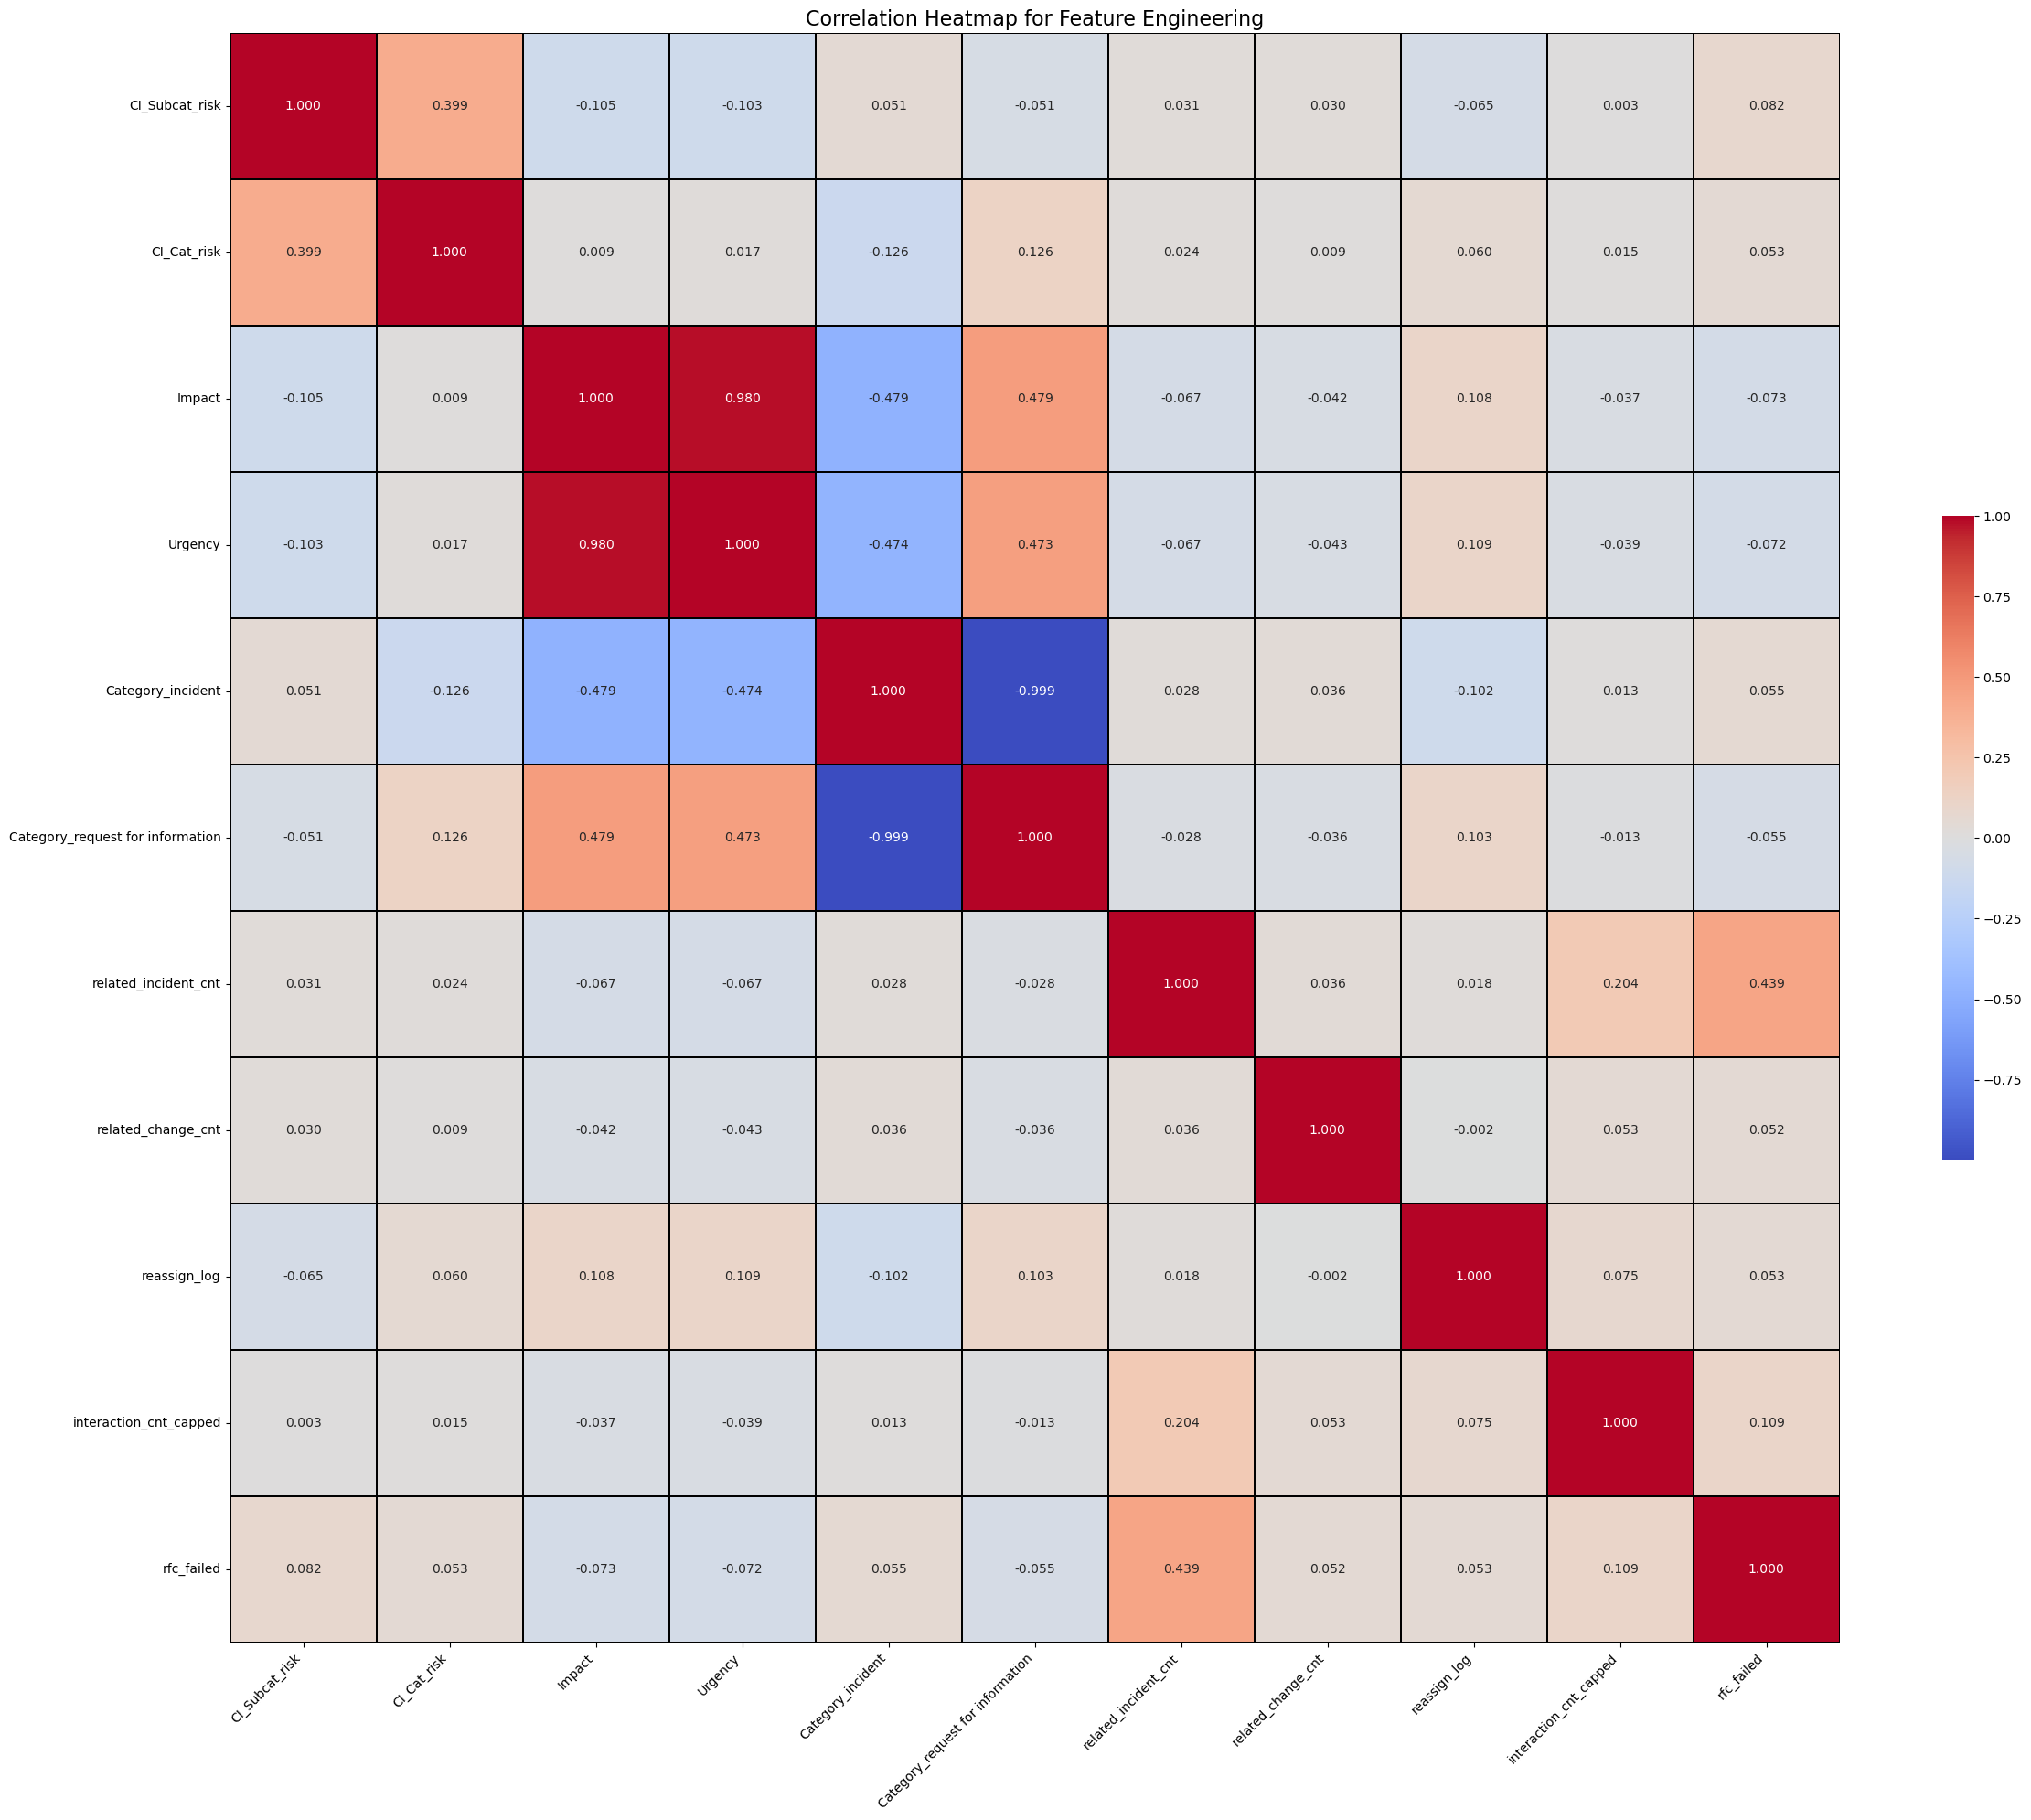

In [249]:

corr=df.corr()
plt.figure(figsize=(25,20))
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    square=True,
    linewidths=0.2,        # Lines between boxes
    linecolor='black',     
    cbar_kws={'shrink': 0.4}  # Smaller color bar
)

plt.title("Correlation Heatmap for Feature Engineering", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [250]:
df.drop(columns=['Urgency','Category_request for information'],inplace=True)

<Axes: >

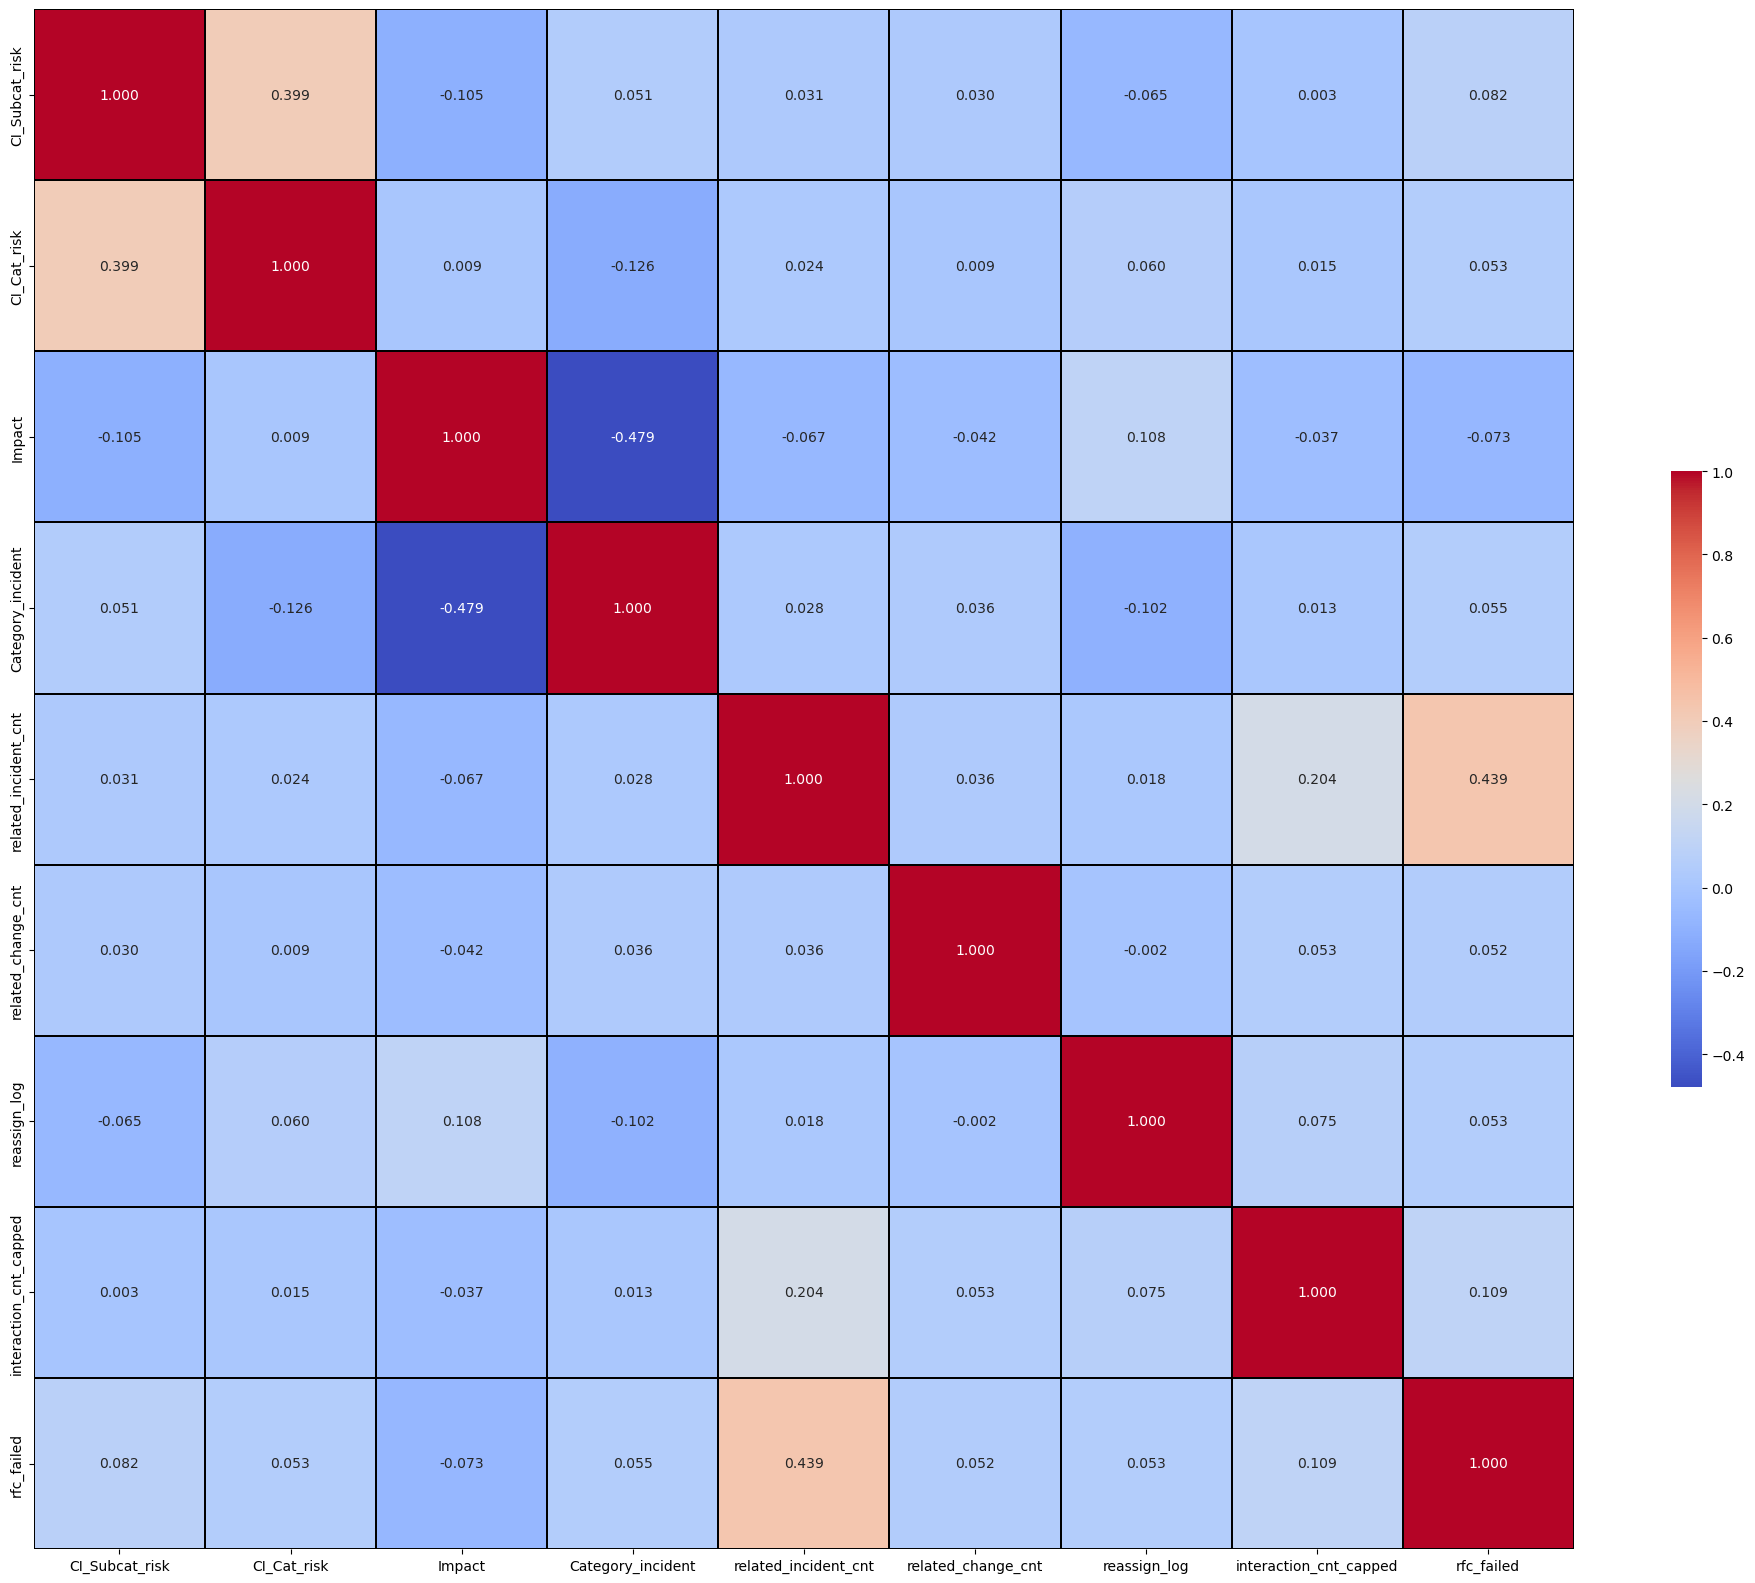

In [251]:
corr=df.corr()
plt.figure(figsize=(25,20))
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    square=True,
    linewidths=0.2,        # Lines between boxes
    linecolor='black',     
    cbar_kws={'shrink': 0.4}  # Smaller color bar
)

In [252]:
df['rfc_failed'].value_counts()

rfc_failed
0    44059
1     1166
Name: count, dtype: int64

In [253]:
df.head()

,CI_Subcat_risk,CI_Cat_risk,Impact,Category_incident,related_incident_cnt,related_change_cnt,reassign_log,interaction_cnt_capped,rfc_failed
0,0.02531,0.015674,4,True,2.0,0.0,3.295837,1.0,1
1,0.02531,0.029952,3,True,1.0,0.0,3.526361,1.0,1
2,0.02531,0.029952,4,True,0.0,0.0,2.639057,1.0,0
3,0.02531,0.029952,4,True,0.0,0.0,1.098612,1.0,0
4,0.02531,0.029952,4,True,0.0,0.0,1.609438,1.0,0


In [254]:
X = df.drop(columns=['rfc_failed'])
y = df['rfc_failed']

In [255]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45225 entries, 0 to 45224
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CI_Subcat_risk          45225 non-null  float64
 1   CI_Cat_risk             45225 non-null  float64
 2   Impact                  45225 non-null  int32  
 3   Category_incident       45225 non-null  bool   
 4   related_incident_cnt    45225 non-null  float64
 5   related_change_cnt      45225 non-null  float64
 6   reassign_log            45225 non-null  float64
 7   interaction_cnt_capped  45225 non-null  float64
dtypes: bool(1), float64(6), int32(1)
memory usage: 2.3 MB


In [256]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [257]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
X_train, y_train=smote.fit_resample(X_train, y_train)

                     Train Accuracy  Test Accuracy  CV Score
Logistic Regression        1.000000       1.000000  1.000000
Decision Tree              1.000000       1.000000  1.000000
Random Forest              1.000000       1.000000  1.000000
Gradient Boosting          1.000000       1.000000  1.000000
SVM                        0.999773       0.999226  0.999536
KNN                        0.999731       0.998784  0.999005
Naive Bayes                0.992654       0.984632  0.984610


<Figure size 1200x600 with 0 Axes>

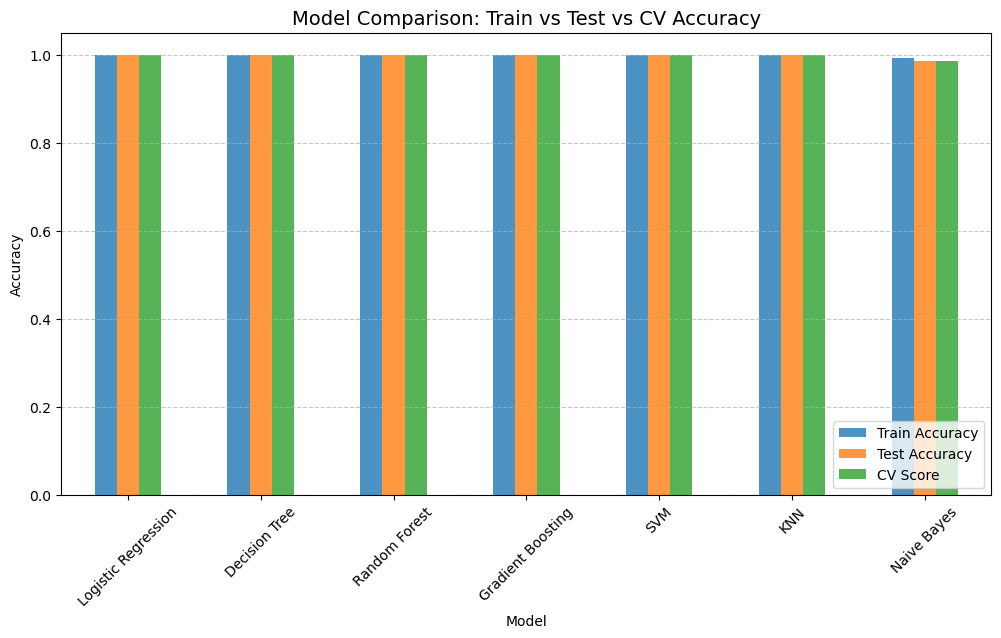


========== DETAILED CLASSIFICATION REPORTS & CONFUSION MATRICES ==========


Model: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8804
           1       1.00      1.00      1.00       241

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[8804    0]
 [   0  241]]


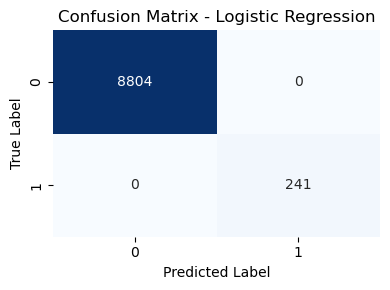

------------------------------------------------------------

Model: Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8804
           1       1.00      1.00      1.00       241

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[8804    0]
 [   0  241]]


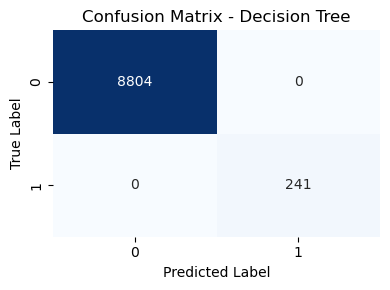

------------------------------------------------------------

Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8804
           1       1.00      1.00      1.00       241

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[8804    0]
 [   0  241]]


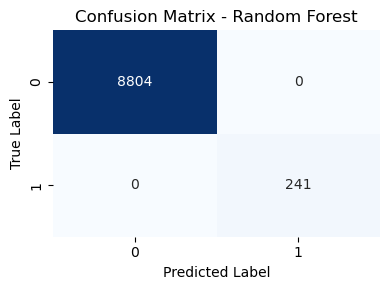

------------------------------------------------------------

Model: Gradient Boosting
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8804
           1       1.00      1.00      1.00       241

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[8804    0]
 [   0  241]]


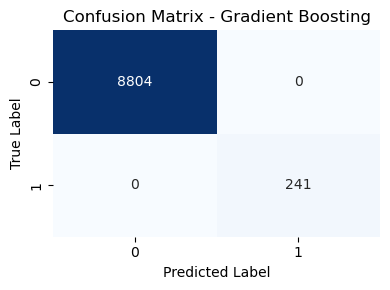

------------------------------------------------------------

Model: SVM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8804
           1       0.98      1.00      0.99       241

    accuracy                           1.00      9045
   macro avg       0.99      1.00      0.99      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[8798    6]
 [   1  240]]


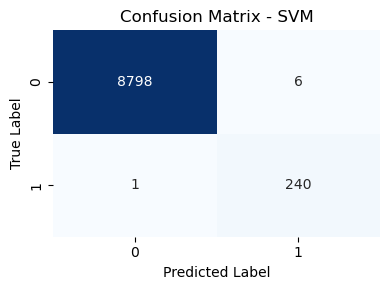

------------------------------------------------------------

Model: KNN
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8804
           1       0.96      0.99      0.98       241

    accuracy                           1.00      9045
   macro avg       0.98      1.00      0.99      9045
weighted avg       1.00      1.00      1.00      9045

Confusion Matrix:
 [[8795    9]
 [   2  239]]


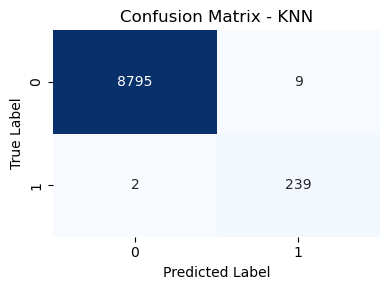

------------------------------------------------------------

Model: Naive Bayes
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      8804
           1       0.63      1.00      0.78       241

    accuracy                           0.98      9045
   macro avg       0.82      0.99      0.88      9045
weighted avg       0.99      0.98      0.99      9045

Confusion Matrix:
 [[8665  139]
 [   0  241]]


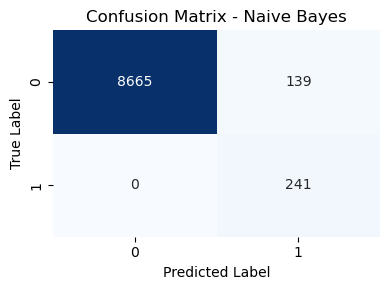

------------------------------------------------------------


In [258]:
# ---------------------------------------
# MULTIPLE CLASSIFICATION MODELS TESTING
# ---------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
#import xgboost as xgb

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris

# Split dataset

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    #"XGBoost": xgb.XGBClassifier(eval_metric='mlogloss')
}

# Evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Scores
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    cv_score = cross_val_score(model, X, y, cv=5).mean()
    
    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "CV Score": cv_score
    }

# Convert to DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)
print(results_df)

# ---------------------------------------
# 📊 Visualization
# ---------------------------------------

plt.figure(figsize=(12,6))
results_df[['Train Accuracy','Test Accuracy','CV Score']].plot(
    kind='bar', figsize=(12,6), rot=45, alpha=0.8
)
plt.title("Model Comparison: Train vs Test vs CV Accuracy", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ---------------------------------------------------------
# CLASSIFICATION REPORTS + CONFUSION MATRIX
# ---------------------------------------------------------
print("\n========== DETAILED CLASSIFICATION REPORTS & CONFUSION MATRICES ==========\n")

for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)
    
    # Plot Confusion Matrix as Heatmap
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    print("-" * 60)


In [259]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [260]:
from sklearn.metrics import roc_auc_score
y_pred_prob = model.predict_proba(X_test)[:, 1]
print("AUC:", roc_auc_score(y_test, y_pred_prob))

AUC: 1.0


In [261]:
def rfc_decision(prob):
    if prob >= 0.75:
        return "BLOCK"
    elif prob >= 0.45:
        return "REVIEW"
    else:
        return "AUTO-APPROVE"

In [262]:
df['rfc_risk_score'] = model.predict_proba(X)[:, 1]
df['decision'] = df['rfc_risk_score'].apply(rfc_decision)


In [263]:
import joblib

joblib.dump(model, "RFC_model.pkl")

['RFC_model.pkl']

In [264]:
X.columns

Index(['CI_Subcat_risk', 'CI_Cat_risk', 'Impact', 'Category_incident',
       'related_incident_cnt', 'related_change_cnt', 'reassign_log',
       'interaction_cnt_capped'],
      dtype='object')

# **Pipeline Creation**

# **📥 → 🧹 → ⚙️ → 🤖 → 📊 → 🚀**

## 1. Ticket Priority Predictions

In [265]:
from sklearn import set_config
set_config(enable_metadata_routing=False)

import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import category_encoders as ce
from sklearn.metrics import classification_report, confusion_matrix


df=pd.read_csv("Basic_Cleand_data.csv", usecols=['CI_Cat', 'CI_Subcat', 'Impact', 'Urgency', 'Category', 'Priority'])

# Target Column.
df['High_Priority'] = df['Priority'].apply(
    lambda x: 1 if x in [2, 1] else 0
)
# Remove uneceassary COLUMNS
df.drop(['Priority'],axis=1, inplace=True)

# ----------------------------
# 2️⃣ Data Setup
# ----------------------------

X=df.drop(columns='High_Priority')
y=df['High_Priority']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

freq_col=['CI_Cat', 'CI_Subcat','Category']
scale_col=['Impact', 'Urgency']

# ----------------------------
# 3️⃣ Column Transformer
# ----------------------------

freq_pipe=Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('freq_encoder', ce.CountEncoder(normalize=True))
])
scale_pipe=Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', MinMaxScaler())
])

preprocessor=ColumnTransformer(transformers=[
    ('freqency', freq_pipe, freq_col),
    ('scaling', scale_pipe, scale_col)
])

# ----------------------------
# 4️⃣ Final ML Pipeline
# ----------------------------

pipeline_TC1=Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100,
                                     max_depth=12,
                                     class_weight='balanced',
                                     random_state=42))
])

pipeline_TC1.fit(X_train, y_train)
print("Pipeline Fit Successful!")


y_pred=pipeline_TC1.predict(X_test)

print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

Pipeline Fit Successful!
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8911
           1       1.00      1.00      1.00       134

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

[[8911    0]
 [   0  134]]


In [266]:
pipeline_TC1

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('freqency',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('freq_encoder',
                                                                   CountEncoder(combine_min_nan_groups=True,
                                                                                normalize=True))]),
                                                  ['CI_Cat', 'CI_Subcat',
                                                   'Category']),
                                                 ('scaling',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['Impact', 'Urgency'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        random_state=42))])

## **2. Auto tag the tickets with right priorities and right departments** 

In [267]:
from sklearn import set_config
set_config(enable_metadata_routing=False)

import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import category_encoders as ce
from sklearn.metrics import classification_report, confusion_matrix


df=pd.read_csv("Basic_Cleand_data.csv", usecols=['CI_Cat', 'CI_Subcat', 'Impact', 'Urgency', 'Category', 'Priority'])


# ----------------------------
# 2️⃣ Data Setup
# ----------------------------

X=df.drop(columns='Priority')
y=df['Priority']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

freq_col=['CI_Cat', 'CI_Subcat','Category']
scale_col=['Impact', 'Urgency']

# ----------------------------
# 3️⃣ Column Transformer
# ----------------------------

freq_pipe=Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('freq_encoder', ce.CountEncoder(normalize=True))
])
scale_pipe=Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', MinMaxScaler())
])

preprocessor=ColumnTransformer(transformers=[
    ('freqency', freq_pipe, freq_col),
    ('scaling', scale_pipe, scale_col)
])

# ----------------------------
# 4️⃣ Final ML Pipeline
# ----------------------------

pipeline_TC2=Pipeline([
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier())
])

pipeline_TC2.fit(X_train, y_train)
print("Pipeline Fit Successful!")


y_pred=pipeline_TC2.predict(X_test)

print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

Pipeline Fit Successful!
              precision    recall  f1-score   support

           2       1.00      1.00      1.00       134
           3       1.00      1.00      1.00      1080
           4       1.00      1.00      1.00      4499
           5       1.00      1.00      1.00      3332

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

[[ 134    0    0    0]
 [   0 1080    0    0]
 [   0    0 4499    0]
 [   0    0    0 3332]]


In [268]:
pipeline_TC2

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('freqency',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('freq_encoder',
                                                                   CountEncoder(combine_min_nan_groups=True,
                                                                                normalize=True))]),
                                                  ['CI_Cat', 'CI_Subcat',
                                                   'Category']),
                                                 ('scaling',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['Impact', 'Urgency'])])),
                ('model', DecisionTreeClassifier())])

## **3. Department Classification Pipeline**

In [269]:
from sklearn import set_config
set_config(enable_metadata_routing=False)

import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import category_encoders as ce
from sklearn.metrics import classification_report, confusion_matrix


df=pd.read_csv("Basic_Cleand_data.csv", usecols=['CI_Cat', 'CI_Subcat', 'Department'])


# ----------------------------
# 2️⃣ Data Setup
# ----------------------------

X=df.drop(columns='Department')
y=df['Department']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

freq_col=['CI_Cat', 'CI_Subcat']


# ----------------------------
# 3️⃣ Column Transformer
# ----------------------------

freq_pipe=Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('freq_encoder', ce.CountEncoder(normalize=True))
])


preprocessor=ColumnTransformer(transformers=[
    ('freqency', freq_pipe, freq_col),
    
])

# ----------------------------
# 4️⃣ Final ML Pipeline
# ----------------------------

pipeline_Dep=Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier())
])

pipeline_Dep.fit(X_train, y_train)
print("Pipeline Fit Successful!")


y_pred=pipeline_Dep.predict(X_test)

print(classification_report(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))

Pipeline Fit Successful!
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7738
           1       1.00      1.00      1.00       548
           2       0.99      0.99      0.99       189
           3       1.00      1.00      1.00       162
           4       1.00      1.00      1.00       103
           5       1.00      1.00      1.00        77
           6       1.00      1.00      1.00        73
           7       1.00      1.00      1.00        39
           8       1.00      1.00      1.00        39
           9       1.00      1.00      1.00        29
          10       1.00      0.95      0.97        19
          11       1.00      1.00      1.00        13
          12       1.00      1.00      1.00        11
          13       1.00      1.00      1.00         5

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045



## **4. Request For Change Failure Prediction Pipeline**

In [270]:
from sklearn import set_config
set_config(enable_metadata_routing=False)

import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import category_encoders as ce
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

df=pd.read_csv("Basic_Cleand_data.csv",  usecols=['CI_Cat','CI_Subcat','Impact', 'Category','No_of_Related_Incidents' , 'has_related_incidents' ,'No_of_Related_Changes','has_related_changes','No_of_Reassignments','No_of_Related_Interactions','Open_Time'])

df['rfc_failed'] = (
    (df['No_of_Related_Incidents'] > 0) |
    (df['has_related_incidents'] == 1)
).astype(int)

ci_fail_rate = df.groupby('CI_Subcat')['rfc_failed'].mean()
ci_fail_rate_dict = ci_fail_rate.to_dict()
df['CI_Subcat_risk'] = df['CI_Subcat'].map(ci_fail_rate_dict)

ci_cat_fail_rate = (
    df.groupby('CI_Cat')['rfc_failed']
      .mean()
)
ci_cat_fail_rate_dict=ci_cat_fail_rate.to_dict()
df['CI_Cat_risk'] = df['CI_Cat'].map(ci_cat_fail_rate_dict)

df['No_of_Related_Interactions'] = df['No_of_Related_Interactions'].clip(upper=50)
df.head()

features = [
    'CI_Subcat_risk',
    'CI_Cat_risk',
    'Impact',
    'No_of_Related_Incidents',
    'No_of_Related_Changes',
    'No_of_Related_Interactions',
    'rfc_failed'
]
df=df[features]

X = df.drop(columns=['rfc_failed'])
y = df['rfc_failed']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols=['CI_Subcat_risk', 'CI_Cat_risk', 'Impact', 'No_of_Related_Incidents',
       'No_of_Related_Changes', 'No_of_Related_Interactions']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_cols)
    ]
)
pipeline_rfc= Pipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier())     
])

pipeline_rfc.fit(X_train, y_train)

y_pred = pipeline_rfc.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8804
           1       1.00      1.00      1.00       241

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045

[[8804    0]
 [   0  241]]


In [271]:
pipeline_rfc

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['CI_Subcat_risk',
                                                   'CI_Cat_risk', 'Impact',
                                                   'No_of_Related_Incidents',
                                                   'No_of_Related_Changes',
                                                   'No_of_Related_Interactions'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', DecisionTreeClassifier())])

In [272]:
print(ci_fail_rate_dict)

{'Application Server': 0.0, 'Automation Software': 0.05454545454545454, 'Banking Device': 0.010285714285714285, 'Citrix': 0.049868766404199474, 'Client Based Application': 0.016771488469601678, 'Controller': 0.0, 'DataCenterEquipment': 0.03292181069958848, 'Database': 0.01818181818181818, 'Database Software': 0.0, 'Desktop': 0.002369668246445498, 'Desktop Application': 0.036667565381504445, 'ESX Cluster': 0.0, 'ESX Server': 0.5, 'Encryption': 0.044444444444444446, 'Exchange': 0.0, 'Firewall': 0.0, 'IPtelephony': 0.0, 'Instance': 0.0, 'Iptelephony': 0.0, 'KVM Switches': 0.0, 'Keyboard': 0.0, 'Laptop': 0.006842105263157895, 'Lines': 0.06666666666666667, 'Linux Server': 0.02040816326530612, 'MQ Queue Manager': 0.0, 'MigratieDummy': 0.034482758620689655, 'Modem': 0.3333333333333333, 'Monitor': 0.0, 'Neoview Server': 0.0, 'Net Device': 0.0, 'Network Component': 0.037037037037037035, 'NonStop Harddisk': 0.0, 'NonStop Server': 0.09090909090909091, 'Number': 0.0, 'Omgeving': 0.1190476190476190

In [273]:
print(ci_cat_fail_rate_dict)

{'Phone': 0.0, 'application': 0.029952476238119058, 'applicationcomponent': 0.0, 'computer': 0.012415349887133182, 'database': 0.017857142857142856, 'displaydevice': 0.0, 'hardware': 0.03201970443349754, 'networkcomponents': 0.12121212121212122, 'officeelectronics': 0.007194244604316547, 'software': 0.023809523809523808, 'storage': 0.010719754977029096, 'subapplication': 0.015673575129533678}


In [274]:
import joblib
joblib.dump(pipeline_TC1, "pipline_TC1.pkl")
joblib.dump(pipeline_TC2, "pipline_TC2.pkl")
joblib.dump(pipeline_Dep, "pipline_Dep.pkl")
joblib.dump(pipeline_rfc, "pipline_rfc.pkl")


['pipline_rfc.pkl']

## **5. Time series forecasitng Pipeline**

In [275]:
import os
import pandas as pd

In [276]:
def train_and_save_arima(
    df,
    filters,
    model_path,
    order=(1,1,1),
    stable_start="2013-01-31"
):
    # Apply filters
    data = df.copy()
    for col, val in filters.items():
        data = data[data[col] == val]

    if data.empty:
        raise ValueError(f"No data after applying filters: {filters}")

    # Create monthly time series
    ts = (
        data
        .set_index("Open_Time")          # ✅ FIXED
        .sort_index()                    # ✅ IMPORTANT
        .resample("M")
        .size()
        .asfreq("M")
        .fillna(0)
    )

    # Stable regime
    #ts = ts[ts.index >= stable_start]

    if len(ts) < 12:
        raise ValueError(f"Not enough data for model {model_path}")

    # Log transform
    ts_log = np.log1p(ts)

    # Train ARIMA
    model = ARIMA(ts_log, order=order)
    model_fit = model.fit()

    # Save FITTED model
    dump(model_fit, model_path)

    print(f"✅ Saved model: {model_path}")

In [277]:
MODEL_CONFIGS = {
    "model_overall_forecast.pkl": {
        "filters": {"Category": "incident"},
        "order": (0, 1, 3)
    },

    "model_CI_1.pkl": {
        "filters": {
            "Category": "incident",
            "CI_Cat": "application"
        },
        "order": (0, 1, 0)
    },

    "model_CI_2.pkl": {
        "filters": {
            "Category": "incident",
            "CI_Cat": "subapplication"
        },
        "order": (0, 1, 3)
    },

    "model_CI_3.pkl": {
        "filters": {
            "Category": "incident",
            "CI_Subcat": "Server Based Application"
        },
        "order": (3, 1, 1)
    },

    "model_CI_4.pkl": {
        "filters": {
            "Category": "incident",
            "CI_Subcat": "Web Based Application"
        },
        "order": (2, 1, 3)
    }
}


In [278]:
df = pd.read_csv("Basic_Cleand_data.csv")
df["Open_Time"] = pd.to_datetime(df["Open_Time"])

In [279]:
from joblib import dump

BASE_PATH = (
    "C:/Users/Pranav Gupta/Python/Machine Learning/"
    "Internship Projects/Project Monitoring System"
)

os.makedirs(BASE_PATH, exist_ok=True)

for model_name, config in MODEL_CONFIGS.items():
    model_file = os.path.join(BASE_PATH, model_name)

    train_and_save_arima(
        df=df,
        filters=config["filters"],
        order=config["order"],
        model_path=model_file
    )


✅ Saved model: C:/Users/Pranav Gupta/Python/Machine Learning/Internship Projects/Project Monitoring System\model_overall_forecast.pkl
✅ Saved model: C:/Users/Pranav Gupta/Python/Machine Learning/Internship Projects/Project Monitoring System\model_CI_1.pkl
✅ Saved model: C:/Users/Pranav Gupta/Python/Machine Learning/Internship Projects/Project Monitoring System\model_CI_2.pkl
✅ Saved model: C:/Users/Pranav Gupta/Python/Machine Learning/Internship Projects/Project Monitoring System\model_CI_3.pkl
✅ Saved model: C:/Users/Pranav Gupta/Python/Machine Learning/Internship Projects/Project Monitoring System\model_CI_4.pkl


# **Fastapi** 

#### file exist:

**main.py**: This contains endpoint of the api and pydantic class for data valiation.

**train_and_save_model.py** : This contain training of time series and forcast values accordingly.

**itsm_api.log** : This file contain log information regarding every request and its output and reason of faliure

## train_and_save_model.py

## main.py

## **frontend.py**

This file having frontend related code 

## **Requirement.txt**  file

All the dependencies requires to run this api and models.